In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from functools import reduce

C:\Users\aleci\anaconda3\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.1
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
import os
import glob

In [3]:
from datetime import datetime

## Step 1 - Read in the files

In [128]:
# path name in Windows
rawpath=r'C:\Users\aleci\Documents\NumInformatics\HSCRC_touch\data\claim attachment\\'
datapath=r'C:\Users\aleci\Documents\NumInformatics\HSCRC_touch\data\\'
docupath=r'C:\Users\aleci\Documents\NumInformatics\HSCRC_touch\documents\\'
dtrules=r'C:\Users\aleci\Documents\NumInformatics\HSCRC_touch\DT rules\\'

In [5]:
# path name in mac
#path=r'/Users/zhixiaolin/Documents/Numinformatics/HSCRC_touch/data/claim attachment//'
#docupath=r'/Users/zhixiaolin/Documents/Numinformatics/HSCRC_touchdocuments//'

In [6]:
csv_files = glob.glob(os.path.join(rawpath, "*.csv"))

df=[]
for f in csv_files:
    
    df.append(pd.read_csv(f))
    dfs=pd.concat(df, ignore_index=True)

C:\Users\aleci\anaconda3\lib\site-packages\IPython\core\interactiveshell.py:3444: DtypeWarning: Columns (9,18,20,21,40) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)
C:\Users\aleci\anaconda3\lib\site-packages\IPython\core\interactiveshell.py:3444: DtypeWarning: Columns (9,18,20,21) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)
C:\Users\aleci\anaconda3\lib\site-packages\IPython\core\interactiveshell.py:3444: DtypeWarning: Columns (9,18,20,21,24,40) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)
C:\Users\aleci\anaconda3\lib\site-packages\IPython\core\interactiveshell.py:3444: DtypeWarning: Columns (9,18,20,21,24) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)
C:\Users\aleci\anaco

In [7]:
dfs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17462662 entries, 0 to 17462661
Data columns (total 60 columns):
 #   Column                Dtype  
---  ------                -----  
 0   sub_clm_aud_nbr       object 
 1   anchor_clm_nbr        object 
 2   prdct_cd              object 
 3   rvnu_cd               object 
 4   proc_cd               object 
 5   diag_1_cd             object 
 6   diag_2_cd             object 
 7   diag_3_cd             object 
 8   diag_4_cd             object 
 9   drg_cd                object 
 10  clm_chrg_amt          float64
 11  clm_ded_amt           float64
 12  clm_coin_amt          float64
 13  clm_copay_amt         float64
 14  clm_alw_amt           float64
 15  clm_not_cov_amt       float64
 16  clm_pd_amt            float64
 17  par_npar              int64  
 18  prov_tin_prfx_cd      object 
 19  prov_tin_sufx_cd      object 
 20  prov_tin              object 
 21  bil_prov_npi_nbr      object 
 22  pos_cd                int64  
 23  pos_d

In [8]:
dfs.drop(['anchor_clm_nbr',
'prov_tin',
'edit_min_cdc_ts',
'edit_err_wrn_nbr',
'edit_pgm_id',
'edit_err_wrn_cd',
'edit_wrn_seq_nbr',
'edit_flag',
'edit_lst_updt_dttm',
'edit_partn_id',
'fnl_fp_closr_cd',
'fnl_adj_closr_cd',
'fnl_fp_rsn_cd',
'fnl_adj_rsn_cd',
'case_status',
'fa_id',
'deny_type',
'fwae_dipsosition',
'detection_method',
'med_rec_received_dt',
'adjd_dt',
'case_create_dt',
'case_closed_dt',
'recon_date',
'date_of_service',
'claim_received_date',
'claim_stopped_date',
'pcr_id'
], axis=1, inplace=True)

In [9]:
# make a sample to save computing time
dfs.insert(0, 'seq', range(1, 1+len(dfs)))
dfs['target']=np.where(dfs['claim_number'].str.strip().isnull()==True, 0, 1)

## split into modeling and validation sample
## because the data are big, we will select only 20% sample



#dfs=dfs[dfs['seq']%10 < 3]

In [10]:
dfs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17462662 entries, 0 to 17462661
Data columns (total 34 columns):
 #   Column                Dtype  
---  ------                -----  
 0   seq                   int64  
 1   sub_clm_aud_nbr       object 
 2   prdct_cd              object 
 3   rvnu_cd               object 
 4   proc_cd               object 
 5   diag_1_cd             object 
 6   diag_2_cd             object 
 7   diag_3_cd             object 
 8   diag_4_cd             object 
 9   drg_cd                object 
 10  clm_chrg_amt          float64
 11  clm_ded_amt           float64
 12  clm_coin_amt          float64
 13  clm_copay_amt         float64
 14  clm_alw_amt           float64
 15  clm_not_cov_amt       float64
 16  clm_pd_amt            float64
 17  par_npar              int64  
 18  prov_tin_prfx_cd      object 
 19  prov_tin_sufx_cd      object 
 20  bil_prov_npi_nbr      object 
 21  pos_cd                int64  
 22  pos_desc              object 
 23  mbr_a

In [11]:
#dfs.to_csv(datapath+'dfs.csv')

## Step 2 - Transform some features

In [12]:
#dfs=pd.read_csv(datapath+'dfs.csv')

#### Step 2-1: encode diagnosis codes

In [13]:
neoplasms_D=['D00','D01','D02','D03','D04','D05','D06','D07','D08','D09','D10','D11','D12','D13','D14','D15','D16','D17',
             'D18','D19','D20','D21','D22','D23','D24','D25','D26','D27','D28','D29','D30','D31','D32','D33','D34','D35',
             'D36','D37','D38','D39','D40','D41','D42','D43','D44','D45','D46','D47','D48']

blood_immune=['D50','D51','D52','D53','D54','D55','D56','D57','D58','D59','D60','D61','D62','D63',
              'D64','D65','D66','D67','D68','D69','D70','D71','D72','D73','D74','D75','D76','D77',
              'D78','D79','D80','D81','D82','D83','D84','D85','D86','D87','D88','D89']

eye_adnexa=['H00','H01','H02','H03','H04','H05','H06','H07','H08','H09','H10','H11','H12','H13','H14','H15','H16','H17',
            'H18','H19','H20','H21','H22','H23','H24','H25','H26','H27','H28','H29','H30','H31','H32','H33','H34','H35',
            'H36','H37','H38','H39','H40','H41','H42','H43','H44','H45','H46','H47','H48','H49','H50','H51','H52','H53',
            'H54','H55','H56','H57','H58','H59']

ear_mastoid=['H60','H61','H62','H63','H64','H65','H66','H67','H68','H69','H70','H71','H72','H73','H74','H75','H76','H77',
             'H78','H79','H80','H81','H82','H83','H84','H85','H86','H87','H88','H89','H90','H91','H92','H93','H94','H95']

In [26]:
# encode diagnosis code 1
dfs_stacked=dfs['diag_1_cd'].str.split("|", expand=True)
num_columns=len(dfs_stacked.columns)
num_columns_less_1=num_columns-1
dfs_stacked=dfs_stacked.join(dfs[['sub_clm_aud_nbr']])
dfs_stacked2=dfs_stacked.iloc[:, [0, num_columns]]
dfs_stacked2.columns=(['diag_1_cd', 'sub_clm_aud_nbr'])
dfs_stacked2.head()

dfs_stacked2=dfs_stacked.iloc[:, [0, num_columns]]
dfs_stacked2.columns=(['diag_1_cd', 'sub_clm_aud_nbr'])

for i in range(1, num_columns_less_1):
    dfs_to_stack=dfs_stacked.iloc[:, [i, num_columns]]
    dfs_to_stack.columns=(['diag_1_cd', 'sub_clm_aud_nbr'])
    dfs_to_stack.dropna(axis=0, how='any', inplace=True)
    dfs_stacked2=pd.concat([dfs_stacked2, dfs_to_stack])
    dfs_stacked2.drop_duplicates(subset=['sub_clm_aud_nbr', 'diag_1_cd'], keep='first', inplace=True)
    
diag_1_cd=dfs_stacked2.copy()
diag_1_cd['diag_1_infectious_parasitic']=np.where(diag_1_cd['diag_1_cd'].str.strip().str.slice(0, 1).isin(['A', 'B']), 1, 0)
diag_1_cd['diag_1_neoplasms']=np.where((diag_1_cd['diag_1_cd'].str.strip().str.slice(0, 1)=='C') |
                                 (diag_1_cd['diag_1_cd'].str.strip().str.slice(0, 3).isin(neoplasms_D)), 1, 0)
diag_1_cd['diag_1_blood_immune']=np.where((diag_1_cd['diag_1_cd'].str.strip().str.slice(0, 3).isin(blood_immune)), 1, 0)
diag_1_cd['diag_1_endotrine_nutri_metab']=np.where((diag_1_cd['diag_1_cd'].str.strip().str.slice(0, 1)=='E'), 1, 0)
diag_1_cd['diag_1_mental_behavioral']=np.where((diag_1_cd['diag_1_cd'].str.strip().str.slice(0, 1)=='F'), 1, 0)
diag_1_cd['diag_1_nervous_system']=np.where((diag_1_cd['diag_1_cd'].str.strip().str.slice(0, 1)=='G'), 1, 0)
diag_1_cd['diag_1_eye_adnexa']=np.where((diag_1_cd['diag_1_cd'].str.strip().str.slice(0, 3).isin(eye_adnexa)), 1, 0)
diag_1_cd['diag_1_ear_mastoid']=np.where((diag_1_cd['diag_1_cd'].str.strip().str.slice(0, 3).isin(ear_mastoid)), 1, 0)
diag_1_cd['diag_1_circulatory']=np.where((diag_1_cd['diag_1_cd'].str.strip().str.slice(0, 1)=='I'), 1, 0)
diag_1_cd['diag_1_respiratory']=np.where((diag_1_cd['diag_1_cd'].str.strip().str.slice(0, 1)=='J'), 1, 0)
diag_1_cd['diag_1_digestive']=np.where((diag_1_cd['diag_1_cd'].str.strip().str.slice(0, 1)=='K'), 1, 0)
diag_1_cd['diag_1_skin_subcutaneous']=np.where((diag_1_cd['diag_1_cd'].str.strip().str.slice(0, 1)=='L'), 1, 0)
diag_1_cd['diag_1_musculoskeletal']=np.where((diag_1_cd['diag_1_cd'].str.strip().str.slice(0, 1)=='M'), 1, 0)
diag_1_cd['diag_1_genitourinary']=np.where((diag_1_cd['diag_1_cd'].str.strip().str.slice(0, 1)=='N'), 1, 0)
diag_1_cd['diag_1_pregnancy_childbirth']=np.where((diag_1_cd['diag_1_cd'].str.strip().str.slice(0, 1)=='O'), 1, 0)
diag_1_cd['diag_1_perinatal']=np.where((diag_1_cd['diag_1_cd'].str.strip().str.slice(0, 1)=='P'), 1, 0)
diag_1_cd['diag_1_congenital_chromosomal']=np.where((diag_1_cd['diag_1_cd'].str.strip().str.slice(0, 1)=='Q'), 1, 0)
diag_1_cd['diag_1_abnormal_finding']=np.where((diag_1_cd['diag_1_cd'].str.strip().str.slice(0, 1)=='R'), 1, 0)
diag_1_cd['diag_1_injury_poisoning']=np.where((diag_1_cd['diag_1_cd'].str.strip().str.slice(0, 1).isin(['S', 'T'])), 1, 0)
diag_1_cd['diag_1_external_morbidity']=np.where((diag_1_cd['diag_1_cd'].str.strip().str.slice(0, 1).isin(['V', 'W', 'X', 'Y'])), 1, 0)
diag_1_cd['diag_1_health_factor']=np.where((diag_1_cd['diag_1_cd'].str.strip().str.slice(0, 1)=='Z'), 1, 0)

## Some records could have multiple diagnosis codes belongin to the same group.
## These multiple records need to be combined into 1 record
diag_1_columns=diag_1_cd.columns.tolist()
print(diag_1_columns)
num_diag_1_columns=len(diag_1_columns)
print(num_diag_1_columns)

diag_1_cd=diag_1_cd.groupby('sub_clm_aud_nbr')[diag_1_columns[2:num_diag_1_columns]].sum().reset_index()

#for item in diag_1_columns[2: num_diag_1_columns]:
#    diag_1_cd[item]=np.where(diag_1_cd[item] > 0, 1, 0)

['diag_1_cd', 'sub_clm_aud_nbr', 'diag_1_infectious_parasitic', 'diag_1_neoplasms', 'diag_1_blood_immune', 'diag_1_endotrine_nutri_metab', 'diag_1_mental_behavioral', 'diag_1_nervous_system', 'diag_1_eye_adnexa', 'diag_1_ear_mastoid', 'diag_1_circulatory', 'diag_1_respiratory', 'diag_1_digestive', 'diag_1_skin_subcutaneous', 'diag_1_musculoskeletal', 'diag_1_genitourinary', 'diag_1_pregnancy_childbirth', 'diag_1_perinatal', 'diag_1_congenital_chromosomal', 'diag_1_abnormal_finding', 'diag_1_injury_poisoning', 'diag_1_external_morbidity', 'diag_1_health_factor']
23


In [27]:
diag_1_cd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17462662 entries, 0 to 17462661
Data columns (total 22 columns):
 #   Column                         Dtype 
---  ------                         ----- 
 0   sub_clm_aud_nbr                object
 1   diag_1_infectious_parasitic    int32 
 2   diag_1_neoplasms               int32 
 3   diag_1_blood_immune            int32 
 4   diag_1_endotrine_nutri_metab   int32 
 5   diag_1_mental_behavioral       int32 
 6   diag_1_nervous_system          int32 
 7   diag_1_eye_adnexa              int32 
 8   diag_1_ear_mastoid             int32 
 9   diag_1_circulatory             int32 
 10  diag_1_respiratory             int32 
 11  diag_1_digestive               int32 
 12  diag_1_skin_subcutaneous       int32 
 13  diag_1_musculoskeletal         int32 
 14  diag_1_genitourinary           int32 
 15  diag_1_pregnancy_childbirth    int32 
 16  diag_1_perinatal               int32 
 17  diag_1_congenital_chromosomal  int32 
 18  diag_1_abnormal_find

In [15]:

diag_1_cd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17462662 entries, 0 to 17462661
Data columns (total 22 columns):
 #   Column                         Dtype 
---  ------                         ----- 
 0   sub_clm_aud_nbr                object
 1   diag_1_infectious_parasitic    int32 
 2   diag_1_neoplasms               int32 
 3   diag_1_blood_immune            int32 
 4   diag_1_endotrine_nutri_metab   int32 
 5   diag_1_mental_behavioral       int32 
 6   diag_1_nervous_system          int32 
 7   diag_1_eye_adnexa              int32 
 8   diag_1_ear_mastoid             int32 
 9   diag_1_circulatory             int32 
 10  diag_1_respiratory             int32 
 11  diag_1_digestive               int32 
 12  diag_1_skin_subcutaneous       int32 
 13  diag_1_musculoskeletal         int32 
 14  diag_1_genitourinary           int32 
 15  diag_1_pregnancy_childbirth    int32 
 16  diag_1_perinatal               int32 
 17  diag_1_congenital_chromosomal  int32 
 18  diag_1_abnormal_find

In [16]:
# encode diagnosis code 1
dfs_stacked=dfs['diag_1_cd'].str.split("|", expand=True)
num_columns=len(dfs_stacked.columns)
num_columns_less_1=num_columns-1
dfs_stacked=dfs_stacked.join(dfs[['sub_clm_aud_nbr']])
dfs_stacked2=dfs_stacked.iloc[:, [0, num_columns]]
dfs_stacked2.columns=(['diag_1_cd', 'sub_clm_aud_nbr'])
dfs_stacked2.head()

dfs_stacked2=dfs_stacked.iloc[:, [0, num_columns]]
dfs_stacked2.columns=(['diag_1_cd', 'sub_clm_aud_nbr'])

for i in range(1, num_columns_less_1):
    dfs_to_stack=dfs_stacked.iloc[:, [i, num_columns]]
    dfs_to_stack.columns=(['diag_1_cd', 'sub_clm_aud_nbr'])
    dfs_to_stack.dropna(axis=0, how='any', inplace=True)
    dfs_stacked2=pd.concat([dfs_stacked2, dfs_to_stack])
    dfs_stacked2.drop_duplicates(subset=['sub_clm_aud_nbr', 'diag_1_cd'], keep='first', inplace=True)
    
diag_1_cd=dfs_stacked2.copy()
diag_1_cd['diag_1_infectious_parasitic']=np.where(diag_1_cd['diag_1_cd'].str.strip().str.slice(0, 1).isin(['A', 'B']), 1, 0)
diag_1_cd['diag_1_neoplasms']=np.where((diag_1_cd['diag_1_cd'].str.strip().str.slice(0, 1)=='C') |
                                 (diag_1_cd['diag_1_cd'].str.strip().str.slice(0, 3).isin(neoplasms_D)), 1, 0)
diag_1_cd['diag_1_blood_immune']=np.where((diag_1_cd['diag_1_cd'].str.strip().str.slice(0, 3).isin(blood_immune)), 1, 0)
diag_1_cd['diag_1_endotrine_nutri_metab']=np.where((diag_1_cd['diag_1_cd'].str.strip().str.slice(0, 1)=='E'), 1, 0)
diag_1_cd['diag_1_mental_behavioral']=np.where((diag_1_cd['diag_1_cd'].str.strip().str.slice(0, 1)=='F'), 1, 0)
diag_1_cd['diag_1_nervous_system']=np.where((diag_1_cd['diag_1_cd'].str.strip().str.slice(0, 1)=='G'), 1, 0)
diag_1_cd['diag_1_eye_adnexa']=np.where((diag_1_cd['diag_1_cd'].str.strip().str.slice(0, 3).isin(eye_adnexa)), 1, 0)
diag_1_cd['diag_1_ear_mastoid']=np.where((diag_1_cd['diag_1_cd'].str.strip().str.slice(0, 3).isin(ear_mastoid)), 1, 0)
diag_1_cd['diag_1_circulatory']=np.where((diag_1_cd['diag_1_cd'].str.strip().str.slice(0, 1)=='I'), 1, 0)
diag_1_cd['diag_1_respiratory']=np.where((diag_1_cd['diag_1_cd'].str.strip().str.slice(0, 1)=='J'), 1, 0)
diag_1_cd['diag_1_digestive']=np.where((diag_1_cd['diag_1_cd'].str.strip().str.slice(0, 1)=='K'), 1, 0)
diag_1_cd['diag_1_skin_subcutaneous']=np.where((diag_1_cd['diag_1_cd'].str.strip().str.slice(0, 1)=='L'), 1, 0)
diag_1_cd['diag_1_musculoskeletal']=np.where((diag_1_cd['diag_1_cd'].str.strip().str.slice(0, 1)=='M'), 1, 0)
diag_1_cd['diag_1_genitourinary']=np.where((diag_1_cd['diag_1_cd'].str.strip().str.slice(0, 1)=='N'), 1, 0)
diag_1_cd['diag_1_pregnancy_childbirth']=np.where((diag_1_cd['diag_1_cd'].str.strip().str.slice(0, 1)=='O'), 1, 0)
diag_1_cd['diag_1_perinatal']=np.where((diag_1_cd['diag_1_cd'].str.strip().str.slice(0, 1)=='P'), 1, 0)
diag_1_cd['diag_1_congenital_chromosomal']=np.where((diag_1_cd['diag_1_cd'].str.strip().str.slice(0, 1)=='Q'), 1, 0)
diag_1_cd['diag_1_abnormal_finding']=np.where((diag_1_cd['diag_1_cd'].str.strip().str.slice(0, 1)=='R'), 1, 0)
diag_1_cd['diag_1_injury_poisoning']=np.where((diag_1_cd['diag_1_cd'].str.strip().str.slice(0, 1).isin(['S', 'T'])), 1, 0)
diag_1_cd['diag_1_external_morbidity']=np.where((diag_1_cd['diag_1_cd'].str.strip().str.slice(0, 1).isin(['V', 'W', 'X', 'Y'])), 1, 0)
diag_1_cd['diag_1_health_factor']=np.where((diag_1_cd['diag_1_cd'].str.strip().str.slice(0, 1)=='Z'), 1, 0)

## Some records could have multiple diagnosis codes belongin to the same group.
## These multiple records need to be combined into 1 record
diag_1_columns=diag_1_cd.columns.tolist()
print(diag_1_columns)
num_diag_1_columns=len(diag_1_columns)
print(num_diag_1_columns)

diag_1_cd=diag_1_cd.groupby('sub_clm_aud_nbr')[diag_1_columns[2:num_diag_1_columns]].sum().reset_index()

#for item in diag_1_columns[2: num_diag_1_columns]:
#    diag_1_cd[item]=np.where(diag_1_cd[item] > 0, 1, 0)

diag_1_cd.head()

,sub_clm_aud_nbr,diag_1_infectious_parasitic,diag_1_neoplasms,diag_1_blood_immune,diag_1_endotrine_nutri_metab,diag_1_mental_behavioral,diag_1_nervous_system,diag_1_eye_adnexa,diag_1_ear_mastoid,diag_1_circulatory,...,diag_1_skin_subcutaneous,diag_1_musculoskeletal,diag_1_genitourinary,diag_1_pregnancy_childbirth,diag_1_perinatal,diag_1_congenital_chromosomal,diag_1_abnormal_finding,diag_1_injury_poisoning,diag_1_external_morbidity,diag_1_health_factor
0,3276874597,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,3365198877,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,3365422424,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,3372883912,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
4,3377664902,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0


In [17]:
# encode diagnosis code 2
dfs_stacked=dfs['diag_2_cd'].str.split("|", expand=True)
num_columns=len(dfs_stacked.columns)
num_columns_less_1=num_columns-1
dfs_stacked=dfs_stacked.join(dfs[['sub_clm_aud_nbr']])
dfs_stacked2=dfs_stacked.iloc[:, [0, num_columns]]
dfs_stacked2.columns=(['diag_2_cd', 'sub_clm_aud_nbr'])
dfs_stacked2.head()

dfs_stacked2=dfs_stacked.iloc[:, [0, num_columns]]
dfs_stacked2.columns=(['diag_2_cd', 'sub_clm_aud_nbr'])

for i in range(1, num_columns_less_1):
    dfs_to_stack=dfs_stacked.iloc[:, [i, num_columns]]
    dfs_to_stack.columns=(['diag_2_cd', 'sub_clm_aud_nbr'])
    dfs_to_stack.dropna(axis=0, how='any', inplace=True)
    dfs_stacked2=pd.concat([dfs_stacked2, dfs_to_stack])
    dfs_stacked2.drop_duplicates(subset=['sub_clm_aud_nbr', 'diag_2_cd'], keep='first', inplace=True)
    
diag_2_cd=dfs_stacked2.copy()
diag_2_cd['diag_2_infectious_parasitic']=np.where(diag_2_cd['diag_2_cd'].str.strip().str.slice(0, 1).isin(['A', 'B']), 1, 0)
diag_2_cd['diag_2_neoplasms']=np.where((diag_2_cd['diag_2_cd'].str.strip().str.slice(0, 1)=='C') |
                                 (diag_2_cd['diag_2_cd'].str.strip().str.slice(0, 3).isin(neoplasms_D)), 1, 0)
diag_2_cd['diag_2_blood_immune']=np.where((diag_2_cd['diag_2_cd'].str.strip().str.slice(0, 3).isin(blood_immune)), 1, 0)
diag_2_cd['diag_2_endotrine_nutri_metab']=np.where((diag_2_cd['diag_2_cd'].str.strip().str.slice(0, 1)=='E'), 1, 0)
diag_2_cd['diag_2_mental_behavioral']=np.where((diag_2_cd['diag_2_cd'].str.strip().str.slice(0, 1)=='F'), 1, 0)
diag_2_cd['diag_2_nervous_system']=np.where((diag_2_cd['diag_2_cd'].str.strip().str.slice(0, 1)=='G'), 1, 0)
diag_2_cd['diag_2_eye_adnexa']=np.where((diag_2_cd['diag_2_cd'].str.strip().str.slice(0, 3).isin(eye_adnexa)), 1, 0)
diag_2_cd['diag_2_ear_mastoid']=np.where((diag_2_cd['diag_2_cd'].str.strip().str.slice(0, 3).isin(ear_mastoid)), 1, 0)
diag_2_cd['diag_2_circulatory']=np.where((diag_2_cd['diag_2_cd'].str.strip().str.slice(0, 1)=='I'), 1, 0)
diag_2_cd['diag_2_respiratory']=np.where((diag_2_cd['diag_2_cd'].str.strip().str.slice(0, 1)=='J'), 1, 0)
diag_2_cd['diag_2_digestive']=np.where((diag_2_cd['diag_2_cd'].str.strip().str.slice(0, 1)=='K'), 1, 0)
diag_2_cd['diag_2_skin_subcutaneous']=np.where((diag_2_cd['diag_2_cd'].str.strip().str.slice(0, 1)=='L'), 1, 0)
diag_2_cd['diag_2_musculoskeletal']=np.where((diag_2_cd['diag_2_cd'].str.strip().str.slice(0, 1)=='M'), 1, 0)
diag_2_cd['diag_2_genitourinary']=np.where((diag_2_cd['diag_2_cd'].str.strip().str.slice(0, 1)=='N'), 1, 0)
diag_2_cd['diag_2_pregnancy_childbirth']=np.where((diag_2_cd['diag_2_cd'].str.strip().str.slice(0, 1)=='O'), 1, 0)
diag_2_cd['diag_2_perinatal']=np.where((diag_2_cd['diag_2_cd'].str.strip().str.slice(0, 1)=='P'), 1, 0)
diag_2_cd['diag_2_congenital_chromosomal']=np.where((diag_2_cd['diag_2_cd'].str.strip().str.slice(0, 1)=='Q'), 1, 0)
diag_2_cd['diag_2_abnormal_finding']=np.where((diag_2_cd['diag_2_cd'].str.strip().str.slice(0, 1)=='R'), 1, 0)
diag_2_cd['diag_2_injury_poisoning']=np.where((diag_2_cd['diag_2_cd'].str.strip().str.slice(0, 1).isin(['S', 'T'])), 1, 0)
diag_2_cd['diag_2_external_morbidity']=np.where((diag_2_cd['diag_2_cd'].str.strip().str.slice(0, 1).isin(['V', 'W', 'X', 'Y'])), 1, 0)
diag_2_cd['diag_2_health_factor']=np.where((diag_2_cd['diag_2_cd'].str.strip().str.slice(0, 1)=='Z'), 1, 0)

## some records could have multiple diagnosis codes belongin to one group.
## These multiple records need to be comined into 1 record
diag_2_columns=diag_2_cd.columns.tolist()
print(diag_2_columns)
num_diag_2_columns=len(diag_2_columns)
print(num_diag_2_columns)

diag_2_cd=diag_2_cd.groupby('sub_clm_aud_nbr')[diag_2_columns[2:num_diag_2_columns]].sum().reset_index()

#for item in diag_2_columns[2: num_diag_2_columns]:
#    diag_2_cd[item]=np.where(diag_2_cd[item] > 0, 1, 0)
    
diag_2_cd.info()

C:\Users\aleci\anaconda3\lib\site-packages\pandas\util\_decorators.py:311: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return func(*args, **kwargs)


['diag_2_cd', 'sub_clm_aud_nbr', 'diag_2_infectious_parasitic', 'diag_2_neoplasms', 'diag_2_blood_immune', 'diag_2_endotrine_nutri_metab', 'diag_2_mental_behavioral', 'diag_2_nervous_system', 'diag_2_eye_adnexa', 'diag_2_ear_mastoid', 'diag_2_circulatory', 'diag_2_respiratory', 'diag_2_digestive', 'diag_2_skin_subcutaneous', 'diag_2_musculoskeletal', 'diag_2_genitourinary', 'diag_2_pregnancy_childbirth', 'diag_2_perinatal', 'diag_2_congenital_chromosomal', 'diag_2_abnormal_finding', 'diag_2_injury_poisoning', 'diag_2_external_morbidity', 'diag_2_health_factor']
23
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17462662 entries, 0 to 17462661
Data columns (total 22 columns):
 #   Column                         Dtype 
---  ------                         ----- 
 0   sub_clm_aud_nbr                object
 1   diag_2_infectious_parasitic    int32 
 2   diag_2_neoplasms               int32 
 3   diag_2_blood_immune            int32 
 4   diag_2_endotrine_nutri_metab   int32 
 5   diag_2_m

In [18]:
diag_2_cd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17462662 entries, 0 to 17462661
Data columns (total 22 columns):
 #   Column                         Dtype 
---  ------                         ----- 
 0   sub_clm_aud_nbr                object
 1   diag_2_infectious_parasitic    int32 
 2   diag_2_neoplasms               int32 
 3   diag_2_blood_immune            int32 
 4   diag_2_endotrine_nutri_metab   int32 
 5   diag_2_mental_behavioral       int32 
 6   diag_2_nervous_system          int32 
 7   diag_2_eye_adnexa              int32 
 8   diag_2_ear_mastoid             int32 
 9   diag_2_circulatory             int32 
 10  diag_2_respiratory             int32 
 11  diag_2_digestive               int32 
 12  diag_2_skin_subcutaneous       int32 
 13  diag_2_musculoskeletal         int32 
 14  diag_2_genitourinary           int32 
 15  diag_2_pregnancy_childbirth    int32 
 16  diag_2_perinatal               int32 
 17  diag_2_congenital_chromosomal  int32 
 18  diag_2_abnormal_find

In [19]:
# encode diagnosis code 3
dfs_stacked=dfs['diag_3_cd'].str.split("|", expand=True)
num_columns=len(dfs_stacked.columns)
num_columns_less_1=num_columns-1
dfs_stacked=dfs_stacked.join(dfs[['sub_clm_aud_nbr']])
dfs_stacked2=dfs_stacked.iloc[:, [0, num_columns]]
dfs_stacked2.columns=(['diag_3_cd', 'sub_clm_aud_nbr'])
dfs_stacked2.head()

dfs_stacked2=dfs_stacked.iloc[:, [0, num_columns]]
dfs_stacked2.columns=(['diag_3_cd', 'sub_clm_aud_nbr'])

for i in range(1, num_columns_less_1):
    dfs_to_stack=dfs_stacked.iloc[:, [i, num_columns]]
    dfs_to_stack.columns=(['diag_3_cd', 'sub_clm_aud_nbr'])
    dfs_to_stack.dropna(axis=0, how='any', inplace=True)
    dfs_stacked2=pd.concat([dfs_stacked2, dfs_to_stack])
    dfs_stacked2.drop_duplicates(subset=['sub_clm_aud_nbr', 'diag_3_cd'], keep='first', inplace=True)
    
diag_3_cd=dfs_stacked2.copy()
diag_3_cd['diag_3_infectious_parasitic']=np.where(diag_3_cd['diag_3_cd'].str.strip().str.slice(0, 1).isin(['A', 'B']), 1, 0)
diag_3_cd['diag_3_neoplasms']=np.where((diag_3_cd['diag_3_cd'].str.strip().str.slice(0, 1)=='C') |
                                 (diag_3_cd['diag_3_cd'].str.strip().str.slice(0, 3).isin(neoplasms_D)), 1, 0)
diag_3_cd['diag_3_blood_immune']=np.where((diag_3_cd['diag_3_cd'].str.strip().str.slice(0, 3).isin(blood_immune)), 1, 0)
diag_3_cd['diag_3_endotrine_nutri_metab']=np.where((diag_3_cd['diag_3_cd'].str.strip().str.slice(0, 1)=='E'), 1, 0)
diag_3_cd['diag_3_mental_behavioral']=np.where((diag_3_cd['diag_3_cd'].str.strip().str.slice(0, 1)=='F'), 1, 0)
diag_3_cd['diag_3_nervous_system']=np.where((diag_3_cd['diag_3_cd'].str.strip().str.slice(0, 1)=='G'), 1, 0)
diag_3_cd['diag_3_eye_adnexa']=np.where((diag_3_cd['diag_3_cd'].str.strip().str.slice(0, 3).isin(eye_adnexa)), 1, 0)
diag_3_cd['diag_3_ear_mastoid']=np.where((diag_3_cd['diag_3_cd'].str.strip().str.slice(0, 3).isin(ear_mastoid)), 1, 0)
diag_3_cd['diag_3_circulatory']=np.where((diag_3_cd['diag_3_cd'].str.strip().str.slice(0, 1)=='I'), 1, 0)
diag_3_cd['diag_3_respiratory']=np.where((diag_3_cd['diag_3_cd'].str.strip().str.slice(0, 1)=='J'), 1, 0)
diag_3_cd['diag_3_digestive']=np.where((diag_3_cd['diag_3_cd'].str.strip().str.slice(0, 1)=='K'), 1, 0)
diag_3_cd['diag_3_skin_subcutaneous']=np.where((diag_3_cd['diag_3_cd'].str.strip().str.slice(0, 1)=='L'), 1, 0)
diag_3_cd['diag_3_musculoskeletal']=np.where((diag_3_cd['diag_3_cd'].str.strip().str.slice(0, 1)=='M'), 1, 0)
diag_3_cd['diag_3_genitourinary']=np.where((diag_3_cd['diag_3_cd'].str.strip().str.slice(0, 1)=='N'), 1, 0)
diag_3_cd['diag_3_pregnancy_childbirth']=np.where((diag_3_cd['diag_3_cd'].str.strip().str.slice(0, 1)=='O'), 1, 0)
diag_3_cd['diag_3_perinatal']=np.where((diag_3_cd['diag_3_cd'].str.strip().str.slice(0, 1)=='P'), 1, 0)
diag_3_cd['diag_3_congenital_chromosomal']=np.where((diag_3_cd['diag_3_cd'].str.strip().str.slice(0, 1)=='Q'), 1, 0)
diag_3_cd['diag_3_abnormal_finding']=np.where((diag_3_cd['diag_3_cd'].str.strip().str.slice(0, 1)=='R'), 1, 0)
diag_3_cd['diag_3_injury_poisoning']=np.where((diag_3_cd['diag_3_cd'].str.strip().str.slice(0, 1).isin(['S', 'T'])), 1, 0)
diag_3_cd['diag_3_external_morbidity']=np.where((diag_3_cd['diag_3_cd'].str.strip().str.slice(0, 1).isin(['V', 'W', 'X', 'Y'])), 1, 0)
diag_3_cd['diag_3_health_factor']=np.where((diag_3_cd['diag_3_cd'].str.strip().str.slice(0, 1)=='Z'), 1, 0)

## some records could have multiple diagnosis codes belongin to one group.
## These multiple records need to be comined into 1 record
diag_3_columns=diag_3_cd.columns.tolist()
print(diag_3_columns)
num_diag_3_columns=len(diag_3_columns)
print(num_diag_3_columns)

diag_3_cd=diag_3_cd.groupby('sub_clm_aud_nbr')[diag_3_columns[2:num_diag_3_columns]].sum().reset_index()

#for item in diag_3_columns[2: num_diag_3_columns]:
#    diag_3_cd[item]=np.where(diag_3_cd[item] > 0, 1, 0)
    
diag_3_cd.info()

['diag_3_cd', 'sub_clm_aud_nbr', 'diag_3_infectious_parasitic', 'diag_3_neoplasms', 'diag_3_blood_immune', 'diag_3_endotrine_nutri_metab', 'diag_3_mental_behavioral', 'diag_3_nervous_system', 'diag_3_eye_adnexa', 'diag_3_ear_mastoid', 'diag_3_circulatory', 'diag_3_respiratory', 'diag_3_digestive', 'diag_3_skin_subcutaneous', 'diag_3_musculoskeletal', 'diag_3_genitourinary', 'diag_3_pregnancy_childbirth', 'diag_3_perinatal', 'diag_3_congenital_chromosomal', 'diag_3_abnormal_finding', 'diag_3_injury_poisoning', 'diag_3_external_morbidity', 'diag_3_health_factor']
23
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17462662 entries, 0 to 17462661
Data columns (total 22 columns):
 #   Column                         Dtype 
---  ------                         ----- 
 0   sub_clm_aud_nbr                object
 1   diag_3_infectious_parasitic    int32 
 2   diag_3_neoplasms               int32 
 3   diag_3_blood_immune            int32 
 4   diag_3_endotrine_nutri_metab   int32 
 5   diag_3_m

In [20]:
# encode diagnosis code 4
dfs_stacked=dfs['diag_4_cd'].str.split("|", expand=True)
num_columns=len(dfs_stacked.columns)
num_columns_less_1=num_columns-1
dfs_stacked=dfs_stacked.join(dfs[['sub_clm_aud_nbr']])
dfs_stacked2=dfs_stacked.iloc[:, [0, num_columns]]
dfs_stacked2.columns=(['diag_4_cd', 'sub_clm_aud_nbr'])
dfs_stacked2.head()

dfs_stacked2=dfs_stacked.iloc[:, [0, num_columns]]
dfs_stacked2.columns=(['diag_4_cd', 'sub_clm_aud_nbr'])

for i in range(1, num_columns_less_1):
    dfs_to_stack=dfs_stacked.iloc[:, [i, num_columns]]
    dfs_to_stack.columns=(['diag_4_cd', 'sub_clm_aud_nbr'])
    dfs_to_stack.dropna(axis=0, how='any', inplace=True)
    dfs_stacked2=pd.concat([dfs_stacked2, dfs_to_stack])
    dfs_stacked2.drop_duplicates(subset=['sub_clm_aud_nbr', 'diag_4_cd'], keep='first', inplace=True)
    

diag_4_cd=dfs_stacked2.copy()    
diag_4_cd['diag_4_infectious_parasitic']=np.where(diag_4_cd['diag_4_cd'].str.strip().str.slice(0, 1).isin(['A', 'B']), 1, 0)
diag_4_cd['diag_4_neoplasms']=np.where((diag_4_cd['diag_4_cd'].str.strip().str.slice(0, 1)=='C') |
                                 (diag_4_cd['diag_4_cd'].str.strip().str.slice(0, 3).isin(neoplasms_D)), 1, 0)
diag_4_cd['diag_4_blood_immune']=np.where((diag_4_cd['diag_4_cd'].str.strip().str.slice(0, 3).isin(blood_immune)), 1, 0)
diag_4_cd['diag_4_endotrine_nutri_metab']=np.where((diag_4_cd['diag_4_cd'].str.strip().str.slice(0, 1)=='E'), 1, 0)
diag_4_cd['diag_4_mental_behavioral']=np.where((diag_4_cd['diag_4_cd'].str.strip().str.slice(0, 1)=='F'), 1, 0)
diag_4_cd['diag_4_nervous_system']=np.where((diag_4_cd['diag_4_cd'].str.strip().str.slice(0, 1)=='G'), 1, 0)
diag_4_cd['diag_4_eye_adnexa']=np.where((diag_4_cd['diag_4_cd'].str.strip().str.slice(0, 3).isin(eye_adnexa)), 1, 0)
diag_4_cd['diag_4_ear_mastoid']=np.where((diag_4_cd['diag_4_cd'].str.strip().str.slice(0, 3).isin(ear_mastoid)), 1, 0)
diag_4_cd['diag_4_circulatory']=np.where((diag_4_cd['diag_4_cd'].str.strip().str.slice(0, 1)=='I'), 1, 0)
diag_4_cd['diag_4_respiratory']=np.where((diag_4_cd['diag_4_cd'].str.strip().str.slice(0, 1)=='J'), 1, 0)
diag_4_cd['diag_4_digestive']=np.where((diag_4_cd['diag_4_cd'].str.strip().str.slice(0, 1)=='K'), 1, 0)
diag_4_cd['diag_4_skin_subcutaneous']=np.where((diag_4_cd['diag_4_cd'].str.strip().str.slice(0, 1)=='L'), 1, 0)
diag_4_cd['diag_4_musculoskeletal']=np.where((diag_4_cd['diag_4_cd'].str.strip().str.slice(0, 1)=='M'), 1, 0)
diag_4_cd['diag_4_genitourinary']=np.where((diag_4_cd['diag_4_cd'].str.strip().str.slice(0, 1)=='N'), 1, 0)
diag_4_cd['diag_4_pregnancy_childbirth']=np.where((diag_4_cd['diag_4_cd'].str.strip().str.slice(0, 1)=='O'), 1, 0)
diag_4_cd['diag_4_perinatal']=np.where((diag_4_cd['diag_4_cd'].str.strip().str.slice(0, 1)=='P'), 1, 0)
diag_4_cd['diag_4_congenital_chromosomal']=np.where((diag_4_cd['diag_4_cd'].str.strip().str.slice(0, 1)=='Q'), 1, 0)
diag_4_cd['diag_4_abnormal_finding']=np.where((diag_4_cd['diag_4_cd'].str.strip().str.slice(0, 1)=='R'), 1, 0)
diag_4_cd['diag_4_injury_poisoning']=np.where((diag_4_cd['diag_4_cd'].str.strip().str.slice(0, 1).isin(['S', 'T'])), 1, 0)
diag_4_cd['diag_4_external_morbidity']=np.where((diag_4_cd['diag_4_cd'].str.strip().str.slice(0, 1).isin(['V', 'W', 'X', 'Y'])), 1, 0)
diag_4_cd['diag_4_health_factor']=np.where((diag_4_cd['diag_4_cd'].str.strip().str.slice(0, 1)=='Z'), 1, 0)

## some records could have multiple diagnosis codes belongin to one group.
## These multiple records need to be comined into 1 record
diag_4_columns=diag_4_cd.columns.tolist()
print(diag_4_columns)
num_diag_4_columns=len(diag_4_columns)
print(num_diag_4_columns)

diag_4_cd=diag_4_cd.groupby('sub_clm_aud_nbr')[diag_4_columns[2:num_diag_4_columns]].sum().reset_index()

#for item in diag_4_columns[2: num_diag_4_columns]:
#    diag_4_cd[item]=np.where(diag_4_cd[item] > 0, 1, 0)
    
diag_4_cd.info()

['diag_4_cd', 'sub_clm_aud_nbr', 'diag_4_infectious_parasitic', 'diag_4_neoplasms', 'diag_4_blood_immune', 'diag_4_endotrine_nutri_metab', 'diag_4_mental_behavioral', 'diag_4_nervous_system', 'diag_4_eye_adnexa', 'diag_4_ear_mastoid', 'diag_4_circulatory', 'diag_4_respiratory', 'diag_4_digestive', 'diag_4_skin_subcutaneous', 'diag_4_musculoskeletal', 'diag_4_genitourinary', 'diag_4_pregnancy_childbirth', 'diag_4_perinatal', 'diag_4_congenital_chromosomal', 'diag_4_abnormal_finding', 'diag_4_injury_poisoning', 'diag_4_external_morbidity', 'diag_4_health_factor']
23
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17462662 entries, 0 to 17462661
Data columns (total 22 columns):
 #   Column                         Dtype 
---  ------                         ----- 
 0   sub_clm_aud_nbr                object
 1   diag_4_infectious_parasitic    int32 
 2   diag_4_neoplasms               int32 
 3   diag_4_blood_immune            int32 
 4   diag_4_endotrine_nutri_metab   int32 
 5   diag_4_m

In [21]:
# merge all encoded diagnosis codes
diag_df=[diag_1_cd, diag_2_cd, diag_3_cd, diag_4_cd]
diag_merged = reduce(lambda left,right: pd.merge(left,right,on='sub_clm_aud_nbr', how='outer'), diag_df)
diag_merged.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 17462662 entries, 0 to 17462661
Data columns (total 85 columns):
 #   Column                         Dtype 
---  ------                         ----- 
 0   sub_clm_aud_nbr                object
 1   diag_1_infectious_parasitic    int32 
 2   diag_1_neoplasms               int32 
 3   diag_1_blood_immune            int32 
 4   diag_1_endotrine_nutri_metab   int32 
 5   diag_1_mental_behavioral       int32 
 6   diag_1_nervous_system          int32 
 7   diag_1_eye_adnexa              int32 
 8   diag_1_ear_mastoid             int32 
 9   diag_1_circulatory             int32 
 10  diag_1_respiratory             int32 
 11  diag_1_digestive               int32 
 12  diag_1_skin_subcutaneous       int32 
 13  diag_1_musculoskeletal         int32 
 14  diag_1_genitourinary           int32 
 15  diag_1_pregnancy_childbirth    int32 
 16  diag_1_perinatal               int32 
 17  diag_1_congenital_chromosomal  int32 
 18  diag_1_abnormal_find

In [22]:
print(diag_merged['diag_1_health_factor'].mean())
print(diag_merged['diag_2_health_factor'].mean())
print(diag_merged['diag_3_health_factor'].mean())
print(diag_merged['diag_4_health_factor'].mean())
print(diag_merged['diag_1_external_morbidity'].mean())
print(diag_merged['diag_1_injury_poisoning'].mean())
print(diag_merged['diag_1_mental_behavioral'].mean())
print(diag_merged['diag_2_external_morbidity'].mean())
print(diag_merged['diag_2_injury_poisoning'].mean())
print(diag_merged['diag_2_mental_behavioral'].mean())
print(diag_merged['diag_3_external_morbidity'].mean())
print(diag_merged['diag_3_injury_poisoning'].mean())
print(diag_merged['diag_3_mental_behavioral'].mean())
print(diag_merged['diag_4_external_morbidity'].mean())
print(diag_merged['diag_4_injury_poisoning'].mean())
print(diag_merged['diag_4_mental_behavioral'].mean())

0.31393214848915935
0.13329015931248053
0.07075444740326532
0.046930817306089986
2.313507528233668e-05
0.033676022590370246
0.08884533182856084
0.0027112704809839415
0.015837734246932113
0.03794610466605836
0.001805852967892295
0.007365715490570681
0.02009790947107606
0.0010855160570593418
0.004314920600307101
0.010820687017821223


In [23]:
# delete subtables to save some space
for i in diag_df:
    del (i)

#### Step 2-2: encode procedure codes

In [53]:
dfs_stacked=dfs['proc_cd'].str.split("|", expand=True)
num_columns=len(dfs_stacked.columns)
num_columns_less_1=num_columns-1
dfs_stacked=dfs_stacked.join(dfs[['sub_clm_aud_nbr']])
dfs_stacked2=dfs_stacked.iloc[:, [0, num_columns]]
dfs_stacked2.columns=(['proc_cd', 'sub_clm_aud_nbr'])
dfs_stacked2.head()

dfs_stacked2=dfs_stacked.iloc[:, [0, num_columns]]
dfs_stacked2.columns=(['proc_cd', 'sub_clm_aud_nbr'])

for i in range(1, num_columns_less_1):
    dfs_to_stack=dfs_stacked.iloc[:, [i, num_columns]]
    dfs_to_stack.columns=(['proc_cd', 'sub_clm_aud_nbr'])
    dfs_to_stack.dropna(axis=0, how='any', inplace=True)
    dfs_stacked2=pd.concat([dfs_stacked2, dfs_to_stack])
    dfs_stacked2.drop_duplicates(subset=['sub_clm_aud_nbr', 'proc_cd'], keep='first', inplace=True)
    
proc_cd=dfs_stacked2.copy()
proc_cd['proc_code_num5']=pd.to_numeric(proc_cd['proc_cd'], errors='coerce')
proc_cd['proc_code_num4']=np.where(proc_cd['proc_code_num5'] >= 0, 0, pd.to_numeric(proc_cd['proc_cd'].str.slice(0, 4), errors='coerce'))
proc_cd['proc_code_4F']=np.where(proc_cd['proc_cd'].str.strip().str.contains('F'), 1, 0)
proc_cd['proc_code_4T']=np.where(proc_cd['proc_cd'].str.strip().str.contains('T'), 1, 0)

# CPT I category
proc_cd['proc_cpt1_anesthesia']=np.where((proc_cd['proc_code_num5'] >= 100) & (proc_cd['proc_code_num5'] <= 1999), 1, 0)
proc_cd['proc_cpt1_surgery']=np.where((proc_cd['proc_code_num5'] >= 10021) & (proc_cd['proc_code_num5'] <= 69990), 1, 0)
proc_cd['proc_cpt1_radiology']=np.where((proc_cd['proc_code_num5'] >= 70010) & (proc_cd['proc_code_num5'] <= 79999), 1, 0)
proc_cd['proc_cpt1_pathology_lab']=np.where((proc_cd['proc_code_num5'] >= 80047) & (proc_cd['proc_code_num5'] <= 89398), 1, 0)
proc_cd['proc_cpt1_medicine']=np.where((proc_cd['proc_code_num5'] >= 90281) & (proc_cd['proc_code_num5'] <= 99607), 1, 0)
proc_cd['proc_cpt1_evaluation_mgmt_serv']=np.where((proc_cd['proc_code_num5'] >= 99091) & (proc_cd['proc_code_num5'] <= 99499), 1, 0)

# CPT II category
proc_cd['proc_cpt2_composite_measure']=np.where((proc_cd['proc_code_4F']==1) & (proc_cd['proc_code_num4'] >= 1) & (proc_cd['proc_code_num4'] <= 15), 1, 0)
proc_cd['proc_cpt2_patient_mgmt']=np.where((proc_cd['proc_code_4F']==1) & (proc_cd['proc_code_num4'] >= 500) & (proc_cd['proc_code_num4'] <= 584), 1, 0)
proc_cd['proc_cpt2_patient_history']=np.where((proc_cd['proc_code_4F']==1) & (proc_cd['proc_code_num4'] >= 1000) & (proc_cd['proc_code_num4'] <= 1505), 1, 0)
proc_cd['proc_cpt2_physical_exam']=np.where((proc_cd['proc_code_4F']==1) & (proc_cd['proc_code_num4'] >= 2000) & (proc_cd['proc_code_num4'] <= 2060), 1, 0)
proc_cd['proc_cpt2_diagnostic_screening']=np.where((proc_cd['proc_code_4F']==1) & (proc_cd['proc_code_num4'] >= 3006) & (proc_cd['proc_code_num4'] <= 3776), 1, 0)
proc_cd['proc_cpt2_therapeutic_preventive_intervention']=np.where((proc_cd['proc_code_4F']==1) & (proc_cd['proc_code_num4'] >= 4000) & (proc_cd['proc_code_num4'] <= 4563), 1, 0)
proc_cd['proc_cpt2_followup']=np.where((proc_cd['proc_code_4F']==1) & (proc_cd['proc_code_num4'] >= 5005) & (proc_cd['proc_code_num4'] <= 5250), 1, 0)
proc_cd['proc_cpt2_patient_safety']=np.where((proc_cd['proc_code_4F']==1) & (proc_cd['proc_code_num4'] >= 6005) & (proc_cd['proc_code_num4'] <= 6150), 1, 0)
proc_cd['proc_cpt2_structural_measure']=np.where((proc_cd['proc_code_4F']==1) & (proc_cd['proc_code_num4'] >= 7071) & (proc_cd['proc_code_num4'] <= 7025), 1, 0)
proc_cd['proc_cpt2_nonmeasure']=np.where((proc_cd['proc_code_4F']==1) & (proc_cd['proc_code_num4'] >= 9001) & (proc_cd['proc_code_num4'] <= 9007), 1, 0)

# CPT III Category
proc_cd['proc_cpt3_motr_cog']=np.where((proc_cd['proc_code_4T']==1) & (proc_cd['proc_code_num4']==791), 1, 0)
proc_cd['proc_cpt3_app_slvr']=np.where((proc_cd['proc_code_4T']==1) & (proc_cd['proc_code_num4']==792), 1, 0)
proc_cd['proc_cpt3_prq_tcat']=np.where((proc_cd['proc_code_4T']==1) & (proc_cd['proc_code_num4']==793), 1, 0)
proc_cd['proc_cpt3_pt_spec']=np.where((proc_cd['proc_code_4T']==1) & (proc_cd['proc_code_num4']==794), 1, 0)
proc_cd['proc_cpt3_tcat_ins']=np.where((proc_cd['proc_code_4T']==1) & (proc_cd['proc_code_num4'].isin([795,796,797])), 1, 0)
proc_cd['proc_cpt3_tcat_rmv']=np.where((proc_cd['proc_code_4T']==1) & (proc_cd['proc_code_num4'].isin([798,798,799,800,801,802,803])), 1, 0)
proc_cd['proc_cpt3_orgrng_evl']=np.where((proc_cd['proc_code_4T']==1) & (proc_cd['proc_code_num4']==804), 1, 0)
proc_cd['proc_cpt3_tcat_s_ivc']=np.where((proc_cd['proc_code_4T']==1) & (proc_cd['proc_code_num4'].isin([805,806])), 1, 0)

## Some records could have multiple diagnosis codes belongin to the same group.
## These multiple records need to be combined into 1 record
proc_columns=proc_cd.columns.tolist()
print(proc_columns)
num_proc_columns=len(proc_columns)
print(num_proc_columns)

['proc_cd', 'sub_clm_aud_nbr', 'proc_code_num5', 'proc_code_num4', 'proc_code_4F', 'proc_code_4T', 'proc_cpt1_anesthesia', 'proc_cpt1_surgery', 'proc_cpt1_radiology', 'proc_cpt1_pathology_lab', 'proc_cpt1_medicine', 'proc_cpt1_evaluation_mgmt_serv', 'proc_cpt2_composite_measure', 'proc_cpt2_patient_mgmt', 'proc_cpt2_patient_history', 'proc_cpt2_physical_exam', 'proc_cpt2_diagnostic_screening', 'proc_cpt2_therapeutic_preventive_intervention', 'proc_cpt2_followup', 'proc_cpt2_patient_safety', 'proc_cpt2_structural_measure', 'proc_cpt2_nonmeasure', 'proc_cpt3_motr_cog', 'proc_cpt3_app_slvr', 'proc_cpt3_prq_tcat', 'proc_cpt3_pt_spec', 'proc_cpt3_tcat_ins', 'proc_cpt3_tcat_rmv', 'proc_cpt3_orgrng_evl', 'proc_cpt3_tcat_s_ivc']
30


In [54]:
# sum by group from 5th column on, which defines all categories
proc_cd=proc_cd.groupby('sub_clm_aud_nbr')[proc_columns[4:num_proc_columns]].sum().reset_index()

# after the sum, only sub_clm_aud_nbr is preserved as the key. We need to recount columns and strt processing from 2nd on
proc_columns=proc_cd.columns.tolist()
print(proc_columns)
num_proc_columns=len(proc_columns)
print(num_proc_columns)

#for item in proc_columns[2: num_proc_columns]:
#    proc_cd[item]=np.where(proc_cd[item] > 0, 1, 0)

['sub_clm_aud_nbr', 'proc_code_4F', 'proc_code_4T', 'proc_cpt1_anesthesia', 'proc_cpt1_surgery', 'proc_cpt1_radiology', 'proc_cpt1_pathology_lab', 'proc_cpt1_medicine', 'proc_cpt1_evaluation_mgmt_serv', 'proc_cpt2_composite_measure', 'proc_cpt2_patient_mgmt', 'proc_cpt2_patient_history', 'proc_cpt2_physical_exam', 'proc_cpt2_diagnostic_screening', 'proc_cpt2_therapeutic_preventive_intervention', 'proc_cpt2_followup', 'proc_cpt2_patient_safety', 'proc_cpt2_structural_measure', 'proc_cpt2_nonmeasure', 'proc_cpt3_motr_cog', 'proc_cpt3_app_slvr', 'proc_cpt3_prq_tcat', 'proc_cpt3_pt_spec', 'proc_cpt3_tcat_ins', 'proc_cpt3_tcat_rmv', 'proc_cpt3_orgrng_evl', 'proc_cpt3_tcat_s_ivc']
27


In [55]:
proc_cd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17462662 entries, 0 to 17462661
Data columns (total 27 columns):
 #   Column                                         Dtype 
---  ------                                         ----- 
 0   sub_clm_aud_nbr                                object
 1   proc_code_4F                                   int32 
 2   proc_code_4T                                   int32 
 3   proc_cpt1_anesthesia                           int32 
 4   proc_cpt1_surgery                              int32 
 5   proc_cpt1_radiology                            int32 
 6   proc_cpt1_pathology_lab                        int32 
 7   proc_cpt1_medicine                             int32 
 8   proc_cpt1_evaluation_mgmt_serv                 int32 
 9   proc_cpt2_composite_measure                    int32 
 10  proc_cpt2_patient_mgmt                         int32 
 11  proc_cpt2_patient_history                      int32 
 12  proc_cpt2_physical_exam                        int32 


#### Step 2-3: encode product codes

In [38]:
dfs_stacked=dfs['prdct_cd'].str.split("|", expand=True)
num_columns=len(dfs_stacked.columns)
num_columns_less_1=num_columns-1
dfs_stacked=dfs_stacked.join(dfs[['sub_clm_aud_nbr']])
dfs_stacked2=dfs_stacked.iloc[:, [0, num_columns]]
dfs_stacked2.columns=(['prdct_cd', 'sub_clm_aud_nbr'])
dfs_stacked2.head()

dfs_stacked2=dfs_stacked.iloc[:, [0, num_columns]]
dfs_stacked2.columns=(['prdct_cd', 'sub_clm_aud_nbr'])

for i in range(1, num_columns_less_1):
    dfs_to_stack=dfs_stacked.iloc[:, [i, num_columns]]
    dfs_to_stack.columns=(['prdct_cd', 'sub_clm_aud_nbr'])
    dfs_to_stack.dropna(axis=0, how='any', inplace=True)
    dfs_stacked2=pd.concat([dfs_stacked2, dfs_to_stack])
    dfs_stacked2.drop_duplicates(subset=['sub_clm_aud_nbr', 'prdct_cd'], keep='first', inplace=True)

prdct_cd=pd.get_dummies(dfs_stacked2['prdct_cd'], prefix='prdct').join(dfs['sub_clm_aud_nbr'])

In [41]:
prdct_columns=prdct_cd.columns.tolist()
print(prdct_columns)

['prdct_', 'prdct_EP1', 'prdct_EPO', 'prdct_GIL', 'prdct_GIS', 'prdct_HM1', 'prdct_HM2', 'prdct_HM4', 'prdct_HM5', 'prdct_HM6', 'prdct_HM7', 'prdct_HM8', 'prdct_HM9', 'prdct_HMA', 'prdct_HML', 'prdct_HMP', 'prdct_HMS', 'prdct_IND', 'prdct_MIN', 'prdct_NOT', 'prdct_POS', 'prdct_PP1', 'prdct_PPO', 'prdct_PS1', 'sub_clm_aud_nbr']


In [42]:
## Some records could have multiple product codes belongin to the same group.
## These multiple records need to be combined into 1 record
prdct_columns=prdct_cd.columns.tolist()
print(prdct_columns)
num_prdct_columns=len(prdct_columns)
print(num_prdct_columns)

# sum by group from 1st column on, which defines all categories
prdct_cd=prdct_cd.groupby('sub_clm_aud_nbr')[prdct_columns[0:num_proc_columns]].sum().reset_index()

['prdct_', 'prdct_EP1', 'prdct_EPO', 'prdct_GIL', 'prdct_GIS', 'prdct_HM1', 'prdct_HM2', 'prdct_HM4', 'prdct_HM5', 'prdct_HM6', 'prdct_HM7', 'prdct_HM8', 'prdct_HM9', 'prdct_HMA', 'prdct_HML', 'prdct_HMP', 'prdct_HMS', 'prdct_IND', 'prdct_MIN', 'prdct_NOT', 'prdct_POS', 'prdct_PP1', 'prdct_PPO', 'prdct_PS1', 'sub_clm_aud_nbr']
25
['sub_clm_aud_nbr', 'prdct_', 'prdct_EP1', 'prdct_EPO', 'prdct_GIL', 'prdct_GIS', 'prdct_HM1', 'prdct_HM2', 'prdct_HM4', 'prdct_HM5', 'prdct_HM6', 'prdct_HM7', 'prdct_HM8', 'prdct_HM9', 'prdct_HMA', 'prdct_HML', 'prdct_HMP', 'prdct_HMS', 'prdct_IND', 'prdct_MIN', 'prdct_NOT', 'prdct_POS', 'prdct_PP1', 'prdct_PPO', 'prdct_PS1']
25


In [44]:
prdct_cd.head()

,sub_clm_aud_nbr,prdct_,prdct_EP1,prdct_EPO,prdct_GIL,prdct_GIS,prdct_HM1,prdct_HM2,prdct_HM4,prdct_HM5,...,prdct_HML,prdct_HMP,prdct_HMS,prdct_IND,prdct_MIN,prdct_NOT,prdct_POS,prdct_PP1,prdct_PPO,prdct_PS1
0,3276874597,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1,3365198877,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2,3365422424,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,3372883912,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
4,3377664902,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [43]:
prdct_cd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17462662 entries, 0 to 17462661
Data columns (total 25 columns):
 #   Column           Dtype 
---  ------           ----- 
 0   sub_clm_aud_nbr  object
 1   prdct_           uint8 
 2   prdct_EP1        uint8 
 3   prdct_EPO        uint8 
 4   prdct_GIL        uint8 
 5   prdct_GIS        uint8 
 6   prdct_HM1        uint8 
 7   prdct_HM2        uint8 
 8   prdct_HM4        uint8 
 9   prdct_HM5        uint8 
 10  prdct_HM6        uint8 
 11  prdct_HM7        uint8 
 12  prdct_HM8        uint8 
 13  prdct_HM9        uint8 
 14  prdct_HMA        uint8 
 15  prdct_HML        uint8 
 16  prdct_HMP        uint8 
 17  prdct_HMS        uint8 
 18  prdct_IND        uint8 
 19  prdct_MIN        uint8 
 20  prdct_NOT        uint8 
 21  prdct_POS        uint8 
 22  prdct_PP1        uint8 
 23  prdct_PPO        uint8 
 24  prdct_PS1        uint8 
dtypes: object(1), uint8(24)
memory usage: 532.9+ MB


#### Step 2-4: encode provider specialty category codes

In [46]:
speciality=dfs.groupby('prov_spcl_catgy_desc').size().reset_index()
speciality.to_excel(docupath+'specialty.xlsx')

In [47]:
dfs['prov_spcl_catgy_desc']=dfs['prov_spcl_catgy_desc'].str.replace(" ", '_')
dfs['prov_spcl_catgy_desc']=dfs['prov_spcl_catgy_desc'].str.replace(",", '_')
dfs['prov_spcl_catgy_desc']=dfs['prov_spcl_catgy_desc'].str.replace("/", '_')

In [48]:
colname='prov_spcl_catgy_desc'

dfs_stacked=dfs[colname].str.split("|", expand=True)
num_columns=len(dfs_stacked.columns)
num_columns_less_1=num_columns-1
dfs_stacked=dfs_stacked.join(dfs[['sub_clm_aud_nbr']])
dfs_stacked2=dfs_stacked.iloc[:, [0, num_columns]]
dfs_stacked2.columns=([colname, 'sub_clm_aud_nbr'])
dfs_stacked2.head()

dfs_stacked2=dfs_stacked.iloc[:, [0, num_columns]]
dfs_stacked2.columns=([colname, 'sub_clm_aud_nbr'])

for i in range(1, num_columns_less_1):
    dfs_to_stack=dfs_stacked.iloc[:, [i, num_columns]]
    dfs_to_stack.columns=([colname, 'sub_clm_aud_nbr'])
    dfs_to_stack.dropna(axis=0, how='any', inplace=True)
    dfs_stacked2=pd.concat([dfs_stacked2, dfs_to_stack])
    dfs_stacked2.drop_duplicates(subset=['sub_clm_aud_nbr', colname], keep='first', inplace=True)
    
prov_specialty_cd=pd.get_dummies(dfs_stacked2[colname], prefix='prov_spcl').join(dfs['sub_clm_aud_nbr'])

C:\Users\aleci\anaconda3\lib\site-packages\pandas\util\_decorators.py:311: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return func(*args, **kwargs)


In [51]:
## Some records could have multiple codes belongin to the same group.
## These multiple records need to be combined into 1 record
specialty_columns=prov_specialty_cd.columns.tolist()
print(specialty_columns)
num_specialty_columns=len(specialty_columns)
print(num_specialty_columns)

# sum by group from 1st column on, which defines all categories
prov_specialty_cd=prov_specialty_cd.groupby('sub_clm_aud_nbr')[specialty_columns[0:num_specialty_columns]].sum().reset_index()

['prov_spcl_ACCIDENTAL_DENTAL_MEDICAL_DENT', 'prov_spcl_AFTER_HOURS_CLINIC_URGENT_CARE', 'prov_spcl_ALLERGIST', 'prov_spcl_AMBULANCE', 'prov_spcl_ANESTHESIOLOGIST', 'prov_spcl_AUDIOLOGIST', 'prov_spcl_BLOOD_BANKING', 'prov_spcl_BUSINESS_MANAGER', 'prov_spcl_CARDIOLOGIST', 'prov_spcl_CHIROPRACTOR', 'prov_spcl_CLINIC_GROUPS', 'prov_spcl_COLON_AND_RECTAL_SURGERY', 'prov_spcl_DENTIST', 'prov_spcl_DERMATOLOGIST', 'prov_spcl_EMERGENCY_MEDICINE', 'prov_spcl_ENDOCRINOLOGIST', 'prov_spcl_ENDODONDIST', 'prov_spcl_ER_SERVICES_CENTER', 'prov_spcl_FAMILY_PRACTICE', 'prov_spcl_FAMILY_PRACTICE_CLINIC', 'prov_spcl_FAMILY_PRACTICE_SPECIALIST', 'prov_spcl_GASTROENTEROLOGIST', 'prov_spcl_HEMATOLOGIST', 'prov_spcl_HOME_HEALTH', 'prov_spcl_HOME_HEALTH_HOME_IV', 'prov_spcl_HOSPITAL', 'prov_spcl_HOSPITALIST', 'prov_spcl_HOSPITAL_OP_LAB_XRAY', 'prov_spcl_INDEPENDENT_LAB', 'prov_spcl_INFECTIOUS_DISEASE_SEPCIALIST', 'prov_spcl_INTERNAL_MEDICINE_SPECIALIST', 'prov_spcl_INTERNIST', 'prov_spcl_LICENSED_PRACTICAL_N

In [52]:
prov_specialty_cd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17462662 entries, 0 to 17462661
Data columns (total 78 columns):
 #   Column                                    Dtype 
---  ------                                    ----- 
 0   sub_clm_aud_nbr                           object
 1   prov_spcl_ACCIDENTAL_DENTAL_MEDICAL_DENT  uint8 
 2   prov_spcl_AFTER_HOURS_CLINIC_URGENT_CARE  uint8 
 3   prov_spcl_ALLERGIST                       uint8 
 4   prov_spcl_AMBULANCE                       uint8 
 5   prov_spcl_ANESTHESIOLOGIST                uint8 
 6   prov_spcl_AUDIOLOGIST                     uint8 
 7   prov_spcl_BLOOD_BANKING                   uint8 
 8   prov_spcl_BUSINESS_MANAGER                uint8 
 9   prov_spcl_CARDIOLOGIST                    uint8 
 10  prov_spcl_CHIROPRACTOR                    uint8 
 11  prov_spcl_CLINIC_GROUPS                   uint8 
 12  prov_spcl_COLON_AND_RECTAL_SURGERY        uint8 
 13  prov_spcl_DENTIST                         uint8 
 14  prov_spcl_DERMAT

#### Step 2-5: encode revenue codes

In [56]:
dfs['rvnu_code']=np.where(dfs['rvnu_cd'].isin(['0000', '0240'])==True, dfs['rvnu_cd'], 'other')

colname='rvnu_code'

dfs_stacked=dfs[colname].str.split("|", expand=True)
num_columns=len(dfs_stacked.columns)
num_columns_less_1=num_columns-1
dfs_stacked=dfs_stacked.join(dfs[['sub_clm_aud_nbr']])
dfs_stacked2=dfs_stacked.iloc[:, [0, num_columns]]
dfs_stacked2.columns=([colname, 'sub_clm_aud_nbr'])
dfs_stacked2.head()

dfs_stacked2=dfs_stacked.iloc[:, [0, num_columns]]
dfs_stacked2.columns=([colname, 'sub_clm_aud_nbr'])

for i in range(1, num_columns_less_1):
    dfs_to_stack=dfs_stacked.iloc[:, [i, num_columns]]
    dfs_to_stack.columns=([colname, 'sub_clm_aud_nbr'])
    dfs_to_stack.dropna(axis=0, how='any', inplace=True)
    dfs_stacked2=pd.concat([dfs_stacked2, dfs_to_stack])
    dfs_stacked2.drop_duplicates(subset=['sub_clm_aud_nbr', colname], keep='first', inplace=True)
    
rvnu_cd=pd.get_dummies(dfs_stacked2[colname], prefix='rvnu').join(dfs['sub_clm_aud_nbr'])

In [57]:
rvnu_cd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17462662 entries, 0 to 17462661
Data columns (total 4 columns):
 #   Column           Dtype 
---  ------           ----- 
 0   rvnu_0000        uint8 
 1   rvnu_0240        uint8 
 2   rvnu_other       uint8 
 3   sub_clm_aud_nbr  object
dtypes: object(1), uint8(3)
memory usage: 183.2+ MB


In [58]:
dfs['tin_prfx_2']=np.where(dfs['prov_tin_prfx_cd'].str.strip()=='2', 1, 0)
dfs['tin_prfx_1']=np.where(dfs['prov_tin_prfx_cd'].str.strip()=='1', 1, 0)
dfs['tin_prfx_0']=np.where(dfs['prov_tin_prfx_cd'].str.strip()=='0', 1, 0)
dfs['tin_prfx_8']=np.where(dfs['prov_tin_prfx_cd'].str.strip()=='8', 1, 0)
dfs['tin_prfx_7']=np.where(dfs['prov_tin_prfx_cd'].str.strip()=='7', 1, 0)
dfs['tin_prfx_9']=np.where(dfs['prov_tin_prfx_cd'].str.strip()=='9', 1, 0)
dfs['tin_prfx_4']=np.where(dfs['prov_tin_prfx_cd'].str.strip()=='4', 1, 0)

In [59]:
dfs.groupby(['pos_cd', 'pos_desc']).size()

pos_cd  pos_desc                                      
1       PHARMACY                                                2
7       TRIBAL 638 FREE-STANDING FACILITY                       1
9       PRISON CORRECTION FACILITY                              4
11      OFFICE                                            9613991
12      HOME                                               239005
18      LOCATION WHERE THE PATIENT IS EMPLOYED                  2
21      INPATIENT HOSPITAL                                 790688
22      OUTPATIENT HOSPITAL                               3373541
23      EMERGENCY ROOM                                     233825
24      AMBULATORY SURGICAL CENTER                         337368
25      BIRTHING CENTER                                      6670
31      SKILLED NURSING FACILITY                            64308
34      HOSPICE                                             38945
41      AMBULANCE - LAND                                      220
42      AMBULANCE - A

In [60]:
dfs['pos_pharmacy']=np.where(dfs['pos_cd']==1, 1, 0)
dfs['pos_office']=np.where(dfs['pos_cd']==11, 1, 0)
dfs['pos_home']=np.where(dfs['pos_cd']==12, 1, 0)
dfs['pos_patient_employ_loc']=np.where(dfs['pos_cd']==18, 1, 0)
dfs['pos_inpatient_hospital']=np.where(dfs['pos_cd']==21, 1, 0)
dfs['pos_outpatient_hospital']=np.where(dfs['pos_cd']==22, 1, 0)
dfs['pos_ER_room']=np.where(dfs['pos_cd']==23, 1, 0)
dfs['pos_ambu_surgical_center']=np.where(dfs['pos_cd']==24, 1, 0)
dfs['pos_birthing_center']=np.where(dfs['pos_cd']==25, 1, 0)
dfs['pos_skilled_nursing_faci']=np.where(dfs['pos_cd']==31, 1, 0)
dfs['pos_hospice']=np.where(dfs['pos_cd']==34, 1, 0)
dfs['pos_ambu_land']=np.where(dfs['pos_cd']==41, 1, 0)
dfs['pos_substance_treatment']=np.where(dfs['pos_cd']==55, 1, 0)
dfs['pos_independent_lab']=np.where(dfs['pos_cd']==81, 1, 0)
dfs['pos_other_unlisted_faci']=np.where(dfs['pos_cd']==99, 1, 0)

#### step 7: merge all files together

In [61]:
filelist=[dfs, diag_merged, proc_cd, prdct_cd, rvnu_cd, prov_specialty_cd]

wholefile = reduce(lambda left,right: pd.merge(left,right,on='sub_clm_aud_nbr', how='outer'), filelist)
wholefile.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 17462662 entries, 0 to 17462661
Columns: 271 entries, seq to prov_spcl_VASCULAR_SURGEON
dtypes: float64(7), int32(133), int64(3), object(24), uint8(104)
memory usage: 14.9+ GB


# Step 3 - check file quality and coverage
* dummy variables with too many zeros will be dropped since no valid inference can be drawn.

In [62]:
wholefile.columns.tolist()

['seq',
 'sub_clm_aud_nbr',
 'prdct_cd',
 'rvnu_cd',
 'proc_cd',
 'diag_1_cd',
 'diag_2_cd',
 'diag_3_cd',
 'diag_4_cd',
 'drg_cd',
 'clm_chrg_amt',
 'clm_ded_amt',
 'clm_coin_amt',
 'clm_copay_amt',
 'clm_alw_amt',
 'clm_not_cov_amt',
 'clm_pd_amt',
 'par_npar',
 'prov_tin_prfx_cd',
 'prov_tin_sufx_cd',
 'bil_prov_npi_nbr',
 'pos_cd',
 'pos_desc',
 'mbr_age',
 'first_servc_dt',
 'last_srvc_dt',
 'prov_spcl_catgy_cd',
 'prov_spcl_catgy_desc',
 'mbr_gdr_cd',
 'fn_pend_cd_1',
 'cobi_pend_cd_1',
 'fn_pend_cd_desc_1',
 'claim_number',
 'target',
 'rvnu_code',
 'tin_prfx_2',
 'tin_prfx_1',
 'tin_prfx_0',
 'tin_prfx_8',
 'tin_prfx_7',
 'tin_prfx_9',
 'tin_prfx_4',
 'pos_pharmacy',
 'pos_office',
 'pos_home',
 'pos_patient_employ_loc',
 'pos_inpatient_hospital',
 'pos_outpatient_hospital',
 'pos_ER_room',
 'pos_ambu_surgical_center',
 'pos_birthing_center',
 'pos_skilled_nursing_faci',
 'pos_hospice',
 'pos_ambu_land',
 'pos_substance_treatment',
 'pos_independent_lab',
 'pos_other_unlisted_f

In [63]:
wholefile['target']=np.where(wholefile['claim_number'].str.strip().isnull()==True, 0, 1)
wholefile['target'].mean()

0.01907704564172404

In [64]:
dropvar=['prdct_cd',
 'rvnu_cd',
 'proc_cd',
 'diag_1_cd',
 'diag_2_cd',
 'diag_3_cd',
 'diag_4_cd',
 'drg_cd',
 'prov_tin_prfx_cd',
 'prov_tin_sufx_cd',
 'bil_prov_npi_nbr',
 'pos_cd',
 'pos_desc',
 'mbr_age',
 'first_servc_dt',
 'last_srvc_dt',
 'prov_spcl_catgy_cd',
 'prov_spcl_catgy_desc',
 'mbr_gdr_cd',
 'fn_pend_cd_1',
 'cobi_pend_cd_1',
 'fn_pend_cd_desc_1',
 'rvnu_code',
'claim_number']

wholefile=wholefile.drop(dropvar, axis=1)

In [65]:
wholefile.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 17462662 entries, 0 to 17462661
Columns: 247 entries, seq to prov_spcl_VASCULAR_SURGEON
dtypes: float64(7), int32(133), int64(2), object(1), uint8(104)
memory usage: 11.8+ GB


In [66]:
# Export the file to storage so that we do not need to go through the steps above for restarting the program. 
wholefile.to_csv(datapath+'wholefile.csv', index=False)

# For rerunning the model, start here

In [67]:
#wholefile=pd.read_csv(datapath+'wholefile.csv')
wholefile.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 17462662 entries, 0 to 17462661
Columns: 247 entries, seq to prov_spcl_VASCULAR_SURGEON
dtypes: float64(7), int32(133), int64(2), object(1), uint8(104)
memory usage: 11.8+ GB


In [68]:
wholefile.columns.tolist()

['seq',
 'sub_clm_aud_nbr',
 'clm_chrg_amt',
 'clm_ded_amt',
 'clm_coin_amt',
 'clm_copay_amt',
 'clm_alw_amt',
 'clm_not_cov_amt',
 'clm_pd_amt',
 'par_npar',
 'target',
 'tin_prfx_2',
 'tin_prfx_1',
 'tin_prfx_0',
 'tin_prfx_8',
 'tin_prfx_7',
 'tin_prfx_9',
 'tin_prfx_4',
 'pos_pharmacy',
 'pos_office',
 'pos_home',
 'pos_patient_employ_loc',
 'pos_inpatient_hospital',
 'pos_outpatient_hospital',
 'pos_ER_room',
 'pos_ambu_surgical_center',
 'pos_birthing_center',
 'pos_skilled_nursing_faci',
 'pos_hospice',
 'pos_ambu_land',
 'pos_substance_treatment',
 'pos_independent_lab',
 'pos_other_unlisted_faci',
 'diag_1_infectious_parasitic',
 'diag_1_neoplasms',
 'diag_1_blood_immune',
 'diag_1_endotrine_nutri_metab',
 'diag_1_mental_behavioral',
 'diag_1_nervous_system',
 'diag_1_eye_adnexa',
 'diag_1_ear_mastoid',
 'diag_1_circulatory',
 'diag_1_respiratory',
 'diag_1_digestive',
 'diag_1_skin_subcutaneous',
 'diag_1_musculoskeletal',
 'diag_1_genitourinary',
 'diag_1_pregnancy_childbir

In [69]:
# Check the coverage for each column/variable.
# Some flags might be too rare or obscure or rare.  Such flags do not carry any use for inference if used as a model attribute. 
# We can remove these variables to improve computing efficiency. 
df_sum=pd.DataFrame(wholefile.describe().T).reset_index()
df_sum['sum']=df_sum['mean']*len(wholefile['target'])
df_sum.sort_values(by='mean', inplace=True)
df_sum.to_excel(docupath+'df_sum.xlsx')

In [70]:
# check 50 attributes with lowest coverage
df_sum.head(50)

,index,count,mean,std,min,25%,50%,75%,max,sum
136,proc_cpt3_prq_tcat,17462662.0,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
135,proc_cpt3_app_slvr,17462662.0,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
134,proc_cpt3_motr_cog,17462662.0,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
137,proc_cpt3_pt_spec,17462662.0,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
138,proc_cpt3_tcat_ins,17462662.0,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
132,proc_cpt2_structural_measure,17462662.0,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
141,proc_cpt3_tcat_s_ivc,17462662.0,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
139,proc_cpt3_tcat_rmv,17462662.0,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
140,proc_cpt3_orgrng_evl,17462662.0,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
133,proc_cpt2_nonmeasure,17462662.0,1.145301e-07,0.000338,0.0,0.0,0.0,0.0,1.0,2.0


* As a high majority of columns are dummy variables, their means already suggest the coverage.
* We want to remove those columns with very low coverage

In [8]:
vardrop=df_sum[df_sum['mean'] < 0.005]
vardrop.info()
vardrop['index'].values.tolist()
vardrop=vardrop['index'].values.tolist()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 109 entries, 133 to 203
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   index   109 non-null    object 
 1   count   109 non-null    float64
 2   mean    109 non-null    float64
 3   std     109 non-null    float64
 4   min     109 non-null    float64
 5   25%     109 non-null    float64
 6   50%     109 non-null    float64
 7   75%     109 non-null    float64
 8   max     109 non-null    float64
 9   sum     109 non-null    float64
dtypes: float64(9), object(1)
memory usage: 9.4+ KB


# Step 4 - Feature Evaluation

In [71]:
# divide the sample to modeling sample and valiation sample to run decision tree model later
wholefile['seg']=np.where(wholefile['seq']%10 > 3, 'mod', 'val')
wholefile.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 17462662 entries, 0 to 17462661
Columns: 248 entries, seq to seg
dtypes: float64(7), int32(133), int64(2), object(2), uint8(104)
memory usage: 11.9+ GB


In [7]:
# The following subsample is for feature evaluation. 
# Computing time for feature evaluation is very long, and it could increase exponetially as the sample size expands.
# We can use a subset to reduce computing time.

#original one
#df=wholefile[wholefile['seg']=='mod'].drop(vardrop, axis=1)
df=wholefile[wholefile['seg']=='mod']

# original code
#df=df[df['seq']%100 < 4]

df=df[df['seq']%10 < 2]
print(df['target'].mean())
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17486426 entries, 0 to 17486425
Columns: 249 entries, Unnamed: 0 to seg
dtypes: float64(7), int64(240), object(2)
memory usage: 32.4+ GB
nan
<class 'pandas.core.frame.DataFrame'>
Int64Index: 0 entries
Columns: 249 entries, Unnamed: 0 to seg
dtypes: float64(7), int64(240), object(2)
memory usage: 0.0+ bytes


In [84]:
wholefile.groupby('seg').size()

seg
mod    10477596
val     6985066
dtype: int64

#### The following codes for variable evaluation requires tremendous computing power.  
#### Run this on a reduced sample. 

In [10]:
import pandas.core.algorithms as algos
from pandas import Series
import scipy.stats.stats as stats
import re
import traceback
import string

In [10]:
max_bin = 20
force_bin = 3

# define a binning function
def mono_bin(Y, X, n = max_bin):
    
    df1 = pd.DataFrame({"X": X, "Y": Y})
    justmiss = df1[['X','Y']][df1.X.isnull()]
    notmiss = df1[['X','Y']][df1.X.notnull()]
    r = 0
    while np.abs(r) < 1:
        try:
            d1 = pd.DataFrame({"X": notmiss.X, "Y": notmiss.Y, "Bucket": pd.qcut(notmiss.X, n)})
            d2 = d1.groupby('Bucket', as_index=True)
            r, p = stats.spearmanr(d2.mean().X, d2.mean().Y)
            n = n - 1 
        except Exception as e:
            n = n - 1

    if len(d2) == 1:
        n = force_bin         
        bins = algos.quantile(notmiss.X, np.linspace(0, 1, n))
        if len(np.unique(bins)) == 2:
            bins = np.insert(bins, 0, 1)
            bins[1] = bins[1]-(bins[1]/2)
        d1 = pd.DataFrame({"X": notmiss.X, "Y": notmiss.Y, "Bucket": pd.cut(notmiss.X, np.unique(bins),include_lowest=True)}) 
        d2 = d1.groupby('Bucket', as_index=True)
    
    d3 = pd.DataFrame({},index=[])
    d3["MIN_VALUE"] = d2.min().X
    d3["MAX_VALUE"] = d2.max().X
    d3["COUNT"] = d2.count().Y
    d3["EVENT"] = d2.sum().Y
    d3["NONEVENT"] = d2.count().Y - d2.sum().Y
    d3=d3.reset_index(drop=True)
    
    if len(justmiss.index) > 0:
        d4 = pd.DataFrame({'MIN_VALUE':np.nan},index=[0])
        d4["MAX_VALUE"] = np.nan
        d4["COUNT"] = justmiss.count().Y
        d4["EVENT"] = justmiss.sum().Y
        d4["NONEVENT"] = justmiss.count().Y - justmiss.sum().Y
        d3 = d3.append(d4,ignore_index=True)
    
    d3["EVENT_RATE"] = d3.EVENT/d3.COUNT
    d3["NON_EVENT_RATE"] = d3.NONEVENT/d3.COUNT
    d3["DIST_EVENT"] = d3.EVENT/d3.sum().EVENT
    d3["DIST_NON_EVENT"] = d3.NONEVENT/d3.sum().NONEVENT
    d3["WOE"] = np.log(d3.DIST_EVENT/d3.DIST_NON_EVENT)
    d3["IV"] = (d3.DIST_EVENT-d3.DIST_NON_EVENT)*np.log(d3.DIST_EVENT/d3.DIST_NON_EVENT)
    d3["VAR_NAME"] = "VAR"
    d3 = d3[['VAR_NAME','MIN_VALUE', 'MAX_VALUE', 'COUNT', 'EVENT', 'EVENT_RATE', 'NONEVENT', 'NON_EVENT_RATE', 'DIST_EVENT','DIST_NON_EVENT','WOE', 'IV']]       
    d3 = d3.replace([np.inf, -np.inf], 0)
    d3.IV = d3.IV.sum()
    
    return(d3)

def char_bin(Y, X):
        
    df1 = pd.DataFrame({"X": X, "Y": Y})
    justmiss = df1[['X','Y']][df1.X.isnull()]
    notmiss = df1[['X','Y']][df1.X.notnull()]    
    df2 = notmiss.groupby('X',as_index=True)
    
    d3 = pd.DataFrame({},index=[])
    d3["COUNT"] = df2.count().Y
    d3["MIN_VALUE"] = df2.sum().Y.index
    d3["MAX_VALUE"] = d3["MIN_VALUE"]
    d3["EVENT"] = df2.sum().Y
    d3["NONEVENT"] = df2.count().Y - df2.sum().Y
    
    if len(justmiss.index) > 0:
        d4 = pd.DataFrame({'MIN_VALUE':np.nan},index=[0])
        d4["MAX_VALUE"] = np.nan
        d4["COUNT"] = justmiss.count().Y
        d4["EVENT"] = justmiss.sum().Y
        d4["NONEVENT"] = justmiss.count().Y - justmiss.sum().Y
        d3 = d3.append(d4,ignore_index=True)
    
    d3["EVENT_RATE"] = d3.EVENT/d3.COUNT
    d3["NON_EVENT_RATE"] = d3.NONEVENT/d3.COUNT
    d3["DIST_EVENT"] = d3.EVENT/d3.sum().EVENT
    d3["DIST_NON_EVENT"] = d3.NONEVENT/d3.sum().NONEVENT
    d3["WOE"] = np.log(d3.DIST_EVENT/d3.DIST_NON_EVENT)
    d3["IV"] = (d3.DIST_EVENT-d3.DIST_NON_EVENT)*np.log(d3.DIST_EVENT/d3.DIST_NON_EVENT)
    d3["VAR_NAME"] = "VAR"
    d3 = d3[['VAR_NAME','MIN_VALUE', 'MAX_VALUE', 'COUNT', 'EVENT', 'EVENT_RATE', 'NONEVENT', 'NON_EVENT_RATE', 'DIST_EVENT','DIST_NON_EVENT','WOE', 'IV']]      
    d3 = d3.replace([np.inf, -np.inf], 0)
    d3.IV = d3.IV.sum()
    d3 = d3.reset_index(drop=True)
    
    return(d3)

def data_vars(df1, target):
    
    stack = traceback.extract_stack()
    filename, lineno, function_name, code = stack[-2]
    vars_name = re.compile(r'\((.*?)\).*$').search(code).groups()[0]
    final = (re.findall(r"[\w']+", vars_name))[-1]
    
    x = df1.dtypes.index
    count = -1
    
    for i in x:
        if i.upper() not in (final.upper()):
            if np.issubdtype(df1[i], np.number) and len(Series.unique(df1[i])) > 2:
                conv = mono_bin(target, df1[i])
                conv["VAR_NAME"] = i
                count = count + 1
            else:
                conv = char_bin(target, df1[i])
                conv["VAR_NAME"] = i            
                count = count + 1
                
            if count == 0:
                iv_df = conv
            else:
                iv_df = iv_df.append(conv,ignore_index=True)
    
    iv = pd.DataFrame({'IV':iv_df.groupby('VAR_NAME').IV.max()})
    iv = iv.reset_index()
    return(iv_df,iv) 

In [11]:
final_iv, IV = data_vars(df,df.target)

C:\Users\aleci\anaconda3\lib\site-packages\pandas\core\arraylike.py:364: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [ ]:
IV=IV.sort_values('IV', ascending=False)

IV.to_csv(docupath+'IV_small2.csv')

In [96]:
wholefile.shape

(5245933, 248)

# Step 5: Decision Tree Model

In [72]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import make_classification
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import plot_confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
#from featurewiz import featurewiz
#from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [75]:
wholefile.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 17462662 entries, 0 to 17462661
Columns: 248 entries, seq to seg
dtypes: float64(7), int32(133), int64(2), object(2), uint8(104)
memory usage: 11.9+ GB


### At the request of HSCRC, only claim charge amount will be retained

In [76]:
X=['clm_chrg_amt',
'par_npar',
'tin_prfx_2',
'tin_prfx_1',
'tin_prfx_0',
'tin_prfx_8',
'tin_prfx_7',
'tin_prfx_9',
'tin_prfx_4',
'pos_office',
'pos_home',
'pos_patient_employ_loc',
'pos_inpatient_hospital',
'pos_outpatient_hospital',
'pos_ER_room',
'pos_ambu_surgical_center',
'pos_birthing_center',
'pos_skilled_nursing_faci',
'pos_hospice',
'pos_ambu_land',
'pos_substance_treatment',
'pos_independent_lab',
'pos_other_unlisted_faci',
'diag_1_infectious_parasitic',
'diag_1_neoplasms',
'diag_1_blood_immune',
'diag_1_endotrine_nutri_metab',
'diag_1_mental_behavioral',
'diag_1_nervous_system',
'diag_1_eye_adnexa',
'diag_1_ear_mastoid',
'diag_1_circulatory',
'diag_1_respiratory',
'diag_1_digestive',
'diag_1_skin_subcutaneous',
'diag_1_musculoskeletal',
'diag_1_genitourinary',
'diag_1_pregnancy_childbirth',
'diag_1_perinatal',
'diag_1_congenital_chromosomal',
'diag_1_abnormal_finding',
'diag_1_injury_poisoning',
'diag_1_external_morbidity',
'diag_1_health_factor',
'diag_2_infectious_parasitic',
'diag_2_neoplasms',
'diag_2_blood_immune',
'diag_2_endotrine_nutri_metab',
'diag_2_mental_behavioral',
'diag_2_nervous_system',
'diag_2_eye_adnexa',
'diag_2_ear_mastoid',
'diag_2_circulatory',
'diag_2_respiratory',
'diag_2_digestive',
'diag_2_skin_subcutaneous',
'diag_2_musculoskeletal',
'diag_2_genitourinary',
'diag_2_pregnancy_childbirth',
'diag_2_perinatal',
'diag_2_congenital_chromosomal',
'diag_2_abnormal_finding',
'diag_2_injury_poisoning',
'diag_2_external_morbidity',
'diag_2_health_factor',
'diag_3_infectious_parasitic',
'diag_3_neoplasms',
'diag_3_blood_immune',
'diag_3_endotrine_nutri_metab',
'diag_3_mental_behavioral',
'diag_3_nervous_system',
'diag_3_eye_adnexa',
'diag_3_ear_mastoid',
'diag_3_circulatory',
'diag_3_respiratory',
'diag_3_digestive',
'diag_3_skin_subcutaneous',
'diag_3_musculoskeletal',
'diag_3_genitourinary',
'diag_3_pregnancy_childbirth',
'diag_3_perinatal',
'diag_3_congenital_chromosomal',
'diag_3_abnormal_finding',
'diag_3_injury_poisoning',
'diag_3_external_morbidity',
'diag_3_health_factor',
'diag_4_infectious_parasitic',
'diag_4_neoplasms',
'diag_4_blood_immune',
'diag_4_endotrine_nutri_metab',
'diag_4_mental_behavioral',
'diag_4_nervous_system',
'diag_4_eye_adnexa',
'diag_4_ear_mastoid',
'diag_4_circulatory',
'diag_4_respiratory',
'diag_4_digestive',
'diag_4_skin_subcutaneous',
'diag_4_musculoskeletal',
'diag_4_genitourinary',
'diag_4_pregnancy_childbirth',
'diag_4_perinatal',
'diag_4_congenital_chromosomal',
'diag_4_abnormal_finding',
'diag_4_injury_poisoning',
'diag_4_external_morbidity',
'diag_4_health_factor',
'proc_cpt1_anesthesia',
'proc_cpt1_surgery',
'proc_cpt1_radiology',
'proc_cpt1_pathology_lab',
'proc_cpt1_medicine',
'proc_cpt1_evaluation_mgmt_serv',
'proc_cpt2_composite_measure',
'proc_cpt2_patient_mgmt',
'proc_cpt2_patient_history',
'proc_cpt2_physical_exam',
'proc_cpt2_diagnostic_screening',
'proc_cpt2_therapeutic_preventive_intervention',
'proc_cpt2_followup',
'proc_cpt2_patient_safety',
'prdct_',
'prdct_EP1',
'prdct_EPO',
'prdct_GIL',
'prdct_GIS',
'prdct_HM1',
'prdct_HM2',
'prdct_HM4',
'prdct_HM5',
'prdct_HM6',
'prdct_HM7',
'prdct_HM8',
'prdct_HM9',
'prdct_HMA',
'prdct_HML',
'prdct_HMP',
'prdct_HMS',
'prdct_IND',
'prdct_MIN',
'prdct_NOT',
'prdct_POS',
'prdct_PP1',
'prdct_PPO',
'prdct_PS1',
'rvnu_0000',
'rvnu_0240',
'rvnu_other',
'prov_spcl_ACCIDENTAL_DENTAL_MEDICAL_DENT',
'prov_spcl_AFTER_HOURS_CLINIC_URGENT_CARE',
'prov_spcl_ALLERGIST',
'prov_spcl_AMBULANCE',
'prov_spcl_ANESTHESIOLOGIST',
'prov_spcl_AUDIOLOGIST',
'prov_spcl_BLOOD_BANKING',
'prov_spcl_BUSINESS_MANAGER',
'prov_spcl_CARDIOLOGIST',
'prov_spcl_CHIROPRACTOR',
'prov_spcl_CLINIC_GROUPS',
'prov_spcl_COLON_AND_RECTAL_SURGERY',
'prov_spcl_DENTIST',
'prov_spcl_DERMATOLOGIST',
'prov_spcl_EMERGENCY_MEDICINE',
'prov_spcl_ENDOCRINOLOGIST',
'prov_spcl_ENDODONDIST',
'prov_spcl_ER_SERVICES_CENTER',
'prov_spcl_FAMILY_PRACTICE',
'prov_spcl_FAMILY_PRACTICE_CLINIC',
'prov_spcl_FAMILY_PRACTICE_SPECIALIST',
'prov_spcl_GASTROENTEROLOGIST',
'prov_spcl_HEMATOLOGIST',
'prov_spcl_HOME_HEALTH',
'prov_spcl_HOME_HEALTH_HOME_IV',
'prov_spcl_HOSPITAL',
'prov_spcl_HOSPITALIST',
'prov_spcl_HOSPITAL_OP_LAB_XRAY',
'prov_spcl_INDEPENDENT_LAB',
'prov_spcl_INFECTIOUS_DISEASE_SEPCIALIST',
'prov_spcl_INTERNAL_MEDICINE_SPECIALIST',
'prov_spcl_INTERNIST',
'prov_spcl_LICENSED_PRACTICAL_NURSE',
'prov_spcl_MEDICAL_SUPPLY_FIRM',
'prov_spcl_MH_CD_OUTPATIENT_FACILITY',
'prov_spcl_NEONATOLOGY',
'prov_spcl_NEPHROLOGIST',
'prov_spcl_NEUROLOGIST',
'prov_spcl_NEUROSURGEON',
'prov_spcl_NUCLEAR_MEDICINE',
'prov_spcl_NUTRITIONIST',
'prov_spcl_OB_GYN',
'prov_spcl_ONCOLOGIST',
'prov_spcl_OPTHAMOLOGIST',
'prov_spcl_OPTICIAN',
'prov_spcl_OPTOMETRIST',
'prov_spcl_ORTHODONTIST',
'prov_spcl_ORTHOPEDIST',
'prov_spcl_OTHER',
'prov_spcl_OTOLARYNGOLOGIST',
'prov_spcl_PATHOLOGIST',
'prov_spcl_PEDIATRICIAN',
'prov_spcl_PEDIATRIC_SPECIALIST',
'prov_spcl_PEDODONTIST',
'prov_spcl_PERIODONTIST',
'prov_spcl_PHARMACY',
'prov_spcl_PHYSICAL_OCCUPATIONAL_THERAPY',
'prov_spcl_PLASTIC_SURGEON',
'prov_spcl_PODIATRIST_MD',
'prov_spcl_PROSTHODONTIST',
'prov_spcl_PSYCHIATRIST',
'prov_spcl_PSYCHOLOGIST',
'prov_spcl_PULMONARY_DISEASE',
'prov_spcl_RADIOLOGIST',
'prov_spcl_REHABILITATION_MEDICINE',
'prov_spcl_RHEUMATOLOGIST',
'prov_spcl_RN__SPECIAL_SERVICE',
'prov_spcl_SKILLED_NURSING_FACILITY',
'prov_spcl_SOCIAL_WORKER',
'prov_spcl_SPECIAL_PROVIDER_AGREEMENT',
'prov_spcl_SPEECH_THERAPIST',
'prov_spcl_SURGEON',
'prov_spcl_SURGICENTER',
'prov_spcl_THERAPEUTIC_RADIOLOGY',
'prov_spcl_THORACIC_SURGEON',
'prov_spcl_UROLOGIST',
'prov_spcl_VASCULAR_SURGEON']


Xall=X.copy()
Xall.append('target')
Xall.append('seg')

target='target'

In [77]:
Xall

['clm_chrg_amt',
 'par_npar',
 'tin_prfx_2',
 'tin_prfx_1',
 'tin_prfx_0',
 'tin_prfx_8',
 'tin_prfx_7',
 'tin_prfx_9',
 'tin_prfx_4',
 'pos_office',
 'pos_home',
 'pos_patient_employ_loc',
 'pos_inpatient_hospital',
 'pos_outpatient_hospital',
 'pos_ER_room',
 'pos_ambu_surgical_center',
 'pos_birthing_center',
 'pos_skilled_nursing_faci',
 'pos_hospice',
 'pos_ambu_land',
 'pos_substance_treatment',
 'pos_independent_lab',
 'pos_other_unlisted_faci',
 'diag_1_infectious_parasitic',
 'diag_1_neoplasms',
 'diag_1_blood_immune',
 'diag_1_endotrine_nutri_metab',
 'diag_1_mental_behavioral',
 'diag_1_nervous_system',
 'diag_1_eye_adnexa',
 'diag_1_ear_mastoid',
 'diag_1_circulatory',
 'diag_1_respiratory',
 'diag_1_digestive',
 'diag_1_skin_subcutaneous',
 'diag_1_musculoskeletal',
 'diag_1_genitourinary',
 'diag_1_pregnancy_childbirth',
 'diag_1_perinatal',
 'diag_1_congenital_chromosomal',
 'diag_1_abnormal_finding',
 'diag_1_injury_poisoning',
 'diag_1_external_morbidity',
 'diag_1_hea

#### Regenerate the modeling file by separating the modeling sample from the validation sample to reduce the file size.
* No need to rerun this part, so it is commented out.

In [22]:
# wholefile_complete=wholefile[Xall]
# wholefile_complete.to_csv(datapath+'wholefile_complete.csv')

In [23]:
# wholefile_mod=wholefile_complete[wholefile_complete['seg']=='mod']
# wholefile_mod.drop(['Unnamed: 0', 'seg'], axis=1, inplace=True)
# wholefile_mod.to_csv(datapath+'wholefile_mod.csv', index=False)

# wholefile_val=wholefile_complete[wholefile_complete['seg']=='val']
# wholefile_val.drop(['Unnamed: 0', 'seg'], axis=1, inplace=True)
# wholefile_val.to_csv(datapath+'wholefile_val.csv', index=False)

In [7]:
#wholefile_complete=pd.read_csv(datapath+'wholefile_complete.csv')
#wholefile_complete.columns.tolist()

C:\Users\aleci\anaconda3\lib\site-packages\pandas\core\frame.py:4906: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return super().drop(


In [79]:
X_train=wholefile[wholefile['seg']=='mod'][X]
y_train=wholefile[wholefile['seg']=='mod'][target]

X_test=wholefile[wholefile['seg']=='val'][X]
y_test=wholefile[wholefile['seg']=='val'][target]

In [80]:
def model_evaluation():

    #Accuracy score
    print('Accuracy: %.3f' % accuracy_score(y_test, preds))

    #Precision score - model precision score represents the model’s ability to correctly predict the positives out of all the positive predictions it made
    print('Precision: %.3f' % precision_score(y_test, preds)) 

    #Recall score - model recall score represents the model’s ability to correctly predict the positives out of actual positives
    print('Recall: %.3f' % recall_score(y_test, preds))

    #Confusion matrix
    plot_confusion_matrix(model, X_test, y_test)       

    #ROC & AUC
    #Generate a baseline prediction (majority class)
    ns_probs = [0 for _ in range(len(y_test))]

    #Predict probabilities
    lr_probs = model.predict_proba(X_test)

    #Keep probabilities for the positive outcome only
    lr_probs = lr_probs[:, 1]

    #Calculate scores
    ns_auc = roc_auc_score(y_test, ns_probs)
    lr_auc = roc_auc_score(y_test, lr_probs)

    #Summarize scores
    print('Baseline: ROC AUC = %.3f' % (ns_auc))
    print(model_name+': ROC AUC = %.3f' % (lr_auc))

    #Calculate roc curves
    ns_fpr, ns_tpr, _ = roc_curve(y_test, ns_probs)
    lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)

    #Plot the roc curve for the model
    plt.figure()
    plt.plot(ns_fpr, ns_tpr, linestyle = '--', label = 'Baseline')
    plt.plot(lr_fpr, lr_tpr, marker = '.', label = model_name)

    #Axis labels
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.title("ROC Curve")
    plt.show()

    #Predicted vs. actual graphs
    actuals_y = pd.DataFrame(data = actuals, columns = [target])
    probs_y = pd.DataFrame(data = probs, columns = ['score1', 'score2'])
    actuals_probs = pd.concat([actuals_y, probs_y], axis = 1)
    num_bins = 20
    binlabels = list(range(0, num_bins))
    actuals_probs['score_bin'] = pd.qcut(actuals_probs['score2'].rank(method = 'first'), num_bins, labels = binlabels)
    actuals_probs['score_bin'] = num_bins - actuals_probs['score_bin'].astype(int)
    df_grp = actuals_probs.groupby('score_bin')['score2'].mean()
    df_grp.plot()
    df_grp2 = actuals_probs.groupby('score_bin')[target].mean()
    df_grp2.plot()
    plt.legend(["Predicted", "Actual"])
    plt.xlabel('Score Bin')
    plt.title("Predicted vs. Actual")
    
    # save AUC ROC and use it as the weight in the ensemble method later
    return(lr_auc)

Accuracy: 0.983
Precision: 0.665
Recall: 0.271


C:\Users\aleci\anaconda3\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function plot_confusion_matrix is deprecated; Function `plot_confusion_matrix` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: ConfusionMatrixDisplay.from_predictions or ConfusionMatrixDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


Baseline: ROC AUC = 0.500
Decision Tree - Default: ROC AUC = 0.946


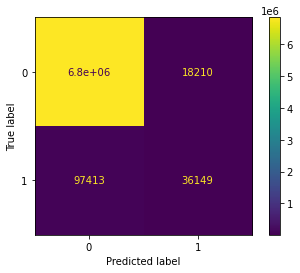

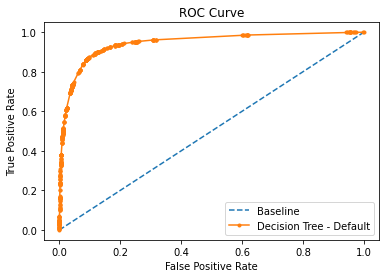

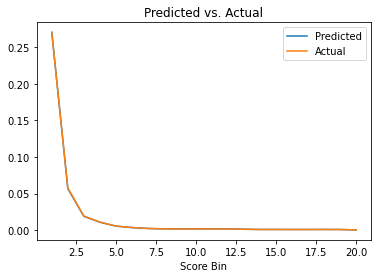

In [81]:
max_depth_num=10
# Decision Tree
model=DecisionTreeClassifier(max_depth=max_depth_num, random_state=101, max_features=None, min_samples_leaf=3)
model.fit(X_train, y_train)
preds=model.predict(X_test)
probs=model.predict_proba(X_test)
actuals=y_test.reset_index(drop=True)
model_name='Decision Tree - Default'

DT=model_evaluation()

In [90]:
predfile=pd.DataFrame({'sub_clm_aud_nbr': wholefile[wholefile['seg']=='val']['sub_clm_aud_nbr'], 'Predicted': preds})

# generate the confusion matrix for the validation file
predfile_actual=pd.merge(predfile, wholefile[wholefile['seg']=='val'][['sub_clm_aud_nbr', 'target']], on='sub_clm_aud_nbr', how='inner')
predfile_actual.info()

confusion_matrix=pd.crosstab(predfile_actual['target'], predfile_actual['Predicted'], 
                             rownames=['Actual'], colnames=['Predicted'])
print (confusion_matrix)

<class 'pandas.core.frame.DataFrame'>
Int64Index: 6985066 entries, 0 to 6985065
Data columns (total 3 columns):
 #   Column           Dtype 
---  ------           ----- 
 0   sub_clm_aud_nbr  object
 1   Predicted        int32 
 2   target           int32 
dtypes: int32(2), object(1)
memory usage: 159.9+ MB
Predicted        0      1
Actual                   
0          6833294  18210
1            97413  36149


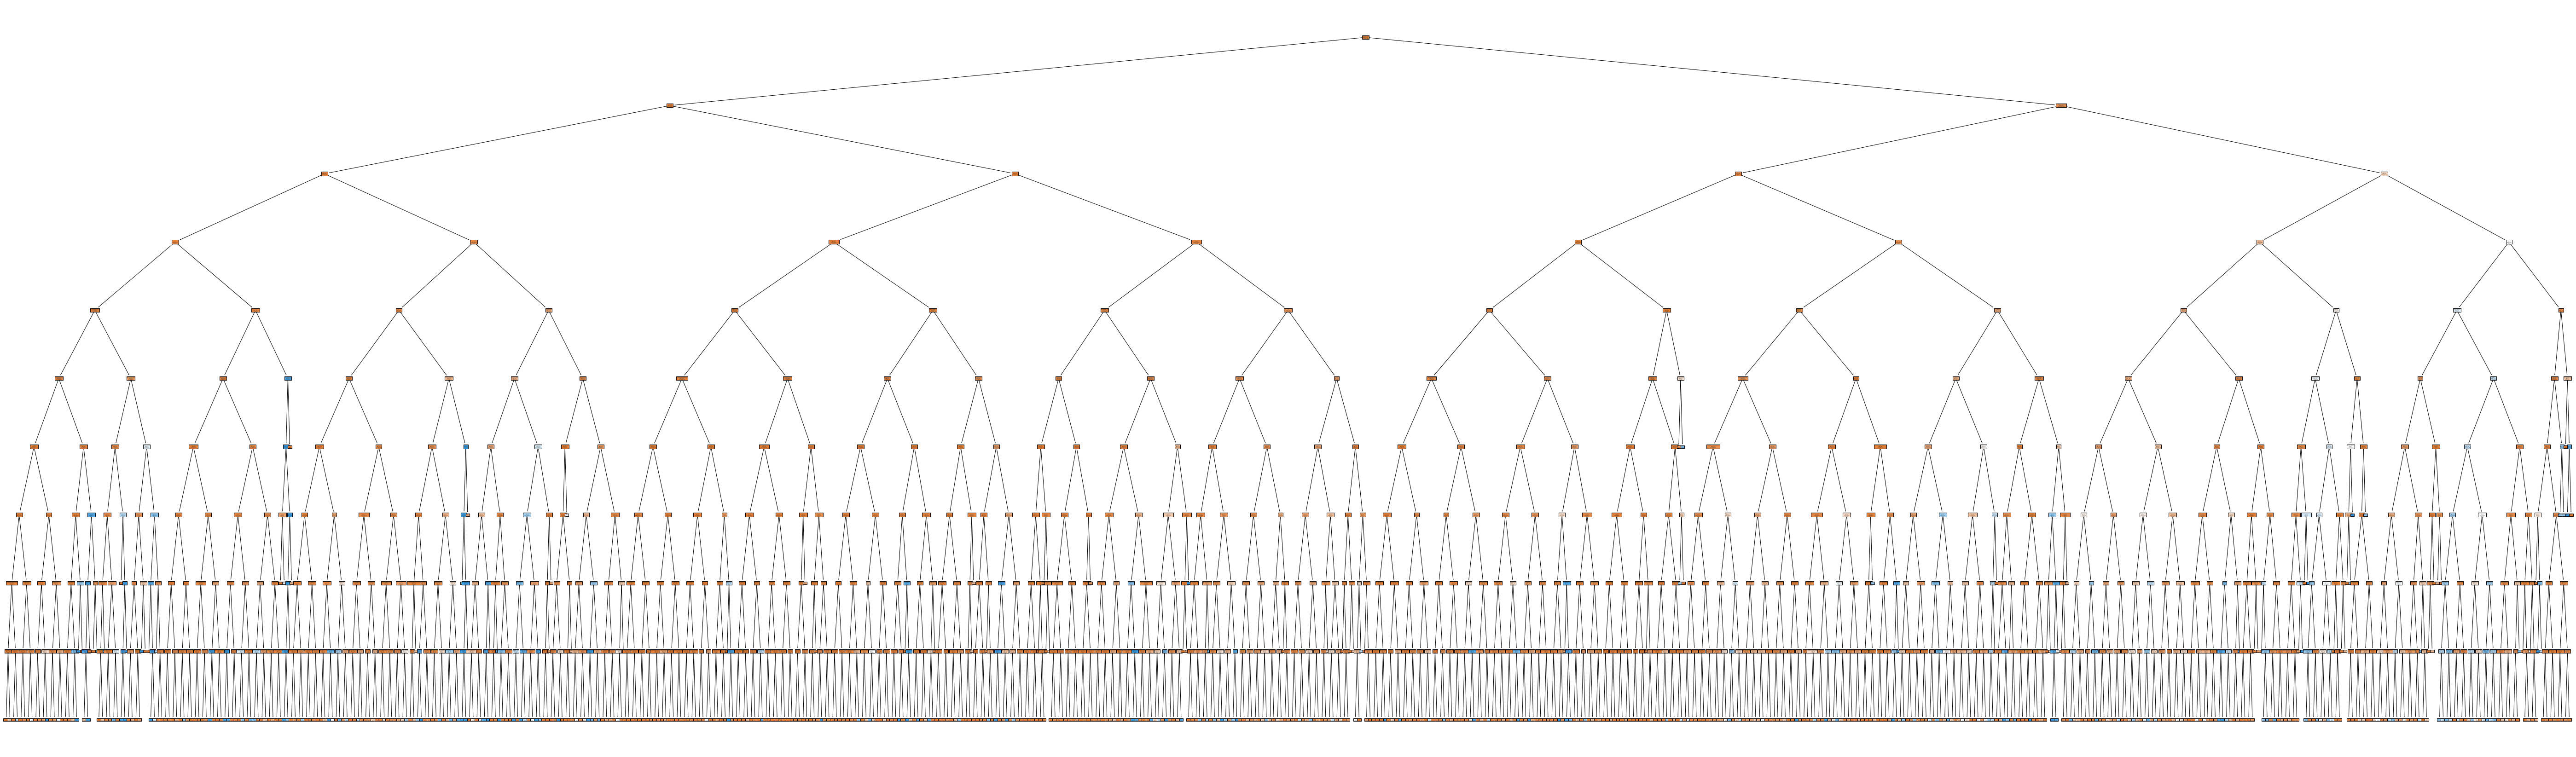

In [91]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

model=DecisionTreeClassifier(max_depth=max_depth_num, random_state=101, max_features=None, min_samples_leaf=3)
model=model.fit(X_train, y_train)

fig=plt.figure(figsize=(100, 30))
_ =tree.plot_tree(model, 
                  feature_names=X_train.columns, 
                  class_names=['0', '1'], filled=True)


tree.plot_tree
plt.savefig(docupath+'out10_20230531.pdf')

In [94]:
text_representation = tree.export_text(model)
print(text_representation)

|--- feature_0 <= 881.41
|   |--- feature_1 <= 0.50
|   |   |--- feature_0 <= 374.99
|   |   |   |--- feature_43 <= 0.50
|   |   |   |   |--- feature_176 <= 0.50
|   |   |   |   |   |--- feature_209 <= 0.50
|   |   |   |   |   |   |--- feature_110 <= 2.50
|   |   |   |   |   |   |   |--- feature_0 <= 234.59
|   |   |   |   |   |   |   |   |--- feature_212 <= 0.50
|   |   |   |   |   |   |   |   |   |--- feature_111 <= 6.50
|   |   |   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |   |   |   |--- feature_111 >  6.50
|   |   |   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |   |   |--- feature_212 >  0.50
|   |   |   |   |   |   |   |   |   |--- feature_26 <= 0.50
|   |   |   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |   |   |   |--- feature_26 >  0.50
|   |   |   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |   |--- feature_0 >  234.59
|   |   |   |   |   |   |   |   |--- feature_23 <= 0.50
|   |   | 

In [95]:
text_representation = tree.export_text(model, feature_names=X)
print(text_representation)

|--- clm_chrg_amt <= 881.41
|   |--- par_npar <= 0.50
|   |   |--- clm_chrg_amt <= 374.99
|   |   |   |--- diag_1_health_factor <= 0.50
|   |   |   |   |--- prov_spcl_INDEPENDENT_LAB <= 0.50
|   |   |   |   |   |--- prov_spcl_PSYCHOLOGIST <= 0.50
|   |   |   |   |   |   |--- proc_cpt1_pathology_lab <= 2.50
|   |   |   |   |   |   |   |--- clm_chrg_amt <= 234.59
|   |   |   |   |   |   |   |   |--- prov_spcl_REHABILITATION_MEDICINE <= 0.50
|   |   |   |   |   |   |   |   |   |--- proc_cpt1_medicine <= 6.50
|   |   |   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |   |   |   |--- proc_cpt1_medicine >  6.50
|   |   |   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |   |   |--- prov_spcl_REHABILITATION_MEDICINE >  0.50
|   |   |   |   |   |   |   |   |   |--- diag_1_endotrine_nutri_metab <= 0.50
|   |   |   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |   |   |   |--- diag_1_endotrine_nutri_metab >  0.50
|   |   |   |   |   |   

In [96]:
from sklearn.tree import _tree

def get_rules(tree, feature_names, class_names):
    tree_ = tree.tree_
    feature_name = [
        feature_names[i] if i != _tree.TREE_UNDEFINED else "undefined!"
        for i in tree_.feature
    ]

    paths = []
    path = []
    
    def recurse(node, path, paths):
        
        if tree_.feature[node] != _tree.TREE_UNDEFINED:
            name = feature_name[node]
            threshold = tree_.threshold[node]
            p1, p2 = list(path), list(path)
            p1 += [f"({name} <= {np.round(threshold, 3)})"]
            recurse(tree_.children_left[node], p1, paths)
            p2 += [f"({name} > {np.round(threshold, 3)})"]
            recurse(tree_.children_right[node], p2, paths)
        else:
            path += [(tree_.value[node], tree_.n_node_samples[node])]
            paths += [path]
            
    recurse(0, path, paths)

    # sort by samples count
    samples_count = [p[-1][1] for p in paths]
    ii = list(np.argsort(samples_count))
    paths = [paths[i] for i in reversed(ii)]
    
    rules = []
    for path in paths:
        rule = "if "
        
        for p in path[:-1]:
            if rule != "if ":
                rule += " and "
            rule += str(p)
        rule += " then "
        if class_names is None:
            rule += "response: "+str(np.round(path[-1][0][0][0],3))
        else:
            classes = path[-1][0][0]
            l = np.argmax(classes)
            rule += f"class: {class_names[l]} (proba: {np.round(100.0*classes[l]/np.sum(classes),2)}%)"
        rule += f" | based on {path[-1][1]:,} samples"
        rules += [rule]
        
    return rules

In [97]:
rules = get_rules(model, X, ["0", "1"])

for r in rules:
    print(r)

if (clm_chrg_amt <= 881.415) and (par_npar > 0.5) and (clm_chrg_amt <= 619.995) and (prov_spcl_EMERGENCY_MEDICINE <= 0.5) and (clm_chrg_amt <= 399.995) and (prov_spcl_REHABILITATION_MEDICINE <= 0.5) and (clm_chrg_amt <= 179.995) and (diag_1_nervous_system <= 0.5) and (proc_cpt1_pathology_lab <= 4.5) and (prov_spcl_OTOLARYNGOLOGIST <= 0.5) then class: 0 (proba: 99.92%) | based on 3,301,793 samples
if (clm_chrg_amt <= 881.415) and (par_npar > 0.5) and (clm_chrg_amt <= 619.995) and (prov_spcl_EMERGENCY_MEDICINE <= 0.5) and (clm_chrg_amt <= 399.995) and (prov_spcl_REHABILITATION_MEDICINE <= 0.5) and (clm_chrg_amt > 179.995) and (clm_chrg_amt > 180.965) and (pos_other_unlisted_faci <= 0.5) and (prov_spcl_PATHOLOGIST <= 0.5) then class: 0 (proba: 99.84%) | based on 2,934,466 samples
if (clm_chrg_amt <= 881.415) and (par_npar > 0.5) and (clm_chrg_amt <= 619.995) and (prov_spcl_EMERGENCY_MEDICINE <= 0.5) and (clm_chrg_amt > 399.995) and (prov_spcl_SOCIAL_WORKER <= 0.5) and (proc_cpt1_evaluatio

In [144]:
# save all rules to an output file
# But the following code does not work well
from contextlib import redirect_stdout

with open(dtrules+'out.txt', 'w') as f:
    with redirect_stdout(f):
        for r in rules:
            print(r)

In [145]:
f=pd.read_csv(dtrules+'out.txt', names=['rule'], header=None)
f

,,rule
if (clm_chrg_amt <= 881.415) and (par_npar > 0.5) and (clm_chrg_amt <= 619.995) and (prov_spcl_EMERGENCY_MEDICINE <= 0.5) and (clm_chrg_amt <= 399.995) and (prov_spcl_REHABILITATION_MEDICINE <= 0.5) and (clm_chrg_amt <= 179.995) and (diag_1_nervous_system <= 0.5) and (proc_cpt1_pathology_lab <= 4.5) and (prov_spcl_OTOLARYNGOLOGIST <= 0.5) then class: 0 (proba: 99.92%) | based on 3,301,793 samples
if (clm_chrg_amt <= 881.415) and (par_npar > 0.5) and (clm_chrg_amt <= 619.995) and (prov_spcl_EMERGENCY_MEDICINE <= 0.5) and (clm_chrg_amt <= 399.995) and (prov_spcl_REHABILITATION_MEDICINE <= 0.5) and (clm_chrg_amt > 179.995) and (clm_chrg_amt > 180.965) and (pos_other_unlisted_faci <= 0.5) and (prov_spcl_PATHOLOGIST <= 0.5) then class: 0 (proba: 99.84%) | based on 2,934,466 samples
if (clm_chrg_amt <= 881.415) and (par_npar > 0.5) and (clm_chrg_amt <= 619.995) and (prov_spcl_EMERGENCY_MEDICINE <= 0.5) and (clm_chrg_amt > 399.995) and (prov_spcl_SOCIAL_WORKER <= 0.5) and (proc_cpt1_evaluation_mgmt_serv <= 0.5) and (prov_spcl_PSYCHIATRIST <= 0.5) and (diag_1_respiratory <= 0.5) and (prov_spcl_PSYCHOLOGIST <= 0.5) then class: 0 (proba: 99.72%) | based on 460,743 samples,NaN
if (clm_chrg_amt <= 881.415) and (par_npar <= 0.5) and (clm_chrg_amt <= 374.995) and (diag_1_health_factor <= 0.5) and (prov_spcl_INDEPENDENT_LAB <= 0.5) and (prov_spcl_PSYCHOLOGIST <= 0.5) and (proc_cpt1_pathology_lab <= 2.5) and (clm_chrg_amt <= 234.59) and (prov_spcl_REHABILITATION_MEDICINE <= 0.5) and (proc_cpt1_medicine <= 6.5) then class: 0 (proba: 99.53%) | based on 270,118 samples,NaN
if (clm_chrg_amt > 881.415) and (prov_spcl_EMERGENCY_MEDICINE <= 0.5) and (rvnu_0000 <= 0.5) and (par_npar > 0.5) and (diag_1_injury_poisoning <= 1.5) and (pos_ambu_surgical_center <= 0.5) and (diag_1_mental_behavioral <= 0.5) and (proc_cpt1_evaluation_mgmt_serv <= 0.5) and (clm_chrg_amt <= 13461.15) and (prdct_EPO <= 0.5) then class: 0 (proba: 99.99%) | based on 240,085 samples,NaN
...,...,...
if (clm_chrg_amt > 881.415) and (prov_spcl_EMERGENCY_MEDICINE <= 0.5) and (rvnu_0000 > 0.5) and (clm_chrg_amt <= 4998.86) and (prdct_PPO > 0.5) and (par_npar > 0.5) and (prov_spcl_SPECIAL_PROVIDER_AGREEMENT <= 0.5) and (proc_cpt1_pathology_lab > 45.5) then class: 1 (proba: 66.67%) | based on 3 samples,NaN,NaN
if (clm_chrg_amt <= 881.415) and (par_npar > 0.5) and (clm_chrg_amt <= 619.995) and (prov_spcl_EMERGENCY_MEDICINE > 0.5) and (proc_cpt1_pathology_lab > 0.5) and (diag_1_health_factor <= 0.5) and (proc_cpt1_medicine <= 1.5) and (clm_chrg_amt > 399.5) and (diag_1_ear_mastoid > 0.5) and (clm_chrg_amt <= 431.0) then class: 1 (proba: 66.67%) | based on 3 samples,NaN,NaN
if (clm_chrg_amt <= 881.415) and (par_npar > 0.5) and (clm_chrg_amt <= 619.995) and (prov_spcl_EMERGENCY_MEDICINE > 0.5) and (proc_cpt1_pathology_lab > 0.5) and (diag_1_health_factor <= 0.5) and (proc_cpt1_medicine > 1.5) and (diag_4_mental_behavioral <= 0.5) and (prdct_GIL > 0.5) then class: 0 (proba: 66.67%) | based on 3 samples,NaN,NaN
if (clm_chrg_amt > 881.415) and (prov_spcl_EMERGENCY_MEDICINE <= 0.5) and (rvnu_0000 <= 0.5) and (par_npar > 0.5) and (diag_1_injury_poisoning <= 1.5) and (pos_ambu_surgical_center > 0.5) and (diag_1_musculoskeletal > 1.5) and (prdct_PPO > 0.5) then class: 0 (proba: 100.0%) | based on 3 samples,NaN,NaN


### save the decision tree model to a pickcle file

In [146]:
import gzip 
import pickle

In [147]:
#save the model object as well as the training and test sets in a gzip file
objects = ['X_train', 'X_test', 'y_train', 'y_test','model']
filename = 'decision_tree_unbalanced_%s'%datetime.now().strftime('m_%d_%Y_%H_%M')

In [148]:
with gzip.GzipFile(f"C:/Users/aleci/Documents/NumInformatics/HSCRC_touch/documents/{filename}_samp.pkl.gz", mode="wb", compresslevel=6) as fil:
    for x in objects:
        pickle.dump(globals()[x], fil)

### Rerun the model by using a balanced sample

In [149]:
# rerun the model by using a balanced sample
len(wholefile[wholefile['target']==1]['target'])

333136

In [150]:
wholefile_target0=wholefile[wholefile['target']==0].sample(len(wholefile[wholefile['target']==1]['target']))
wholefile_target0['target'].mean()
wholefile_target0.shape                        

(333136, 248)

In [151]:
wholefile2=pd.concat([wholefile_target0, wholefile[wholefile['target']==1]])
wholefile2['target'].mean()

0.5

In [152]:
df=wholefile2[wholefile2['seg']=='mod']
df=df[df['seq']%10 < 2]
print(df['target'].mean())
df.info()

nan
<class 'pandas.core.frame.DataFrame'>
Int64Index: 0 entries
Columns: 248 entries, seq to seg
dtypes: float64(7), int32(133), int64(2), object(2), uint8(104)
memory usage: 0.0+ bytes


In [96]:
wholefile2.shape

(666412, 249)

In [155]:
max_depth_num=10

In [156]:
X_train=wholefile2[wholefile2['seg']=='mod'][X]
y_train=wholefile2[wholefile2['seg']=='mod'][target]

Accuracy: 0.894
Precision: 0.888
Recall: 0.902


C:\Users\aleci\anaconda3\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function plot_confusion_matrix is deprecated; Function `plot_confusion_matrix` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: ConfusionMatrixDisplay.from_predictions or ConfusionMatrixDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


Baseline: ROC AUC = 0.500
Decision Tree - Default: ROC AUC = 0.948


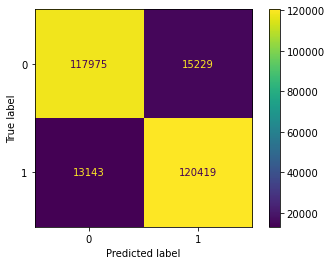

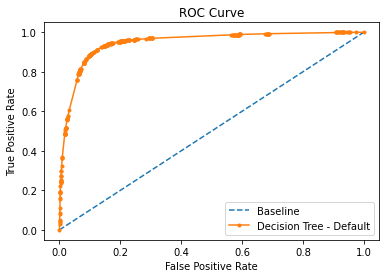

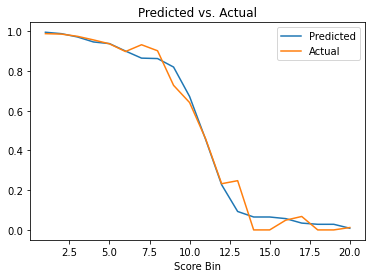

In [157]:
## used the balanced validation sample 
X_test=wholefile2[wholefile2['seg']=='val'][X]
y_test=wholefile2[wholefile2['seg']=='val'][target]

# Decision Tree
model=DecisionTreeClassifier(criterion="entropy", max_depth=max_depth_num, random_state=101, max_features=None, min_samples_leaf=3,
                            min_samples_split=5)
model.fit(X_train, y_train)
preds=model.predict(X_test)
probs=model.predict_proba(X_test)
actuals=y_test.reset_index(drop=True)
model_name='Decision Tree - Default'

DT=model_evaluation()

Accuracy: 0.886
Precision: 0.133
Recall: 0.902


C:\Users\aleci\anaconda3\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function plot_confusion_matrix is deprecated; Function `plot_confusion_matrix` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: ConfusionMatrixDisplay.from_predictions or ConfusionMatrixDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


Baseline: ROC AUC = 0.500
Decision Tree - Default: ROC AUC = 0.948


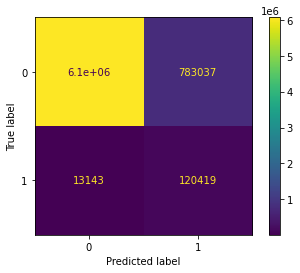

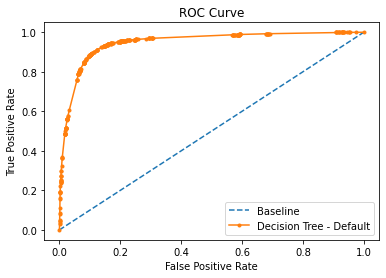

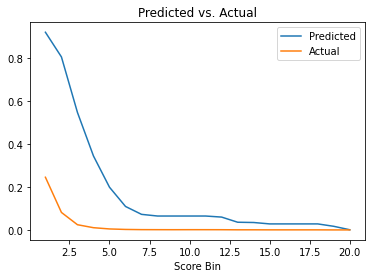

In [158]:
## used the unbalanced validation sample 
X_test=wholefile[wholefile['seg']=='val'][X]
y_test=wholefile[wholefile['seg']=='val'][target]

# Decision Tree
model=DecisionTreeClassifier(criterion="entropy", max_depth=max_depth_num, random_state=101, max_features=None, min_samples_leaf=3,
                            min_samples_split=5)
model.fit(X_train, y_train)
preds=model.predict(X_test)
probs=model.predict_proba(X_test)
actuals=y_test.reset_index(drop=True)
model_name='Decision Tree - Default'

DT=model_evaluation()

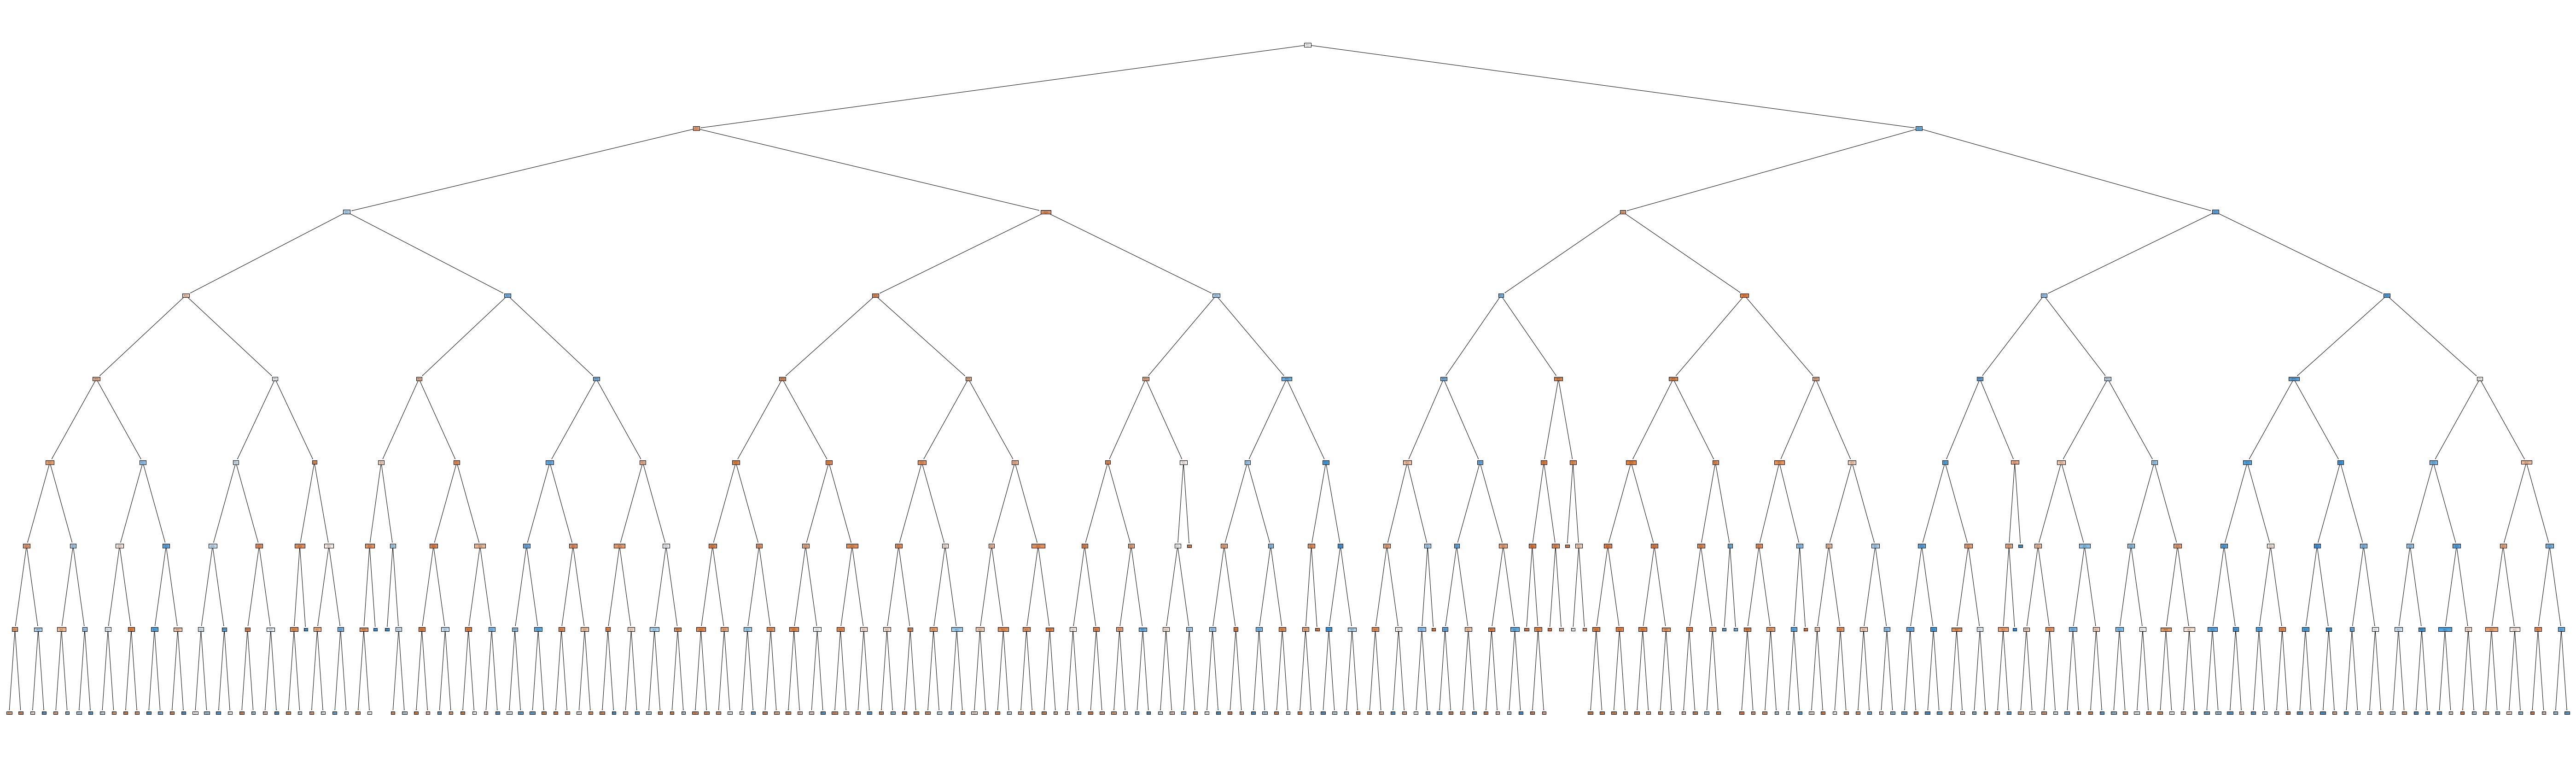

In [99]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

# Set the random state so that the algorithm will remain the same when rerunning the model
model=DecisionTreeClassifier(max_depth=max_depth_num, random_state=101, max_features=None, min_samples_leaf=3)
model=model.fit(X_train, y_train)

fig=plt.figure(figsize=(100, 30))
_ =tree.plot_tree(model, 
                  feature_names=X_train.columns, 
                  class_names=['0', '1'], filled=True)


tree.plot_tree
plt.savefig(docupath+'out10_20230511.pdf')

In [100]:
text_representation = tree.export_text(model)
print(text_representation)

|--- feature_0 <= 549.97
|   |--- feature_1 <= 0.50
|   |   |--- feature_43 <= 0.50
|   |   |   |--- feature_0 <= 248.69
|   |   |   |   |--- feature_21 <= 0.50
|   |   |   |   |   |--- feature_110 <= 1.50
|   |   |   |   |   |   |--- feature_109 <= 0.50
|   |   |   |   |   |   |   |--- feature_138 <= 0.50
|   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |   |--- feature_138 >  0.50
|   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |--- feature_109 >  0.50
|   |   |   |   |   |   |   |--- feature_17 <= 0.50
|   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |   |--- feature_17 >  0.50
|   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- feature_110 >  1.50
|   |   |   |   |   |   |--- feature_0 <= 64.05
|   |   |   |   |   |   |   |--- feature_37 <= 0.50
|   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |   |--- feature_37 >  0.50
|   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |

In [101]:
text_representation = tree.export_text(model, feature_names=X)
print(text_representation)

|--- clm_chrg_amt <= 549.97
|   |--- par_npar <= 0.50
|   |   |--- diag_1_health_factor <= 0.50
|   |   |   |--- clm_chrg_amt <= 248.69
|   |   |   |   |--- pos_independent_lab <= 0.50
|   |   |   |   |   |--- proc_cpt1_pathology_lab <= 1.50
|   |   |   |   |   |   |--- proc_cpt1_radiology <= 0.50
|   |   |   |   |   |   |   |--- prdct_IND <= 0.50
|   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |   |--- prdct_IND >  0.50
|   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |--- proc_cpt1_radiology >  0.50
|   |   |   |   |   |   |   |--- pos_skilled_nursing_faci <= 0.50
|   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |   |--- pos_skilled_nursing_faci >  0.50
|   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- proc_cpt1_pathology_lab >  1.50
|   |   |   |   |   |   |--- clm_chrg_amt <= 64.05
|   |   |   |   |   |   |   |--- diag_1_pregnancy_childbirth <= 0.50
|   |   |   |   |   |   |   |   |--- class: 0
|  

In [102]:
from sklearn.tree import export_text

# Assuming you have already trained a decision tree model called 'clf'

# Extract the rules as text
tree_rules = export_text(model, feature_names=X)

print(tree_rules)

|--- clm_chrg_amt <= 549.97
|   |--- par_npar <= 0.50
|   |   |--- diag_1_health_factor <= 0.50
|   |   |   |--- clm_chrg_amt <= 248.69
|   |   |   |   |--- pos_independent_lab <= 0.50
|   |   |   |   |   |--- proc_cpt1_pathology_lab <= 1.50
|   |   |   |   |   |   |--- proc_cpt1_radiology <= 0.50
|   |   |   |   |   |   |   |--- prdct_IND <= 0.50
|   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |   |--- prdct_IND >  0.50
|   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |--- proc_cpt1_radiology >  0.50
|   |   |   |   |   |   |   |--- pos_skilled_nursing_faci <= 0.50
|   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |   |--- pos_skilled_nursing_faci >  0.50
|   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- proc_cpt1_pathology_lab >  1.50
|   |   |   |   |   |   |--- clm_chrg_amt <= 64.05
|   |   |   |   |   |   |   |--- diag_1_pregnancy_childbirth <= 0.50
|   |   |   |   |   |   |   |   |--- class: 0
|  

In [103]:
def get_rules(tree, feature_names, class_names):
    tree_ = tree.tree_
    feature_name = [
        feature_names[i] if i != _tree.TREE_UNDEFINED else "undefined!"
        for i in tree_.feature
    ]

    paths = []
    path = []
    
    def recurse(node, path, paths):
        
        if tree_.feature[node] != _tree.TREE_UNDEFINED:
            name = feature_name[node]
            threshold = tree_.threshold[node]
            p1, p2 = list(path), list(path)
            p1 += [f"({name} <= {np.round(threshold, 3)})"]
            recurse(tree_.children_left[node], p1, paths)
            p2 += [f"({name} > {np.round(threshold, 3)})"]
            recurse(tree_.children_right[node], p2, paths)
        else:
            path += [(tree_.value[node], tree_.n_node_samples[node])]
            paths += [path]
            
    recurse(0, path, paths)

    # sort by samples count
    samples_count = [p[-1][1] for p in paths]
    ii = list(np.argsort(samples_count))
    paths = [paths[i] for i in reversed(ii)]
    
    rules = []
    for path in paths:
        rule = "if "
        
        for p in path[:-1]:
            if rule != "if ":
                rule += " and "
            rule += str(p)
        rule += " then "
        if class_names is None:
            rule += "response: "+str(np.round(path[-1][0][0][0],3))
        else:
            classes = path[-1][0][0]
            l = np.argmax(classes)
            rule += f"class: {class_names[l]} (proba: {np.round(100.0*classes[l]/np.sum(classes),2)}%)"
        rule += f" | based on {path[-1][1]:,} samples"
        rules += [rule]
        
    return rules

In [104]:
rules = get_rules(model, X, ["0", "1"])
for r in rules:
    print(r)

if (clm_chrg_amt <= 549.97) and (par_npar > 0.5) and (prov_spcl_EMERGENCY_MEDICINE <= 0.5) and (clm_chrg_amt <= 399.98) and (clm_chrg_amt > 179.995) and (clm_chrg_amt > 188.015) and (prov_spcl_REHABILITATION_MEDICINE <= 0.5) and (pos_other_unlisted_faci <= 0.5) then class: 0 (proba: 92.18%) | based on 61,696 samples
if (clm_chrg_amt <= 549.97) and (par_npar > 0.5) and (prov_spcl_EMERGENCY_MEDICINE <= 0.5) and (clm_chrg_amt <= 399.98) and (clm_chrg_amt <= 179.995) and (pos_other_unlisted_faci <= 0.5) and (proc_cpt1_pathology_lab <= 3.5) and (prov_spcl_FAMILY_PRACTICE <= 0.5) then class: 0 (proba: 96.43%) | based on 60,904 samples
if (clm_chrg_amt > 549.97) and (rvnu_0000 > 0.5) and (clm_chrg_amt > 880.77) and (prdct_PPO <= 0.5) and (prov_spcl_EMERGENCY_MEDICINE <= 0.5) and (prov_spcl_PEDIATRICIAN <= 0.5) and (clm_chrg_amt <= 3401.305) and (prov_spcl_ANESTHESIOLOGIST <= 0.5) then class: 1 (proba: 87.55%) | based on 59,394 samples
if (clm_chrg_amt > 549.97) and (rvnu_0000 > 0.5) and (clm_

# Step 6 - Logistic Regression Model

In [64]:
wholefile['clm_chrg_amt_tr']=np.where(wholefile['clm_chrg_amt'] < 0, 0, 
                                      np.where(wholefile['clm_chrg_amt'] > 100000, 100000, wholefile['clm_chrg_amt']))

wholefile['clm_ded_amt_tr']=np.where(wholefile['clm_ded_amt'] <= 0, 1, 0)
wholefile['clm_coin_amt_tr']=np.where(wholefile['clm_coin_amt'] <= 0, 1, 0)
wholefile['clm_copay_amt_tr']=np.where(wholefile['clm_copay_amt'] <= 0, 1, 0)
wholefile['clm_alw_amt_tr']=np.where(wholefile['clm_alw_amt'] <= 0, 1, 0)
wholefile['clm_copay_amt_tr']=np.where(wholefile['clm_copay_amt'] <= 100, 1, 0)
wholefile['clm_not_cov_amt_tr']=np.where(wholefile['clm_not_cov_amt'] <= 0, 1, 0)
wholefile['clm_pd_amt_tr']=np.where(wholefile['clm_pd_amt'] <= 52.85, 1, 0)

wholefile['clm_chrg_amt_log']=np.log(wholefile['clm_chrg_amt_tr']+1)

In [65]:
select_columns=['target',
'clm_chrg_amt_log',
# 'clm_ded_amt_tr',
# 'clm_coin_amt_tr',
# 'clm_copay_amt_tr',
# 'clm_alw_amt_tr',
# 'clm_not_cov_amt_tr',
# 'clm_pd_amt_tr',
'prov_spcl_EMERGENCY_MEDICINE',
'par_npar',
'pos_office',
'rvnu_0000',
'rvnu_other',
'proc_cpt1_surgery',
'prov_spcl_PEDIATRICIAN',
'prdct_PPO',
'proc_cpt1_evaluation_mgmt_serv',
'prov_spcl_SOCIAL_WORKER',
'pos_outpatient_hospital',
'prov_spcl_FAMILY_PRACTICE',
'proc_cpt1_medicine',
'prov_spcl_RADIOLOGIST',
'prov_spcl_RN__SPECIAL_SERVICE',
'diag_1_injury_poisoning',
'proc_cpt1_radiology',
'prdct_IND',
'prov_spcl_ORTHOPEDIST',
'prov_spcl_PHYSICAL_OCCUPATIONAL_THERAPY',
'diag_1_mental_behavioral',
'prov_spcl_PATHOLOGIST',
'prov_spcl_AFTER_HOURS_CLINIC_URGENT_CARE',
'pos_inpatient_hospital',
'proc_cpt2_diagnostic_screening',
'prov_spcl_ANESTHESIOLOGIST',
'diag_2_health_factor',
'prov_spcl_INTERNIST',
'pos_independent_lab',
'rvnu_0240',
'prdct_PS1',
'prdct_MIN',
'diag_2_injury_poisoning',
'diag_2_abnormal_finding',
'prov_spcl_HOSPITALIST',
'proc_cpt1_pathology_lab',
'proc_cpt2_patient_history',
'prov_spcl_REHABILITATION_MEDICINE',
'prov_spcl_OPTOMETRIST'
]

In [66]:
df_mod=wholefile[wholefile['seg']=='mod']
df_val=wholefile[wholefile['seg']=='val']

In [67]:
df_mod[select_columns].corr()

,target,clm_chrg_amt_log,prov_spcl_EMERGENCY_MEDICINE,par_npar,pos_office,rvnu_0000,rvnu_other,proc_cpt1_surgery,prov_spcl_PEDIATRICIAN,prdct_PPO,...,rvnu_0240,prdct_PS1,prdct_MIN,diag_2_injury_poisoning,diag_2_abnormal_finding,prov_spcl_HOSPITALIST,proc_cpt1_pathology_lab,proc_cpt2_patient_history,prov_spcl_REHABILITATION_MEDICINE,prov_spcl_OPTOMETRIST
target,1.000000,0.160782,0.193964,-0.139990,-0.055414,0.036033,-0.034075,0.051789,-0.025176,-0.029342,...,-0.010779,0.012767,-0.008343,0.015957,0.018505,0.018211,-0.012265,-0.010893,0.018689,-0.009530
clm_chrg_amt_log,0.160782,1.000000,0.086860,-0.034073,-0.184490,-0.381425,0.391999,0.178198,-0.027614,0.018942,...,0.019497,-0.020522,0.008023,0.043335,0.064765,0.012000,0.089353,-0.009716,0.017129,-0.019736
prov_spcl_EMERGENCY_MEDICINE,0.193964,0.086860,1.000000,-0.094833,-0.095727,0.048491,-0.046008,-0.028615,-0.032755,-0.002807,...,-0.014046,-0.005019,-0.000551,0.027462,0.067168,-0.011798,-0.038716,-0.014656,-0.012657,-0.011395
par_npar,-0.139990,-0.034073,-0.094833,1.000000,0.130947,-0.030231,0.038168,0.044604,0.066328,-0.006504,...,-0.019908,0.119098,-0.190506,-0.000932,0.008168,-0.007676,0.059911,0.025556,-0.017613,0.003375
pos_office,-0.055414,-0.184490,-0.095727,0.130947,1.000000,0.348547,-0.330478,0.005460,0.174529,0.032989,...,-0.101624,-0.006977,-0.011117,-0.010413,-0.016905,-0.056084,-0.067861,0.098900,0.031550,0.062624
rvnu_0000,0.036033,-0.381425,0.048491,-0.030231,0.348547,1.000000,-0.948547,-0.046319,0.066486,0.062431,...,-0.290388,-0.030275,-0.012829,-0.052383,-0.079860,0.023805,-0.005169,0.035620,0.025431,0.023114
rvnu_other,-0.034075,0.391999,-0.046008,0.038168,-0.330478,-0.948547,1.000000,0.054809,-0.063077,-0.070422,...,-0.027545,0.037421,0.008485,0.052495,0.084933,-0.022561,0.015950,-0.033786,-0.024143,-0.021918
proc_cpt1_surgery,0.051789,0.178198,-0.028615,0.044604,0.005460,-0.046319,0.054809,1.000000,-0.018604,0.022781,...,-0.019411,-0.011703,0.004800,0.009949,0.003619,-0.015434,0.193205,0.006999,0.018948,-0.015344
prov_spcl_PEDIATRICIAN,-0.025176,-0.027614,-0.032755,0.066328,0.174529,0.066486,-0.063077,-0.018604,1.000000,-0.016845,...,-0.019273,0.021606,-0.015214,-0.017724,0.008659,-0.015995,0.031391,0.008637,-0.017160,-0.015448
prdct_PPO,-0.029342,0.018942,-0.002807,-0.006504,0.032989,0.062431,-0.070422,0.022781,-0.016845,1.000000,...,0.015726,-0.500985,-0.024848,-0.000524,-0.005060,0.006713,-0.022504,0.007518,0.031500,0.005823


<AxesSubplot:>

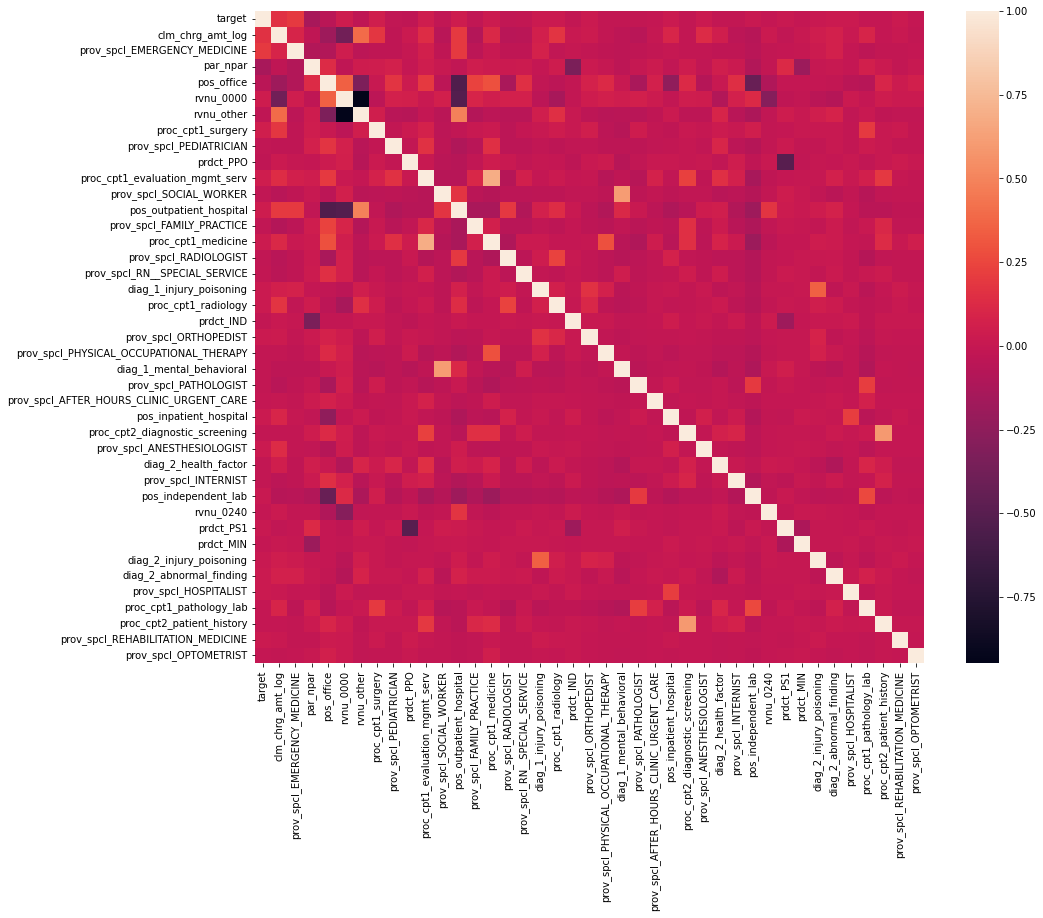

In [68]:
# We now plot the correlations
fig=plt.figure(figsize=(15, 12))
sns.heatmap(df_mod[select_columns].corr())

<AxesSubplot:title={'center':'Correlations with % Claim'}>

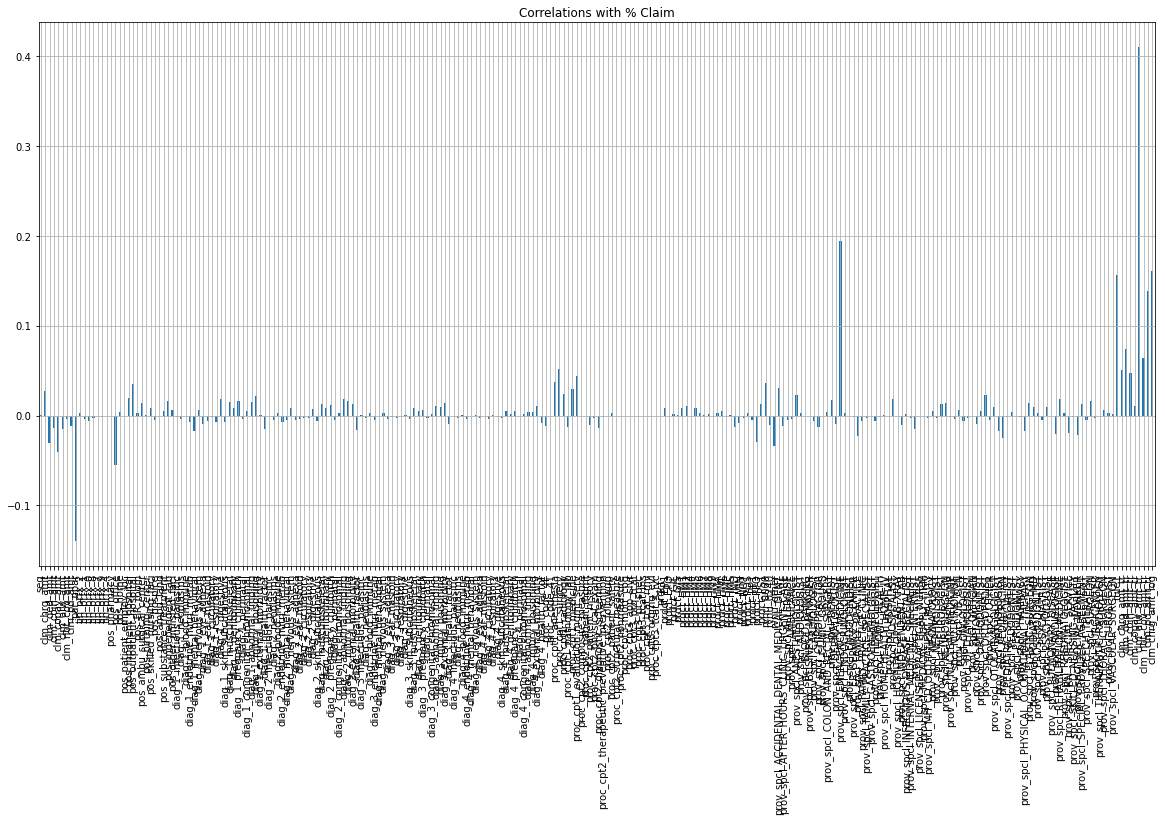

In [69]:
df_mod2=df_mod.drop('target', axis=1)
df_mod2.corrwith(df_mod['target']).plot.bar(
figsize=(20, 10), title='Correlations with % Claim', rot=90, grid=True)

In [70]:
#!pip install --upgrade numpy==1.23.1

In [71]:
import statsmodels.formula.api as smf

#model=smf.logit('target ~ clm_chrg_amt_log+clm_ded_amt_tr+clm_coin_amt_tr+clm_copay_amt_tr+clm_alw_amt_tr+clm_not_cov_amt_tr+clm_pd_amt_tr+proc_cd_v+edit_err_wrn_nbr_v+edit_wrn_seq_nbr_v+edit_flag_v+prov_spcl_catgy_cd_v+edit_err_wrn_cd_v+diag_1_cd_v+edit_partn_id_v+par_npar_v+prov_tin_sufx_cd_v+diag_2_cd_v+cobi_pend_cd_1_v+fn_pend_cd_desc_1_v+diag_3_cd_v+rvnu_cd_v+pos_desc_v+diag_4_cd_v+prdct_cd_v', data=df_mod).fit()

# remove edit_partn_id because it is highly correlated with edit_err_wrn_cd
#model=smf.logit('target ~ +clm_chrg_amt_log+clm_ded_amt_tr+clm_coin_amt_tr+clm_copay_amt_tr+clm_alw_amt_tr+clm_not_cov_amt_tr+clm_pd_amt_tr+prov_spcl_EMERGENCY_MEDICINE+par_npar+pos_office+rvnu_0000+rvnu_other+proc_cpt1_surgery+prov_spcl_PEDIATRICIAN+prdct_PPO+proc_cpt1_evaluation_mgmt_serv+prov_spcl_SOCIAL_WORKER+pos_outpatient_hospital+prov_spcl_FAMILY_PRACTICE+proc_cpt1_medicine+prov_spcl_RADIOLOGIST+prov_spcl_RN__SPECIAL_SERVICE+diag_1_injury_poisoning+proc_cpt1_radiology+prdct_IND+prov_spcl_ORTHOPEDIST+prov_spcl_PHYSICAL_OCCUPATIONAL_THERAPY+diag_1_mental_behavioral+prov_spcl_PATHOLOGIST+prov_spcl_AFTER_HOURS_CLINIC_URGENT_CARE+pos_inpatient_hospital+proc_cpt2_diagnostic_screening+prov_spcl_ANESTHESIOLOGIST+diag_2_health_factor+prov_spcl_INTERNIST+pos_independent_lab+rvnu_0240+prdct_PS1+prdct_MIN+diag_2_injury_poisoning+diag_2_abnormal_finding+prov_spcl_HOSPITALIST+proc_cpt1_pathology_lab+proc_cpt2_patient_history+prov_spcl_REHABILITATION_MEDICINE+prov_spcl_OPTOMETRIST', data=df_mod).fit()
model=smf.logit('target ~ +clm_chrg_amt_log+prov_spcl_EMERGENCY_MEDICINE+par_npar+pos_office+rvnu_other+proc_cpt1_surgery+prov_spcl_PEDIATRICIAN+prdct_PPO+proc_cpt1_evaluation_mgmt_serv+prov_spcl_SOCIAL_WORKER+pos_outpatient_hospital+prov_spcl_FAMILY_PRACTICE+proc_cpt1_medicine+prov_spcl_RADIOLOGIST+prov_spcl_RN__SPECIAL_SERVICE+diag_1_injury_poisoning+proc_cpt1_radiology+prdct_IND+prov_spcl_ORTHOPEDIST+prov_spcl_PHYSICAL_OCCUPATIONAL_THERAPY+diag_1_mental_behavioral+prov_spcl_PATHOLOGIST+prov_spcl_AFTER_HOURS_CLINIC_URGENT_CARE+pos_inpatient_hospital+proc_cpt2_diagnostic_screening+prov_spcl_ANESTHESIOLOGIST+diag_2_health_factor+prov_spcl_INTERNIST+pos_independent_lab+rvnu_0240+prdct_PS1+prdct_MIN+diag_2_injury_poisoning+diag_2_abnormal_finding+prov_spcl_HOSPITALIST+proc_cpt1_pathology_lab+proc_cpt2_patient_history+prov_spcl_REHABILITATION_MEDICINE+prov_spcl_OPTOMETRIST', data=df_mod).fit()


#view model summary
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.062889
         Iterations 11
                           Logit Regression Results                           
Dep. Variable:                 target   No. Observations:              3497233
Model:                          Logit   Df Residuals:                  3497193
Method:                           MLE   Df Model:                           39
Date:                Wed, 24 May 2023   Pseudo R-squ.:                  0.3335
Time:                        21:18:32   Log-Likelihood:            -2.1994e+05
converged:                       True   LL-Null:                   -3.2998e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                               coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------
Intercept                                   -9.

In [72]:
import statsmodels.formula.api as smf

#model=smf.logit('target ~ clm_chrg_amt_log+clm_ded_amt_tr+clm_coin_amt_tr+clm_copay_amt_tr+clm_alw_amt_tr+clm_not_cov_amt_tr+clm_pd_amt_tr+proc_cd_v+edit_err_wrn_nbr_v+edit_wrn_seq_nbr_v+edit_flag_v+prov_spcl_catgy_cd_v+edit_err_wrn_cd_v+diag_1_cd_v+edit_partn_id_v+par_npar_v+prov_tin_sufx_cd_v+diag_2_cd_v+cobi_pend_cd_1_v+fn_pend_cd_desc_1_v+diag_3_cd_v+rvnu_cd_v+pos_desc_v+diag_4_cd_v+prdct_cd_v', data=df_mod).fit()

# remove edit_partn_id because it is highly correlated with edit_err_wrn_cd
#model=smf.logit('target ~ +clm_chrg_amt_log+clm_ded_amt_tr+clm_coin_amt_tr+clm_copay_amt_tr+clm_alw_amt_tr+clm_not_cov_amt_tr+clm_pd_amt_tr+prov_spcl_EMERGENCY_MEDICINE+par_npar+pos_office+proc_cpt1_surgery+prov_spcl_PEDIATRICIAN+prdct_PPO+proc_cpt1_evaluation_mgmt_serv+prov_spcl_SOCIAL_WORKER+pos_outpatient_hospital+prov_spcl_FAMILY_PRACTICE+proc_cpt1_medicine+prov_spcl_RADIOLOGIST+prov_spcl_RN__SPECIAL_SERVICE+diag_1_injury_poisoning+proc_cpt1_radiology+prdct_IND+prov_spcl_PHYSICAL_OCCUPATIONAL_THERAPY+diag_1_mental_behavioral+prov_spcl_PATHOLOGIST+prov_spcl_AFTER_HOURS_CLINIC_URGENT_CARE+pos_inpatient_hospital+proc_cpt2_diagnostic_screening+prov_spcl_ANESTHESIOLOGIST+diag_2_health_factor+prov_spcl_INTERNIST+pos_independent_lab+rvnu_0240+prdct_PS1+prdct_MIN+diag_2_injury_poisoning+diag_2_abnormal_finding+prov_spcl_HOSPITALIST+proc_cpt1_pathology_lab+proc_cpt2_patient_history+prov_spcl_REHABILITATION_MEDICINE+prov_spcl_OPTOMETRIST', data=df_mod).fit()
model=smf.logit('target ~ +clm_chrg_amt_log+prov_spcl_EMERGENCY_MEDICINE+par_npar+rvnu_other+proc_cpt1_surgery+prov_spcl_PEDIATRICIAN+prdct_PPO+proc_cpt1_evaluation_mgmt_serv+prov_spcl_SOCIAL_WORKER+pos_outpatient_hospital+prov_spcl_FAMILY_PRACTICE+proc_cpt1_medicine+prov_spcl_RADIOLOGIST+prov_spcl_RN__SPECIAL_SERVICE+diag_1_injury_poisoning+proc_cpt1_radiology+prdct_IND+prov_spcl_ORTHOPEDIST+prov_spcl_PHYSICAL_OCCUPATIONAL_THERAPY+diag_1_mental_behavioral+prov_spcl_PATHOLOGIST+prov_spcl_AFTER_HOURS_CLINIC_URGENT_CARE+pos_inpatient_hospital+proc_cpt2_diagnostic_screening+prov_spcl_ANESTHESIOLOGIST+diag_2_health_factor+pos_independent_lab+rvnu_0240+prdct_PS1+prdct_MIN+diag_2_injury_poisoning+diag_2_abnormal_finding+prov_spcl_HOSPITALIST+proc_cpt1_pathology_lab+proc_cpt2_patient_history+prov_spcl_REHABILITATION_MEDICINE+prov_spcl_OPTOMETRIST', data=df_mod).fit()


#view model summary
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.062889
         Iterations 11
                           Logit Regression Results                           
Dep. Variable:                 target   No. Observations:              3497233
Model:                          Logit   Df Residuals:                  3497195
Method:                           MLE   Df Model:                           37
Date:                Wed, 24 May 2023   Pseudo R-squ.:                  0.3335
Time:                        21:19:08   Log-Likelihood:            -2.1994e+05
converged:                       True   LL-Null:                   -3.2998e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                               coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------
Intercept                                   -9.

In [73]:
def logit(x):
   
    x['risk_score']=-9.6183+1.1154*x['clm_chrg_amt_log']+1.7845*x['prov_spcl_EMERGENCY_MEDICINE']+-1.6063*x['par_npar']+-4.5615*x['rvnu_other']+0.6006*x['proc_cpt1_surgery']+-1.4561*x['prov_spcl_PEDIATRICIAN']+-1.7482*x['prdct_PPO']+0.5538*x['proc_cpt1_evaluation_mgmt_serv']+-0.7094*x['prov_spcl_SOCIAL_WORKER']+-0.2464*x['pos_outpatient_hospital']+-0.0882*x['prov_spcl_FAMILY_PRACTICE']+0.1292*x['proc_cpt1_medicine']+-0.9969*x['prov_spcl_RADIOLOGIST']+-0.4443*x['prov_spcl_RN__SPECIAL_SERVICE']+-0.1959*x['diag_1_injury_poisoning']+0.6886*x['proc_cpt1_radiology']+-3.3537*x['prdct_IND']+0.3756*x['prov_spcl_ORTHOPEDIST']+-0.3639*x['prov_spcl_PHYSICAL_OCCUPATIONAL_THERAPY']+-0.0852*x['diag_1_mental_behavioral']+-0.5868*x['prov_spcl_PATHOLOGIST']+-1.3347*x['prov_spcl_AFTER_HOURS_CLINIC_URGENT_CARE']+-0.2122*x['pos_inpatient_hospital']+-0.6858*x['proc_cpt2_diagnostic_screening']+-0.58*x['prov_spcl_ANESTHESIOLOGIST']+-0.1788*x['diag_2_health_factor']+0.8235*x['pos_independent_lab']+-2.8622*x['rvnu_0240']+-0.0266*x['prdct_PS1']+-3.1365*x['prdct_MIN']+0.2078*x['diag_2_injury_poisoning']+0.1788*x['diag_2_abnormal_finding']+1.2432*x['prov_spcl_HOSPITALIST']+-0.4952*x['proc_cpt1_pathology_lab']+-0.2288*x['proc_cpt2_patient_history']+0.8533*x['prov_spcl_REHABILITATION_MEDICINE']+-1.7467*x['prov_spcl_OPTOMETRIST']

    x['risk_score']=1/(1+np.exp(-1*x['risk_score']))+np.random.uniform(0, 0.00000001, len(x['target']))
    
logit(df_mod)
logit(df_val)

C:\Users\aleci\AppData\Local\Temp/ipykernel_18988/4244308687.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x['risk_score']=-9.6183+1.1154*x['clm_chrg_amt_log']+1.7845*x['prov_spcl_EMERGENCY_MEDICINE']+-1.6063*x['par_npar']+-4.5615*x['rvnu_other']+0.6006*x['proc_cpt1_surgery']+-1.4561*x['prov_spcl_PEDIATRICIAN']+-1.7482*x['prdct_PPO']+0.5538*x['proc_cpt1_evaluation_mgmt_serv']+-0.7094*x['prov_spcl_SOCIAL_WORKER']+-0.2464*x['pos_outpatient_hospital']+-0.0882*x['prov_spcl_FAMILY_PRACTICE']+0.1292*x['proc_cpt1_medicine']+-0.9969*x['prov_spcl_RADIOLOGIST']+-0.4443*x['prov_spcl_RN__SPECIAL_SERVICE']+-0.1959*x['diag_1_injury_poisoning']+0.6886*x['proc_cpt1_radiology']+-3.3537*x['prdct_IND']+0.3756*x['prov_spcl_ORTHOPEDIST']+-0.3639*x['prov_spcl_PH

In [74]:
df_mod['risk_score'].describe()

count    3.497233e+06
mean     1.905660e-02
std      6.156757e-02
min      3.955759e-09
25%      1.348943e-03
50%      4.270640e-03
75%      1.115315e-02
max      9.948327e-01
Name: risk_score, dtype: float64

In [75]:
df_val['risk_score'].describe()

count    1.748700e+06
mean     1.914710e-02
std      6.192080e-02
min      4.949989e-09
25%      1.348945e-03
50%      4.272872e-03
75%      1.118712e-02
max      9.920407e-01
Name: risk_score, dtype: float64

In [76]:
# divide the score into 10 evenly distributed bins
df_mod['risk_score_cut']=pd.qcut(df_mod['risk_score'], q=50, retbins=False, labels=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 
                                                                                    10,11,12,13,14,15,16,17,18,19,
                                                                                    20,21,22,23,24,25,26,27,28,29,
                                                                                   30,31,32,33,34,35,36,37,38,39,
                                                                                   40,41,42,43,44,45,46,47,48,49])

C:\Users\aleci\AppData\Local\Temp/ipykernel_18988/848430213.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_mod['risk_score_cut']=pd.qcut(df_mod['risk_score'], q=50, retbins=False, labels=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9,


In [77]:
df_mod.groupby('risk_score_cut')[['risk_score', 'target']].mean()

,risk_score,target
risk_score_cut,,
0,0.000020,0.000958
1,0.000079,0.000686
2,0.000158,0.000672
3,0.000246,0.000586
4,0.000359,0.001158
5,0.000487,0.001115
6,0.000613,0.001201
7,0.000733,0.000901
8,0.000829,0.000801


In [78]:
# obtain the thresholds for dividing score into 10 bins
# The same thresholds should be applied to both modeling sample and validation sample
# Strictly speaking, you cannot create another score bins based on the validation sample and then apply to the validation sample.
score_threshold=df_mod.groupby('risk_score_cut')['risk_score'].min().reset_index()
score_threshold

,risk_score_cut,risk_score
0,0,3.955759e-09
1,1,4.601335e-05
2,2,1.168962e-04
3,3,1.991151e-04
4,4,2.968646e-04
5,5,4.212885e-04
6,6,5.496471e-04
7,7,6.761073e-04
8,8,7.948018e-04
9,9,8.882766e-04


In [79]:
def score_cut(x):
    
    # Initially Rthe risk score is ranked from lowest to highest.
    # For assigning score bins, we usually start with highest risk bin. 
    threshold0=score_threshold['risk_score'][49]
    threshold1=score_threshold['risk_score'][48]
    threshold2=score_threshold['risk_score'][47]
    threshold3=score_threshold['risk_score'][46]
    threshold4=score_threshold['risk_score'][45]
    threshold5=score_threshold['risk_score'][44]
    threshold6=score_threshold['risk_score'][43]
    threshold7=score_threshold['risk_score'][42]
    threshold8=score_threshold['risk_score'][41]
    threshold9=score_threshold['risk_score'][40]
    
    threshold10=score_threshold['risk_score'][39]
    threshold11=score_threshold['risk_score'][38]
    threshold12=score_threshold['risk_score'][37]
    threshold13=score_threshold['risk_score'][36]
    threshold14=score_threshold['risk_score'][35]
    threshold15=score_threshold['risk_score'][34]
    threshold16=score_threshold['risk_score'][33]
    threshold17=score_threshold['risk_score'][32]
    threshold18=score_threshold['risk_score'][31]
    threshold19=score_threshold['risk_score'][30]
    
    threshold20=score_threshold['risk_score'][29]
    threshold21=score_threshold['risk_score'][28]
    threshold22=score_threshold['risk_score'][27]
    threshold23=score_threshold['risk_score'][26]
    threshold24=score_threshold['risk_score'][25]
    threshold25=score_threshold['risk_score'][24]
    threshold26=score_threshold['risk_score'][23]
    threshold27=score_threshold['risk_score'][22]
    threshold28=score_threshold['risk_score'][21]
    threshold29=score_threshold['risk_score'][20]
    
    threshold30=score_threshold['risk_score'][19]
    threshold31=score_threshold['risk_score'][18]
    threshold32=score_threshold['risk_score'][17]
    threshold33=score_threshold['risk_score'][16]
    threshold34=score_threshold['risk_score'][15]
    threshold35=score_threshold['risk_score'][14]
    threshold36=score_threshold['risk_score'][13]
    threshold37=score_threshold['risk_score'][12]
    threshold38=score_threshold['risk_score'][11]
    threshold39=score_threshold['risk_score'][10]
    
    threshold40=score_threshold['risk_score'][9]
    threshold41=score_threshold['risk_score'][8]
    threshold42=score_threshold['risk_score'][7]
    threshold43=score_threshold['risk_score'][6]
    threshold44=score_threshold['risk_score'][5]
    threshold45=score_threshold['risk_score'][4]
    threshold46=score_threshold['risk_score'][3]
    threshold47=score_threshold['risk_score'][2]
    threshold48=score_threshold['risk_score'][1]
    
    if x > threshold0:
        return 1
    elif x > threshold1:
        return 2
    elif x > threshold2:
        return 3
    elif x > threshold3:
        return 4
    elif x > threshold4:
        return 5
    elif x > threshold5:
        return 6
    elif x > threshold6:
        return 7
    elif x > threshold7: 
        return 8
    elif x > threshold8:
        return 9
    elif x > threshold9:
        return 10        
        
    elif x > threshold10:        
        return 11
    elif x > threshold11:
        return 12
    elif x > threshold12:
        return 13
    elif x > threshold13:
        return 14
    elif x > threshold14:
        return 15
    elif x > threshold15:
        return 16
    elif x > threshold16:
        return 17
    elif x > threshold17: 
        return 18
    elif x > threshold18:
        return 19
    elif x > threshold19:
        return 20
        
    elif x > threshold20:        
        return 21
    elif x > threshold21:
        return 22
    elif x > threshold22:
        return 23
    elif x > threshold23:
        return 24
    elif x > threshold24:
        return 25
    elif x > threshold25:
        return 26
    elif x > threshold26:
        return 27
    elif x > threshold27: 
        return 28
    elif x > threshold28:
        return 29
    elif x > threshold29:
        return 30
 
    elif x > threshold30:        
        return 31
    elif x > threshold31:
        return 32
    elif x > threshold32:
        return 33
    elif x > threshold33:
        return 34
    elif x > threshold34:
        return 35
    elif x > threshold35:
        return 36
    elif x > threshold36:
        return 37
    elif x > threshold37: 
        return 38
    elif x > threshold38:
        return 39
    elif x > threshold39:
        return 40
    
    elif x > threshold40:        
        return 41
    elif x > threshold41:
        return 42
    elif x > threshold42:
        return 43
    elif x > threshold43:
        return 44
    elif x > threshold44:
        return 45
    elif x > threshold45:
        return 46
    elif x > threshold46:
        return 47
    elif x > threshold47: 
        return 48
    elif x > threshold48:
        return 49
    else:
        return 50

In [80]:
# apply the same score cut to both modeling sample and validation sample
df_mod['risk_score_cut']=df_mod['risk_score'].apply(score_cut)
df_val['risk_score_cut']=df_val['risk_score'].apply(score_cut)

C:\Users\aleci\AppData\Local\Temp/ipykernel_18988/940619607.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_mod['risk_score_cut']=df_mod['risk_score'].apply(score_cut)
C:\Users\aleci\AppData\Local\Temp/ipykernel_18988/940619607.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_val['risk_score_cut']=df_val['risk_score'].apply(score_cut)


In [81]:
# check the performance of modeling sample
df_mod.groupby('risk_score_cut').agg(rec_cnt_mod=('target', 'count'),
                                     predicted_mod=('risk_score', 'mean'),
                                     actual_mod=('target', 'mean'),
                                     claim_cnt_mod=('target', 'sum'))

,rec_cnt_mod,predicted_mod,actual_mod,claim_cnt_mod
risk_score_cut,,,,
1,69944,0.378544,0.350023,24482
2,69945,0.124886,0.172521,12067
3,69944,0.078117,0.084939,5941
4,69945,0.055037,0.066924,4681
5,69945,0.040854,0.043706,3057
6,69944,0.032660,0.036744,2570
7,69945,0.026512,0.034742,2430
8,69945,0.021959,0.019415,1358
9,69944,0.018715,0.018572,1299


In [82]:
df_val.groupby('risk_score_cut').agg(rec_cnt_val=('target', 'count'),
                                     predicted_val=('risk_score', 'mean'),
                                     actual_val=('target', 'mean'),
                                     claim_cnt_val=('target', 'sum'))

,rec_cnt_val,predicted_val,actual_val,claim_cnt_val
risk_score_cut,,,,
1,35217,0.379226,0.354857,12497
2,35023,0.124893,0.171573,6009
3,35218,0.078224,0.082799,2916
4,35364,0.055034,0.069082,2443
5,34970,0.040859,0.042980,1503
6,34721,0.032688,0.036750,1276
7,35223,0.026521,0.033671,1186
8,34823,0.021956,0.018637,649
9,35083,0.018715,0.019041,668


In [83]:
# summarize the data for graphing later
df_mod_agg=df_mod.groupby('risk_score_cut').agg(rec_cnt_mod=('target', 'count'),
                                                predicted_mod=('risk_score', 'mean'),
                                                actual_claim_mod=('target', 'mean'),
                                                actual_claim_cnt_mod=('target', 'sum'))
df_mod_agg['actual_nonclaim_cnt_mod']=df_mod_agg['rec_cnt_mod']-df_mod_agg['actual_claim_cnt_mod']
df_mod_agg['rec_pct_mod']=df_mod_agg['rec_cnt_mod']/len(df_mod['target'])

df_val_agg=df_val.groupby('risk_score_cut').agg(rec_cnt_val=('target', 'count'),
                                                predicted_val=('risk_score', 'mean'),
                                                actual_claim_val=('target', 'mean'),
                                                actual_claim_cnt_val=('target', 'sum'))
df_val_agg['actual_nonclaim_cnt_val']=df_val_agg['rec_cnt_val']-df_val_agg['actual_claim_cnt_val']
df_val_agg['rec_pct_val']=df_val_agg['rec_cnt_val']/len(df_val['target'])

df_agg=pd.merge(df_mod_agg, df_val_agg, on='risk_score_cut', how='inner').reset_index()
df_agg.head(50)

,risk_score_cut,rec_cnt_mod,predicted_mod,actual_claim_mod,actual_claim_cnt_mod,actual_nonclaim_cnt_mod,rec_pct_mod,rec_cnt_val,predicted_val,actual_claim_val,actual_claim_cnt_val,actual_nonclaim_cnt_val,rec_pct_val
0,1,69944,0.378544,0.350023,24482,45462,0.02,35217,0.379226,0.354857,12497,22720,0.020139
1,2,69945,0.124886,0.172521,12067,57878,0.02,35023,0.124893,0.171573,6009,29014,0.020028
2,3,69944,0.078117,0.084939,5941,64003,0.02,35218,0.078224,0.082799,2916,32302,0.020140
3,4,69945,0.055037,0.066924,4681,65264,0.02,35364,0.055034,0.069082,2443,32921,0.020223
4,5,69945,0.040854,0.043706,3057,66888,0.02,34970,0.040859,0.042980,1503,33467,0.019998
5,6,69944,0.032660,0.036744,2570,67374,0.02,34721,0.032688,0.036750,1276,33445,0.019855
6,7,69945,0.026512,0.034742,2430,67515,0.02,35223,0.026521,0.033671,1186,34037,0.020142
7,8,69945,0.021959,0.019415,1358,68587,0.02,34823,0.021956,0.018637,649,34174,0.019914
8,9,69944,0.018715,0.018572,1299,68645,0.02,35083,0.018715,0.019041,668,34415,0.020062
9,10,69945,0.016219,0.015941,1115,68830,0.02,35143,0.016217,0.016305,573,34570,0.020097


In [84]:
# modeling sample
# cumulative sum is for generating lift/gains chart and for calculating KS statistics
df_agg['cumu_cnt_claim_mod']=df_agg['actual_claim_cnt_mod'].cumsum(axis=0)
df_agg['cumu_cnt_nonclaim_mod']=df_agg['actual_nonclaim_cnt_mod'].cumsum(axis=0)
df_agg['cumu_cnt_all_mod']=df_agg['rec_cnt_mod'].cumsum(axis=0)

df_agg['cumu_pct_claim_mod']=df_agg['cumu_cnt_claim_mod']/df_agg['actual_claim_cnt_mod'].sum()
df_agg['cumu_pct_nonclaim_mod']=df_agg['cumu_cnt_nonclaim_mod']/df_agg['actual_nonclaim_cnt_mod'].sum()
df_agg['cumu_pct_all_mod']=df_agg['cumu_cnt_all_mod']/df_agg['rec_cnt_mod'].sum()


# validation sample
df_agg['cumu_cnt_claim_val']=df_agg['actual_claim_cnt_val'].cumsum(axis=0)
df_agg['cumu_cnt_nonclaim_val']=df_agg['actual_nonclaim_cnt_val'].cumsum(axis=0)
df_agg['cumu_cnt_all_val']=df_agg['rec_cnt_val'].cumsum(axis=0)

df_agg['cumu_pct_claim_val']=df_agg['cumu_cnt_claim_val']/df_agg['actual_claim_cnt_val'].sum()
df_agg['cumu_pct_nonclaim_val']=df_agg['cumu_cnt_nonclaim_val']/df_agg['actual_nonclaim_cnt_val'].sum()
df_agg['cumu_pct_all_val']=df_agg['cumu_cnt_all_val']/df_agg['rec_cnt_val'].sum()

df_agg.head(60)

df_agg.to_excel(docupath+'performance_summary.xlsx')

C:\Users\aleci\AppData\Local\Temp/ipykernel_18988/2763972765.py:20: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[0,0].set_yticklabels(['{:,.1%}'.format(x) for x in vals])
C:\Users\aleci\AppData\Local\Temp/ipykernel_18988/2763972765.py:31: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[0,1].set_yticklabels(['{:,.1%}'.format(x) for x in vals])
C:\Users\aleci\AppData\Local\Temp/ipykernel_18988/2763972765.py:42: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[1,0].set_yticklabels(['{:,.1%}'.format(x) for x in vals])
C:\Users\aleci\AppData\Local\Temp/ipykernel_18988/2763972765.py:55: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[1,1].set_yticklabels(['{:,.1%}'.format(x) for x in vals])


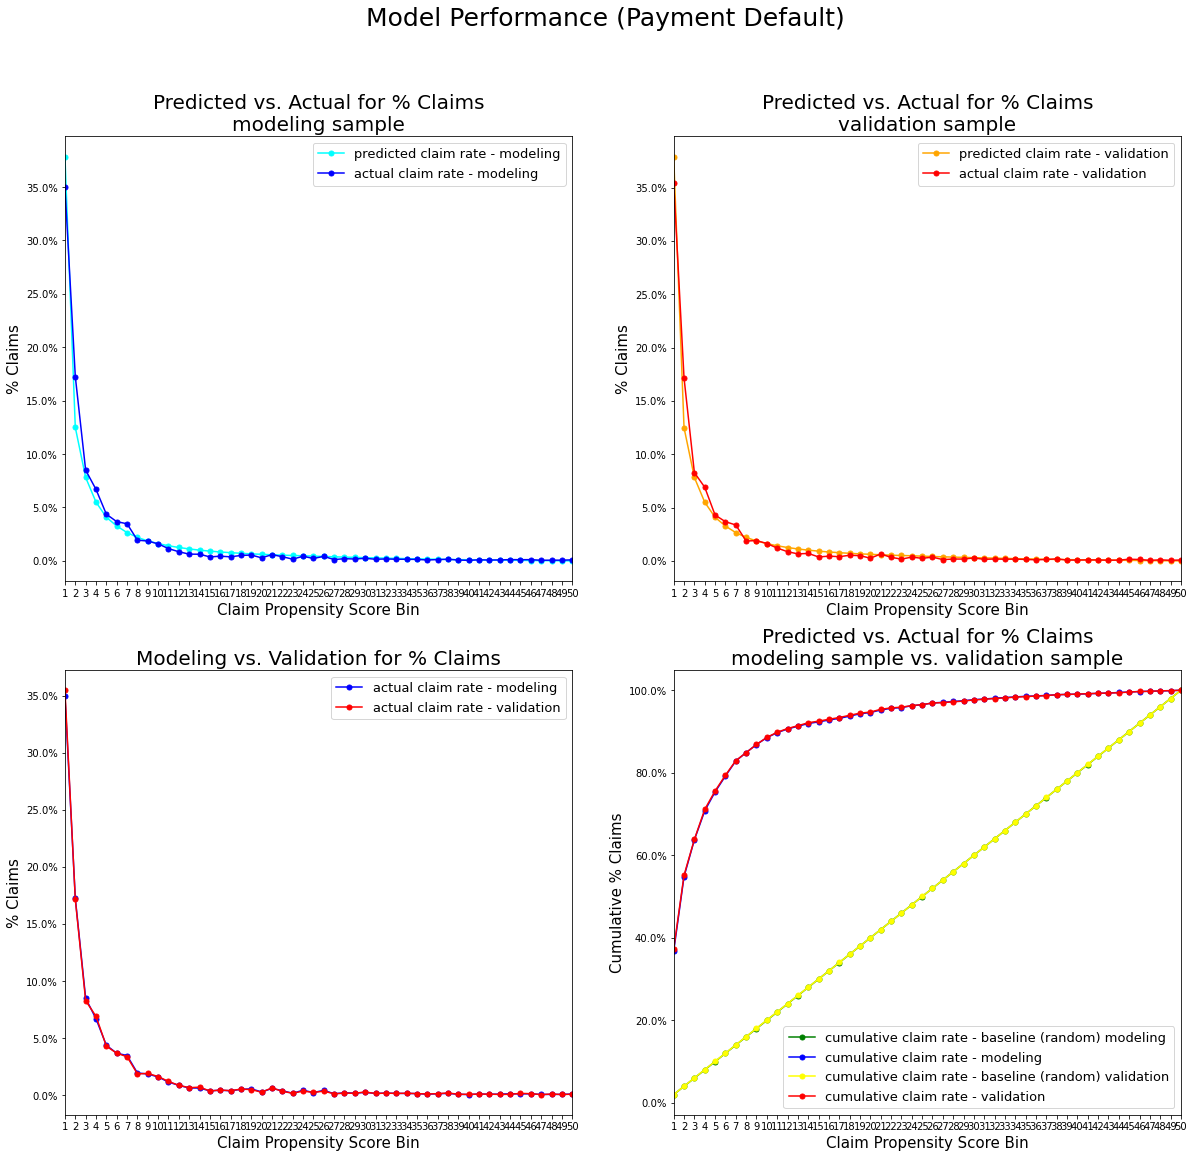

In [85]:
# python array ends at 10=11-1
ticks=np.arange(1, 51, step=1)

fig, axs=plt.subplots(2, 2, figsize=(20, 18))

titlesize=20
labelsize=15
legendsize=13

fig.suptitle("Model Performance (Payment Default)", fontsize=25)

axs[0,0].set_title('Predicted vs. Actual for % Claims\nmodeling sample', fontsize=titlesize)
axs[0,0].set_xticks(ticks)
axs[0,0].set_xlim(1, 50)
axs[0,0].plot(df_agg['risk_score_cut'], df_agg['predicted_mod'], color='cyan', marker='.', markersize=10, label='predicted claim rate - modeling')
axs[0,0].plot(df_agg['risk_score_cut'], df_agg['actual_claim_mod'], color='blue', marker='.', markersize=10, label='actual claim rate - modeling')
axs[0,0].set_xlabel('Claim Propensity Score Bin', fontsize=labelsize)
axs[0,0].set_ylabel('% Claims', fontsize=labelsize)
vals = axs[0,0].get_yticks()
axs[0,0].set_yticklabels(['{:,.1%}'.format(x) for x in vals])
axs[0,0].legend(loc='upper right', fontsize=legendsize)

axs[0,1].set_title('Predicted vs. Actual for % Claims\nvalidation sample', fontsize=titlesize)
axs[0,1].set_xticks(ticks)
axs[0,1].set_xlim(1, 50)
axs[0,1].plot(df_agg['risk_score_cut'], df_agg['predicted_val'], color='orange', marker='.', markersize=10, label='predicted claim rate - validation')
axs[0,1].plot(df_agg['risk_score_cut'], df_agg['actual_claim_val'], color='red', marker='.', markersize=10, label='actual claim rate - validation')
axs[0,1].set_xlabel('Claim Propensity Score Bin', fontsize=labelsize)
axs[0,1].set_ylabel('% Claims', fontsize=labelsize)
vals = axs[0,0].get_yticks()  # need to keep the same scale as the modeling sample
axs[0,1].set_yticklabels(['{:,.1%}'.format(x) for x in vals])
axs[0,1].legend(loc='upper right', fontsize=legendsize)

axs[1,0].set_title('Modeling vs. Validation for % Claims', fontsize=titlesize)
axs[1,0].set_xticks(ticks)
axs[1,0].set_xlim(1, 50)
axs[1,0].plot(df_agg['risk_score_cut'], df_agg['actual_claim_mod'], color='blue', marker='.', markersize=10, label='actual claim rate - modeling')
axs[1,0].plot(df_agg['risk_score_cut'], df_agg['actual_claim_val'], color='red', marker='.', markersize=10, label='actual claim rate - validation')
axs[1,0].set_xlabel('Claim Propensity Score Bin', fontsize=labelsize)
axs[1,0].set_ylabel('% Claims', fontsize=labelsize)
vals = axs[1,0].get_yticks()
axs[1,0].set_yticklabels(['{:,.1%}'.format(x) for x in vals])
axs[1,0].legend(loc='upper right', fontsize=legendsize)

axs[1,1].set_title('Predicted vs. Actual for % Claims\nmodeling sample vs. validation sample', fontsize=titlesize)
axs[1,1].set_xticks(ticks)
axs[1,1].set_xlim(1, 50)
axs[1,1].plot(df_agg['risk_score_cut'], df_agg['cumu_pct_all_mod'], color='green', marker='.', markersize=10, label='cumulative claim rate - baseline (random) modeling')
axs[1,1].plot(df_agg['risk_score_cut'], df_agg['cumu_pct_claim_mod'], color='blue', marker='.', markersize=10, label='cumulative claim rate - modeling')
axs[1,1].plot(df_agg['risk_score_cut'], df_agg['cumu_pct_all_val'], color='yellow', marker='.', markersize=10, label='cumulative claim rate - baseline (random) validation')
axs[1,1].plot(df_agg['risk_score_cut'], df_agg['cumu_pct_claim_val'], color='red', marker='.', markersize=10, label='cumulative claim rate - validation')
axs[1,1].set_xlabel('Claim Propensity Score Bin', fontsize=labelsize)
axs[1,1].set_ylabel('Cumulative % Claims', fontsize=labelsize)
vals = axs[1,1].get_yticks()
axs[1,1].set_yticklabels(['{:,.1%}'.format(x) for x in vals])
axs[1,1].legend(loc='lower right', fontsize=legendsize)

In [86]:
# get the coefficient estimate from the regression
clm_chrg_amt_log_coeff=1.1154
prov_spcl_EMERGENCY_MEDICINE_coeff=1.7845
par_npar_coeff=-1.6063
rvnu_other_coeff=-4.5615
proc_cpt1_surgery_coeff=0.6006
prov_spcl_PEDIATRICIAN_coeff=-1.4561
prdct_PPO_coeff=-1.7482
proc_cpt1_evaluation_mgmt_serv_coeff=0.5538
prov_spcl_SOCIAL_WORKER_coeff=-0.7094
pos_outpatient_hospital_coeff=-0.2464
prov_spcl_FAMILY_PRACTICE_coeff=-0.0882
proc_cpt1_medicine_coeff=0.1292
prov_spcl_RADIOLOGIST_coeff=-0.9969
prov_spcl_RN__SPECIAL_SERVICE_coeff=-0.4443
diag_1_injury_poisoning_coeff=-0.1959
proc_cpt1_radiology_coeff=0.6886
prdct_IND_coeff=-3.3537
prov_spcl_ORTHOPEDIST_coeff=0.3756
prov_spcl_PHYSICAL_OCCUPATIONAL_THERAPY_coeff=-0.3639
diag_1_mental_behavioral_coeff=-0.0852
prov_spcl_PATHOLOGIST_coeff=-0.5868
prov_spcl_AFTER_HOURS_CLINIC_URGENT_CARE_coeff=-1.3347
pos_inpatient_hospital_coeff=-0.2122
proc_cpt2_diagnostic_screening_coeff=-0.6858
prov_spcl_ANESTHESIOLOGIST_coeff=-0.58
diag_2_health_factor_coeff=-0.1788
pos_independent_lab_coeff=0.8235
rvnu_0240_coeff=-2.8622
prdct_PS1_coeff=-0.0266
prdct_MIN_coeff=-3.1365
diag_2_injury_poisoning_coeff=0.2078
diag_2_abnormal_finding_coeff=0.1788
prov_spcl_HOSPITALIST_coeff=1.2432
proc_cpt1_pathology_lab_coeff=-0.4952
proc_cpt2_patient_history_coeff=-0.2288
prov_spcl_REHABILITATION_MEDICINE_coeff=0.8533
prov_spcl_OPTOMETRIST_coeff=-1.7467


def contribution(x):
    
    x['clm_chrg_amt_log_contribution']=x['clm_chrg_amt_log']*clm_chrg_amt_log_coeff
    x['prov_spcl_EMERGENCY_MEDICINE_contribution']=x['prov_spcl_EMERGENCY_MEDICINE']*prov_spcl_EMERGENCY_MEDICINE_coeff
    x['par_npar_contribution']=x['par_npar']*par_npar_coeff
    x['rvnu_other_contribution']=x['rvnu_other']*rvnu_other_coeff
    x['proc_cpt1_surgery_contribution']=x['proc_cpt1_surgery']*proc_cpt1_surgery_coeff
    x['prov_spcl_PEDIATRICIAN_contribution']=x['prov_spcl_PEDIATRICIAN']*prov_spcl_PEDIATRICIAN_coeff
    x['prdct_PPO_contribution']=x['prdct_PPO']*prdct_PPO_coeff
    x['proc_cpt1_evaluation_mgmt_serv_contribution']=x['proc_cpt1_evaluation_mgmt_serv']*proc_cpt1_evaluation_mgmt_serv_coeff
    x['prov_spcl_SOCIAL_WORKER_contribution']=x['prov_spcl_SOCIAL_WORKER']*prov_spcl_SOCIAL_WORKER_coeff
    x['pos_outpatient_hospital_contribution']=x['pos_outpatient_hospital']*pos_outpatient_hospital_coeff
    x['prov_spcl_FAMILY_PRACTICE_contribution']=x['prov_spcl_FAMILY_PRACTICE']*prov_spcl_FAMILY_PRACTICE_coeff
    x['proc_cpt1_medicine_contribution']=x['proc_cpt1_medicine']*proc_cpt1_medicine_coeff
    x['prov_spcl_RADIOLOGIST_contribution']=x['prov_spcl_RADIOLOGIST']*prov_spcl_RADIOLOGIST_coeff
    x['prov_spcl_RN__SPECIAL_SERVICE_contribution']=x['prov_spcl_RN__SPECIAL_SERVICE']*prov_spcl_RN__SPECIAL_SERVICE_coeff
    x['diag_1_injury_poisoning_contribution']=x['diag_1_injury_poisoning']*diag_1_injury_poisoning_coeff
    x['proc_cpt1_radiology_contribution']=x['proc_cpt1_radiology']*proc_cpt1_radiology_coeff
    x['prdct_IND_contribution']=x['prdct_IND']*prdct_IND_coeff
    x['prov_spcl_ORTHOPEDIST_contribution']=x['prov_spcl_ORTHOPEDIST']*prov_spcl_ORTHOPEDIST_coeff
    x['prov_spcl_PHYSICAL_OCCUPATIONAL_THERAPY_contribution']=x['prov_spcl_PHYSICAL_OCCUPATIONAL_THERAPY']*prov_spcl_PHYSICAL_OCCUPATIONAL_THERAPY_coeff
    x['diag_1_mental_behavioral_contribution']=x['diag_1_mental_behavioral']*diag_1_mental_behavioral_coeff
    x['prov_spcl_PATHOLOGIST_contribution']=x['prov_spcl_PATHOLOGIST']*prov_spcl_PATHOLOGIST_coeff
    x['prov_spcl_AFTER_HOURS_CLINIC_URGENT_CARE_contribution']=x['prov_spcl_AFTER_HOURS_CLINIC_URGENT_CARE']*prov_spcl_AFTER_HOURS_CLINIC_URGENT_CARE_coeff
    x['pos_inpatient_hospital_contribution']=x['pos_inpatient_hospital']*pos_inpatient_hospital_coeff
    x['proc_cpt2_diagnostic_screening_contribution']=x['proc_cpt2_diagnostic_screening']*proc_cpt2_diagnostic_screening_coeff
    x['prov_spcl_ANESTHESIOLOGIST_contribution']=x['prov_spcl_ANESTHESIOLOGIST']*prov_spcl_ANESTHESIOLOGIST_coeff
    x['diag_2_health_factor_contribution']=x['diag_2_health_factor']*diag_2_health_factor_coeff
    x['pos_independent_lab_contribution']=x['pos_independent_lab']*pos_independent_lab_coeff
    x['rvnu_0240_contribution']=x['rvnu_0240']*rvnu_0240_coeff
    x['prdct_PS1_contribution']=x['prdct_PS1']*prdct_PS1_coeff
    x['prdct_MIN_contribution']=x['prdct_MIN']*prdct_MIN_coeff
    x['diag_2_injury_poisoning_contribution']=x['diag_2_injury_poisoning']*diag_2_injury_poisoning_coeff
    x['diag_2_abnormal_finding_contribution']=x['diag_2_abnormal_finding']*diag_2_abnormal_finding_coeff
    x['prov_spcl_HOSPITALIST_contribution']=x['prov_spcl_HOSPITALIST']*prov_spcl_HOSPITALIST_coeff
    x['proc_cpt1_pathology_lab_contribution']=x['proc_cpt1_pathology_lab']*proc_cpt1_pathology_lab_coeff
    x['proc_cpt2_patient_history_contribution']=x['proc_cpt2_patient_history']*proc_cpt2_patient_history_coeff
    x['prov_spcl_REHABILITATION_MEDICINE_contribution']=x['prov_spcl_REHABILITATION_MEDICINE']*prov_spcl_REHABILITATION_MEDICINE_coeff
    x['prov_spcl_OPTOMETRIST_contribution']=x['prov_spcl_OPTOMETRIST']*prov_spcl_OPTOMETRIST_coeff


    
contribution(df_val)

C:\Users\aleci\AppData\Local\Temp/ipykernel_18988/1659683780.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x['clm_chrg_amt_log_contribution']=x['clm_chrg_amt_log']*clm_chrg_amt_log_coeff
C:\Users\aleci\AppData\Local\Temp/ipykernel_18988/1659683780.py:44: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x['prov_spcl_EMERGENCY_MEDICINE_contribution']=x['prov_spcl_EMERGENCY_MEDICINE']*prov_spcl_EMERGENCY_MEDICINE_coeff
C:\Users\aleci\AppData\Local\Temp/ipykernel_18988/1659683780.py:45: SettingWithCopyWarni

C:\Users\aleci\AppData\Local\Temp/ipykernel_18988/1659683780.py:65: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x['pos_inpatient_hospital_contribution']=x['pos_inpatient_hospital']*pos_inpatient_hospital_coeff
C:\Users\aleci\AppData\Local\Temp/ipykernel_18988/1659683780.py:66: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x['proc_cpt2_diagnostic_screening_contribution']=x['proc_cpt2_diagnostic_screening']*proc_cpt2_diagnostic_screening_coeff
C:\Users\aleci\AppData\Local\Temp/ipykernel_18988/1659683780.py:

In [87]:
# rank order contributing factor from highest to lowest for all input variables
# select the top 3 contributors
x=df_val[(df_val['risk_score_cut']==1) & (df_val['target']==1)][['clm_chrg_amt_log',
'prov_spcl_EMERGENCY_MEDICINE',
'par_npar',
'rvnu_other',
'proc_cpt1_surgery',
'prov_spcl_PEDIATRICIAN',
'prdct_PPO',
'proc_cpt1_evaluation_mgmt_serv',
'prov_spcl_SOCIAL_WORKER',
'pos_outpatient_hospital',
'prov_spcl_FAMILY_PRACTICE',
'proc_cpt1_medicine',
'prov_spcl_RADIOLOGIST',
'prov_spcl_RN__SPECIAL_SERVICE',
'diag_1_injury_poisoning',
'proc_cpt1_radiology',
'prdct_IND',
'prov_spcl_ORTHOPEDIST',
'prov_spcl_PHYSICAL_OCCUPATIONAL_THERAPY',
'diag_1_mental_behavioral',
'prov_spcl_PATHOLOGIST',
'prov_spcl_AFTER_HOURS_CLINIC_URGENT_CARE',
'pos_inpatient_hospital',
'proc_cpt2_diagnostic_screening',
'prov_spcl_ANESTHESIOLOGIST',
'diag_2_health_factor',
'pos_independent_lab',
'rvnu_0240',
'prdct_PS1',
'prdct_MIN',
'diag_2_injury_poisoning',
'diag_2_abnormal_finding',
'prov_spcl_HOSPITALIST',
'proc_cpt1_pathology_lab',
'proc_cpt2_patient_history',
'prov_spcl_REHABILITATION_MEDICINE',
'prov_spcl_OPTOMETRIST',
          'seq'
]].set_index('seq')

nlargest=7
order=np.argsort(-x.values, axis=1)[:, :nlargest]

df_top_drivers=pd.DataFrame(x.columns[order],
                            columns=['driver{}'.format(i) for i in range(1, nlargest+1)],
                            index=x.index)

print(df_top_drivers.head())

               driver1                  driver2                   driver3  \
seq                                                                         
4650  clm_chrg_amt_log     diag_2_health_factor        proc_cpt1_medicine   
4670  clm_chrg_amt_log                prdct_PS1  diag_1_mental_behavioral   
5420  clm_chrg_amt_log  diag_1_injury_poisoning                 prdct_PS1   
7850  clm_chrg_amt_log                prdct_PS1       pos_independent_lab   
8440  clm_chrg_amt_log       proc_cpt1_medicine                 prdct_PS1   

                             driver4  \
seq                                    
4650                       prdct_PS1   
4670           prov_spcl_PATHOLOGIST   
5420         diag_2_injury_poisoning   
7850           prov_spcl_PATHOLOGIST   
8440  proc_cpt1_evaluation_mgmt_serv   

                                       driver5                       driver6  \
seq                                                                            
4650               

C:\Users\aleci\AppData\Local\Temp/ipykernel_18988/2545498582.py:46: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  df_top_drivers=pd.DataFrame(x.columns[order],


In [88]:
df_top_drivers.to_csv(docupath+'df_top_drivers.csv')

In [89]:
df_top_drivers.head()

,driver1,driver2,driver3,driver4,driver5,driver6,driver7
seq,,,,,,,
4650,clm_chrg_amt_log,diag_2_health_factor,proc_cpt1_medicine,prdct_PS1,pos_outpatient_hospital,diag_2_injury_poisoning,prdct_MIN
4670,clm_chrg_amt_log,prdct_PS1,diag_1_mental_behavioral,prov_spcl_PATHOLOGIST,prov_spcl_AFTER_HOURS_CLINIC_URGENT_CARE,pos_inpatient_hospital,proc_cpt2_diagnostic_screening
5420,clm_chrg_amt_log,diag_1_injury_poisoning,prdct_PS1,diag_2_injury_poisoning,pos_outpatient_hospital,par_npar,prov_spcl_EMERGENCY_MEDICINE
7850,clm_chrg_amt_log,prdct_PS1,pos_independent_lab,prov_spcl_PATHOLOGIST,prov_spcl_AFTER_HOURS_CLINIC_URGENT_CARE,pos_inpatient_hospital,proc_cpt2_diagnostic_screening
8440,clm_chrg_amt_log,proc_cpt1_medicine,prdct_PS1,proc_cpt1_evaluation_mgmt_serv,pos_outpatient_hospital,prov_spcl_EMERGENCY_MEDICINE,diag_2_abnormal_finding


In [90]:
def top_driver(drivername, freq):
    for_bar=df_top_drivers.groupby(drivername).size().reset_index()
    for_bar.columns=[drivername, 'count']
    for_bar.sort_values(by='count', ascending=False, inplace=True)
    for_bar.insert(0, 'seq', range(1, 1+len(for_bar)))    
    for_bar[freq]=for_bar['count']/(for_bar['count'].sum())
    for_bar.drop('count', axis=1, inplace=True)
    return for_bar

driver1=top_driver('driver1', '% Records - Driver 1')
driver1

,seq,driver1,% Records - Driver 1
0,1,clm_chrg_amt_log,1.0


In [91]:
driver2=top_driver('driver2', '% Records - Driver 2')
driver2

,seq,driver2,% Records - Driver 2
10,1,prdct_PS1,0.271185
11,2,proc_cpt1_medicine,0.167560
5,3,par_npar,0.094023
7,4,pos_inpatient_hospital,0.067856
0,5,diag_1_injury_poisoning,0.052893
13,6,proc_cpt1_radiology,0.045771
3,7,diag_2_health_factor,0.045771
6,8,pos_independent_lab,0.037929
21,9,prov_spcl_ORTHOPEDIST,0.034568
12,10,proc_cpt1_pathology_lab,0.032568


In [92]:
driver3=top_driver('driver3', '% Records - Driver 3')
driver4=top_driver('driver4', '% Records - Driver 4')
driver5=top_driver('driver5', '% Records - Driver 5')
driver6=top_driver('driver6', '% Records - Driver 6')
driver7=top_driver('driver7', '% Records - Driver 7')

list_drivers=[driver1, driver2, driver3, driver4, driver5, driver6]


all_drivers=reduce(lambda left,right: pd.merge(left,right,on='seq', how='outer'), list_drivers)
all_drivers

,seq,driver1,% Records - Driver 1,driver2,% Records - Driver 2,driver3,% Records - Driver 3,driver4,% Records - Driver 4,driver5,% Records - Driver 5,driver6,% Records - Driver 6
0,1,clm_chrg_amt_log,1.0,prdct_PS1,0.271185,prdct_PS1,0.255901,proc_cpt1_evaluation_mgmt_serv,0.188845,proc_cpt1_pathology_lab,0.148916,prov_spcl_HOSPITALIST,0.251340
1,2,NaN,NaN,proc_cpt1_medicine,0.167560,proc_cpt1_medicine,0.136513,prdct_PS1,0.128191,pos_outpatient_hospital,0.146115,pos_inpatient_hospital,0.116988
2,3,NaN,NaN,par_npar,0.094023,pos_outpatient_hospital,0.129711,prov_spcl_EMERGENCY_MEDICINE,0.126670,par_npar,0.118508,par_npar,0.097944
3,4,NaN,NaN,pos_inpatient_hospital,0.067856,proc_cpt1_surgery,0.085861,pos_outpatient_hospital,0.126510,prov_spcl_AFTER_HOURS_CLINIC_URGENT_CARE,0.115388,prov_spcl_EMERGENCY_MEDICINE,0.097383
4,5,NaN,NaN,diag_1_injury_poisoning,0.052893,proc_cpt1_evaluation_mgmt_serv,0.062975,prov_spcl_AFTER_HOURS_CLINIC_URGENT_CARE,0.068496,pos_inpatient_hospital,0.071777,pos_outpatient_hospital,0.087221
5,6,NaN,NaN,proc_cpt1_radiology,0.045771,diag_2_abnormal_finding,0.059054,proc_cpt1_surgery,0.057694,prov_spcl_EMERGENCY_MEDICINE,0.068977,proc_cpt2_diagnostic_screening,0.085380
6,7,NaN,NaN,diag_2_health_factor,0.045771,pos_independent_lab,0.036889,par_npar,0.043450,diag_2_abnormal_finding,0.064656,prov_spcl_AFTER_HOURS_CLINIC_URGENT_CARE,0.051372
7,8,NaN,NaN,pos_independent_lab,0.037929,par_npar,0.033688,prov_spcl_PATHOLOGIST,0.041770,prdct_PS1,0.061695,proc_cpt2_patient_history,0.041450
8,9,NaN,NaN,prov_spcl_ORTHOPEDIST,0.034568,prov_spcl_EMERGENCY_MEDICINE,0.028167,diag_2_abnormal_finding,0.030807,proc_cpt1_evaluation_mgmt_serv,0.056894,diag_2_abnormal_finding,0.034728
9,10,NaN,NaN,proc_cpt1_pathology_lab,0.032568,prov_spcl_PATHOLOGIST,0.027927,pos_independent_lab,0.029607,prov_spcl_PATHOLOGIST,0.032728,diag_2_injury_poisoning,0.026966


In [93]:
# get the weight of variables for all drivers.
# assign weight according to their contribution

all_drivers=pd.concat([driver1.rename(columns={'driver1': 'driver_name', '% Records - Driver 1':'driver_pct'}).assign(weight=6), 
                       driver2.rename(columns={'driver2': 'driver_name', '% Records - Driver 2':'driver_pct'}).assign(weight=5),
                       driver3.rename(columns={'driver3': 'driver_name', '% Records - Driver 3':'driver_pct'}).assign(weight=4),
                       driver4.rename(columns={'driver4': 'driver_name', '% Records - Driver 4':'driver_pct'}).assign(weight=3),
                       driver5.rename(columns={'driver5': 'driver_name', '% Records - Driver 5':'driver_pct'}).assign(weight=2),
                       driver6.rename(columns={'driver3': 'driver_name', '% Records - Driver 6':'driver_pct'}).assign(weight=1)])

all_drivers['total_contribution']=all_drivers['driver_pct']*all_drivers['weight']
all_drivers_sum=all_drivers.groupby('driver_name')['total_contribution'].sum().reset_index()
all_drivers_sum.sort_values(by='total_contribution', ascending=False, inplace=True)
all_drivers_sum.to_csv(docupath+'regression_contribution.csv')

In [116]:
#### Reverse engineering
wholefile['rule_1']=np.where((wholefile['clm_chrg_amt'] >= 950) & (wholefile['prov_spcl_EMERGENCY_MEDICINE']==1) & (wholefile['par_npar']==0) & (wholefile['rvnu_other']==0) & (wholefile['prdct_PS1']==1) & (wholefile['proc_cpt1_medicine']==1) & (wholefile['pos_outpatient_hospital']==1) & (wholefile['pos_inpatient_hospital']==0), 1, 0)
wholefile.groupby(['seg', 'rule_1'])['target'].agg(['count', 'mean'])


count      mean
seg rule_1                   
mod 0       3494007  0.018466
    1          3226  0.661500
val 0       1747045  0.018597
    1          1655  0.643505

In [110]:
wholefile['rule_1']=np.where((wholefile['clm_chrg_amt'] > 950) & (wholefile['prov_spcl_EMERGENCY_MEDICINE']==1) & (wholefile['par_npar']==0) & (wholefile['rvnu_other']==0) & (wholefile['prdct_PS1']==1) & (wholefile['proc_cpt1_medicine']==1) & (wholefile['pos_outpatient_hospital']==1), 1, 0)
wholefile.groupby(['seg', 'rule_1'])['target'].agg(['count', 'mean'])


count      mean
seg rule_1                   
mod 0       3494009  0.018466
    1          3224  0.661290
val 0       1747047  0.018597
    1          1653  0.643678

In [101]:
wholefile['rule_1']=np.where((wholefile['clm_chrg_amt'] > 950) & (wholefile['prov_spcl_EMERGENCY_MEDICINE']==1) & (wholefile['par_npar']==0), 1, 0)
wholefile.groupby(['seg', 'rule_1'])['target'].agg(['count', 'mean'])


count      mean
seg rule_1                   
mod 0       3482735  0.017135
    1         14498  0.481239
val 0       1741418  0.017232
    1          7282  0.486954

# Step 7 - Marketing Basket Analysis

In [67]:
#!pip install mlxtend

In [117]:
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

list_dummy=[
#'clm_ded_amt_tr',
#'clm_not_cov_amt_tr',
#'clm_pd_amt_tr',
'prov_spcl_EMERGENCY_MEDICINE',
'par_npar',
'pos_office',
'proc_cpt1_surgery',
'prov_spcl_PEDIATRICIAN',
'prdct_PPO',
'proc_cpt1_evaluation_mgmt_serv',
'pos_outpatient_hospital',
'prov_spcl_FAMILY_PRACTICE',
'proc_cpt1_medicine',
'diag_1_injury_poisoning',
'proc_cpt1_radiology',
'prdct_IND',
'prov_spcl_PHYSICAL_OCCUPATIONAL_THERAPY',
'diag_1_mental_behavioral',
'prov_spcl_PATHOLOGIST',
'prov_spcl_AFTER_HOURS_CLINIC_URGENT_CARE',
'pos_inpatient_hospital',
'proc_cpt2_diagnostic_screening',
'prov_spcl_ANESTHESIOLOGIST',
'prov_spcl_INTERNIST',
'pos_independent_lab',
'rvnu_0240',
'prdct_MIN',
'diag_2_injury_poisoning',
'diag_2_abnormal_finding',
'prov_spcl_HOSPITALIST',
'proc_cpt1_pathology_lab',
'proc_cpt2_patient_history'
 ]

df_mod[list_dummy].describe()

C:\Users\aleci\anaconda3\lib\site-packages\pandas\core\nanops.py:1723: DeprecationWarning: the `interpolation=` argument to percentile was renamed to `method=`, which has additional options.
Users of the modes 'nearest', 'lower', 'higher', or 'midpoint' are encouraged to review the method they used. (Deprecated NumPy 1.22)
  return np.percentile(values, q, axis=1, interpolation=interpolation)
C:\Users\aleci\anaconda3\lib\site-packages\pandas\core\nanops.py:1723: DeprecationWarning: the `interpolation=` argument to percentile was renamed to `method=`, which has additional options.
Users of the modes 'nearest', 'lower', 'higher', or 'midpoint' are encouraged to review the method they used. (Deprecated NumPy 1.22)
  return np.percentile(values, q, axis=1, interpolation=interpolation)
C:\Users\aleci\anaconda3\lib\site-packages\pandas\core\nanops.py:1723: DeprecationWarning: the `interpolation=` argument to percentile was renamed to `method=`, which has additional options.
Users of the mode

C:\Users\aleci\anaconda3\lib\site-packages\pandas\core\nanops.py:1723: DeprecationWarning: the `interpolation=` argument to percentile was renamed to `method=`, which has additional options.
Users of the modes 'nearest', 'lower', 'higher', or 'midpoint' are encouraged to review the method they used. (Deprecated NumPy 1.22)
  return np.percentile(values, q, axis=1, interpolation=interpolation)
C:\Users\aleci\anaconda3\lib\site-packages\pandas\core\nanops.py:1723: DeprecationWarning: the `interpolation=` argument to percentile was renamed to `method=`, which has additional options.
Users of the modes 'nearest', 'lower', 'higher', or 'midpoint' are encouraged to review the method they used. (Deprecated NumPy 1.22)
  return np.percentile(values, q, axis=1, interpolation=interpolation)
C:\Users\aleci\anaconda3\lib\site-packages\pandas\core\nanops.py:1723: DeprecationWarning: the `interpolation=` argument to percentile was renamed to `method=`, which has additional options.
Users of the mode

,prov_spcl_EMERGENCY_MEDICINE,par_npar,pos_office,proc_cpt1_surgery,prov_spcl_PEDIATRICIAN,prdct_PPO,proc_cpt1_evaluation_mgmt_serv,pos_outpatient_hospital,prov_spcl_FAMILY_PRACTICE,proc_cpt1_medicine,...,prov_spcl_ANESTHESIOLOGIST,prov_spcl_INTERNIST,pos_independent_lab,rvnu_0240,prdct_MIN,diag_2_injury_poisoning,diag_2_abnormal_finding,prov_spcl_HOSPITALIST,proc_cpt1_pathology_lab,proc_cpt2_patient_history
count,3.497233e+06,3.497233e+06,3.497233e+06,3.497233e+06,3.497233e+06,3.497233e+06,3.497233e+06,3.497233e+06,3.497233e+06,3.497233e+06,...,3.497233e+06,3.497233e+06,3.497233e+06,3.497233e+06,3.497233e+06,3.497233e+06,3.497233e+06,3.497233e+06,3.497233e+06,3.497233e+06
mean,2.359008e-02,8.940946e-01,5.505032e-01,6.075203e-02,4.251961e-02,9.594986e-02,1.120878e-01,1.930806e-01,7.562808e-02,2.141236e-01,...,1.608643e-02,4.836109e-02,1.276726e-01,8.362039e-03,5.784001e-03,1.574130e-02,8.253182e-02,5.728243e-03,1.128810e-01,1.260339e-02
std,1.517682e-01,3.077166e-01,4.974430e-01,2.388749e-01,2.017714e-01,2.945225e-01,3.154744e-01,3.947158e-01,2.644021e-01,4.102130e-01,...,1.258080e-01,2.145281e-01,3.337250e-01,9.106107e-02,7.583237e-02,1.244730e-01,2.751733e-01,7.546808e-02,3.164473e-01,1.115551e-01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,...,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00


In [120]:
df_mod.columns.tolist()

['seq',
 'sub_clm_aud_nbr',
 'clm_chrg_amt',
 'clm_ded_amt',
 'clm_coin_amt',
 'clm_copay_amt',
 'clm_alw_amt',
 'clm_not_cov_amt',
 'clm_pd_amt',
 'par_npar',
 'tin_prfx_2',
 'tin_prfx_1',
 'tin_prfx_0',
 'tin_prfx_8',
 'tin_prfx_7',
 'tin_prfx_9',
 'tin_prfx_4',
 'pos_pharmacy',
 'pos_office',
 'pos_home',
 'pos_patient_employ_loc',
 'pos_inpatient_hospital',
 'pos_outpatient_hospital',
 'pos_ER_room',
 'pos_ambu_surgical_center',
 'pos_birthing_center',
 'pos_skilled_nursing_faci',
 'pos_hospice',
 'pos_ambu_land',
 'pos_substance_treatment',
 'pos_independent_lab',
 'pos_other_unlisted_faci',
 'diag_1_infectious_parasitic',
 'diag_1_neoplasms',
 'diag_1_blood_immune',
 'diag_1_endotrine_nutri_metab',
 'diag_1_mental_behavioral',
 'diag_1_nervous_system',
 'diag_1_eye_adnexa',
 'diag_1_ear_mastoid',
 'diag_1_circulatory',
 'diag_1_respiratory',
 'diag_1_digestive',
 'diag_1_skin_subcutaneous',
 'diag_1_musculoskeletal',
 'diag_1_genitourinary',
 'diag_1_pregnancy_childbirth',
 'diag

In [121]:
df_mod_yes=df_mod[(df_mod['target']==1) & (df_mod['risk_score_cut']==1)]

frequent_itemsets = apriori(df_mod_yes[df_mod_yes['seq']%10 < 5][list_dummy], min_support=0.01, use_colnames=True)

rules = association_rules(frequent_itemsets, metric="lift")

rules.head(20)

C:\Users\aleci\anaconda3\lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:110: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric
0,(proc_cpt1_evaluation_mgmt_serv),(prov_spcl_EMERGENCY_MEDICINE),0.324034,0.470305,0.226125,0.697844,1.483813,0.073731,1.753055,0.482363
1,(prov_spcl_EMERGENCY_MEDICINE),(proc_cpt1_evaluation_mgmt_serv),0.470305,0.324034,0.226125,0.480806,1.483813,0.073731,1.301953,0.615563
2,(prov_spcl_EMERGENCY_MEDICINE),(pos_outpatient_hospital),0.470305,0.531166,0.450780,0.958485,1.804494,0.200970,11.293217,0.841669
3,(pos_outpatient_hospital),(prov_spcl_EMERGENCY_MEDICINE),0.531166,0.470305,0.450780,0.848662,1.804494,0.200970,3.500080,0.950929
4,(prov_spcl_EMERGENCY_MEDICINE),(proc_cpt1_medicine),0.470305,0.390001,0.233723,0.496960,1.274254,0.050304,1.212626,0.406323
5,(proc_cpt1_medicine),(prov_spcl_EMERGENCY_MEDICINE),0.390001,0.470305,0.233723,0.599288,1.274254,0.050304,1.321885,0.352832
6,(diag_1_injury_poisoning),(prov_spcl_EMERGENCY_MEDICINE),0.092272,0.470305,0.057512,0.623285,1.325278,0.014116,1.406089,0.270391
7,(prov_spcl_EMERGENCY_MEDICINE),(diag_1_injury_poisoning),0.470305,0.092272,0.057512,0.122286,1.325278,0.014116,1.034196,0.463364
8,(prov_spcl_EMERGENCY_MEDICINE),(diag_2_injury_poisoning),0.470305,0.047627,0.025202,0.053587,1.125142,0.002803,1.006298,0.209976
9,(diag_2_injury_poisoning),(prov_spcl_EMERGENCY_MEDICINE),0.047627,0.470305,0.025202,0.529160,1.125142,0.002803,1.124999,0.116785


In [76]:
rules.head(20)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric
0,(prov_spcl_EMERGENCY_MEDICINE),(par_npar),0.234780,0.585051,0.118312,0.503930,0.861343,-0.019046,0.836472,-0.173804
1,(par_npar),(prov_spcl_EMERGENCY_MEDICINE),0.585051,0.234780,0.118312,0.202226,0.861343,-0.019046,0.959194,-0.279510
2,(proc_cpt1_evaluation_mgmt_serv),(prov_spcl_EMERGENCY_MEDICINE),0.212665,0.234780,0.095643,0.449735,1.915564,0.045714,1.390641,0.607062
3,(prov_spcl_EMERGENCY_MEDICINE),(proc_cpt1_evaluation_mgmt_serv),0.234780,0.212665,0.095643,0.407374,1.915564,0.045714,1.328553,0.624605
4,(pos_outpatient_hospital),(prov_spcl_EMERGENCY_MEDICINE),0.293411,0.234780,0.211840,0.721992,3.075191,0.142953,2.752513,0.955034
5,(prov_spcl_EMERGENCY_MEDICINE),(pos_outpatient_hospital),0.234780,0.293411,0.211840,0.902294,3.075191,0.142953,7.231795,0.881860
6,(prov_spcl_EMERGENCY_MEDICINE),(proc_cpt1_medicine),0.234780,0.301047,0.100039,0.426098,1.415384,0.029359,1.217895,0.383521
7,(proc_cpt1_medicine),(prov_spcl_EMERGENCY_MEDICINE),0.301047,0.234780,0.100039,0.332303,1.415384,0.029359,1.146060,0.419883
8,(diag_1_injury_poisoning),(prov_spcl_EMERGENCY_MEDICINE),0.061422,0.234780,0.027605,0.449438,1.914298,0.013185,1.389890,0.508871
9,(prov_spcl_EMERGENCY_MEDICINE),(diag_1_injury_poisoning),0.234780,0.061422,0.027605,0.117579,1.914298,0.013185,1.063641,0.624154


In [70]:
list_dummy=[
'prov_spcl_EMERGENCY_MEDICINE',
'par_npar',
'pos_office',
'proc_cpt1_surgery',
'prov_spcl_PEDIATRICIAN',
'prdct_PPO',
'proc_cpt1_evaluation_mgmt_serv',
'pos_outpatient_hospital',
'prov_spcl_FAMILY_PRACTICE',
'proc_cpt1_medicine',
'diag_1_injury_poisoning',
'proc_cpt1_radiology',
'prdct_IND',
'prov_spcl_PHYSICAL_OCCUPATIONAL_THERAPY',
'diag_1_mental_behavioral',
'prov_spcl_PATHOLOGIST',
'prov_spcl_AFTER_HOURS_CLINIC_URGENT_CARE',
'pos_inpatient_hospital',
'proc_cpt2_diagnostic_screening',
'prov_spcl_ANESTHESIOLOGIST',
'prov_spcl_INTERNIST',
'pos_independent_lab',
'rvnu_0240',
'prdct_MIN',
'diag_2_injury_poisoning',
'diag_2_abnormal_finding',
'prov_spcl_HOSPITALIST',
'proc_cpt1_pathology_lab',
'proc_cpt2_patient_history'
 ]

df_mod[list_dummy].describe()

frequent_itemsets = apriori(df_mod[df_mod['seq']%1000 < 10][list_dummy], min_support=0.001, use_colnames=True)
rules = association_rules(frequent_itemsets, metric="lift")
rules.sort_values(["support", "confidence","lift"],axis = 0, ascending = False, inplace=True)
rules.head(50)

C:\Users\aleci\anaconda3\lib\site-packages\pandas\core\nanops.py:1723: DeprecationWarning: the `interpolation=` argument to percentile was renamed to `method=`, which has additional options.
Users of the modes 'nearest', 'lower', 'higher', or 'midpoint' are encouraged to review the method they used. (Deprecated NumPy 1.22)
  return np.percentile(values, q, axis=1, interpolation=interpolation)
C:\Users\aleci\anaconda3\lib\site-packages\pandas\core\nanops.py:1723: DeprecationWarning: the `interpolation=` argument to percentile was renamed to `method=`, which has additional options.
Users of the modes 'nearest', 'lower', 'higher', or 'midpoint' are encouraged to review the method they used. (Deprecated NumPy 1.22)
  return np.percentile(values, q, axis=1, interpolation=interpolation)
C:\Users\aleci\anaconda3\lib\site-packages\pandas\core\nanops.py:1723: DeprecationWarning: the `interpolation=` argument to percentile was renamed to `method=`, which has additional options.
Users of the mode

C:\Users\aleci\anaconda3\lib\site-packages\pandas\core\nanops.py:1723: DeprecationWarning: the `interpolation=` argument to percentile was renamed to `method=`, which has additional options.
Users of the modes 'nearest', 'lower', 'higher', or 'midpoint' are encouraged to review the method they used. (Deprecated NumPy 1.22)
  return np.percentile(values, q, axis=1, interpolation=interpolation)
C:\Users\aleci\anaconda3\lib\site-packages\pandas\core\nanops.py:1723: DeprecationWarning: the `interpolation=` argument to percentile was renamed to `method=`, which has additional options.
Users of the modes 'nearest', 'lower', 'higher', or 'midpoint' are encouraged to review the method they used. (Deprecated NumPy 1.22)
  return np.percentile(values, q, axis=1, interpolation=interpolation)
C:\Users\aleci\anaconda3\lib\site-packages\pandas\core\nanops.py:1723: DeprecationWarning: the `interpolation=` argument to percentile was renamed to `method=`, which has additional options.
Users of the mode

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric
14,(pos_office),(par_npar),0.551539,0.895607,0.514386,0.932638,1.041348,0.020424,1.549743,0.088539
15,(par_npar),(pos_office),0.895607,0.551539,0.514386,0.574344,1.041348,0.020424,1.053576,0.380353
28,(proc_cpt1_medicine),(par_npar),0.212848,0.895607,0.193428,0.908761,1.014687,0.002800,1.144173,0.018389
29,(par_npar),(proc_cpt1_medicine),0.895607,0.212848,0.193428,0.215974,1.014687,0.002800,1.003987,0.138657
75,(proc_cpt1_medicine),(pos_office),0.212848,0.551539,0.174808,0.821285,1.489079,0.057415,2.509360,0.417256
74,(pos_office),(proc_cpt1_medicine),0.551539,0.212848,0.174808,0.316947,1.489079,0.057415,1.152403,0.732380
25,(pos_outpatient_hospital),(par_npar),0.192255,0.895607,0.168459,0.876227,0.978361,-0.003726,0.843426,-0.026652
24,(par_npar),(pos_outpatient_hospital),0.895607,0.192255,0.168459,0.188095,0.978361,-0.003726,0.994876,-0.174825
436,"(pos_office, proc_cpt1_medicine)",(par_npar),0.174808,0.895607,0.162024,0.926865,1.034902,0.005464,1.427406,0.040869
438,"(proc_cpt1_medicine, par_npar)",(pos_office),0.193428,0.551539,0.162024,0.837646,1.518744,0.055341,2.762244,0.423472


In [238]:
for i in list_dummy: 
    print(df_mod.groupby(['seg', i])['target'].agg(['count', 'mean']))

                                    count      mean
seg prov_spcl_EMERGENCY_MEDICINE                   
mod 0                             3414733  0.014937
    1                               82500  0.189685
                count      mean
seg par_npar                   
mod 0          370376  0.074675
    1         3126857  0.012471
                  count      mean
seg pos_office                   
mod 0           1571995  0.027444
    1           1925238  0.012213
                         count      mean
seg proc_cpt1_surgery                   
mod 0                  3284769  0.017258
    1                   212464  0.046902
                              count      mean
seg prov_spcl_PEDIATRICIAN                   
mod 0                       3348532  0.019784
    1                        148701  0.002724
                 count      mean
seg prdct_PPO                   
mod 0          3161674  0.020366
    1           335559  0.006744
                                      count     

In [71]:
df_mod.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3497233 entries, 0 to 5245932
Columns: 258 entries, seq to risk_score_cut
dtypes: float64(10), int32(6), int64(240), object(2)
memory usage: 6.7+ GB


In [141]:
wholefile['asrule1']=np.where((wholefile['prov_spcl_EMERGENCY_MEDICINE']==1) & (wholefile['par_npar']==0) 
                              & (wholefile['pos_outpatient_hospital']==1) & (wholefile['diag_2_abnormal_finding']==1)
                              & (wholefile['proc_cpt1_evaluation_mgmt_serv']==1) , 1, 0)
wholefile.groupby(['seg', 'asrule1'])['target'].agg(['count', 'mean'])

count      mean
seg asrule1                   
mod 0        3495784  0.018818
    1           1449  0.601794
val 0        1747944  0.018955
    1            756  0.556878

In [149]:
wholefile['asrule2']=np.where((wholefile['prov_spcl_HOSPITALIST']==0) & (wholefile['clm_chrg_amt'] > 900),  1, 0)
wholefile.groupby(['seg', 'asrule2'])['target'].agg(['count', 'mean'])

count      mean
seg asrule2                   
mod 0        3041902  0.008242
    1         455331  0.091325
val 0        1520361  0.008197
    1         228339  0.092367

In [ ]:
prov_spcl_PEDIATRICIAN should be treated separately

In [154]:
wholefile['rule_1']=np.where((wholefile['clm_chrg_amt'] > 950) & (wholefile['prov_spcl_EMERGENCY_MEDICINE']==1) 
                             & (wholefile['par_npar']==0) & (wholefile['proc_cpt1_medicine']==1) , 1, 0)
wholefile.groupby(['seg', 'rule_1'])['target'].agg(['count', 'mean'])

count      mean
seg rule_1                   
mod 0       3492015  0.018252
    1          5218  0.558835
val 0       1746063  0.018384
    1          2637  0.551384

In [150]:
wholefile['rule_2']=np.where((wholefile['prov_spcl_EMERGENCY_MEDICINE']==1) & (wholefile['par_npar']==0) 
                             & (wholefile['pos_outpatient_hospital']==1) & (wholefile['diag_2_abnormal_finding']==1)
                             & (wholefile['proc_cpt1_evaluation_mgmt_serv']==1), 1, 0)
wholefile.groupby(['seg', 'rule_2'])['target'].agg(['count', 'mean'])

count      mean
seg rule_2                   
mod 0       3495784  0.018818
    1          1449  0.601794
val 0       1747944  0.018955
    1           756  0.556878

In [235]:
wholefile['rule_3']=np.where((wholefile['prov_spcl_EMERGENCY_MEDICINE']==1) & (wholefile['par_npar']==0) 
                             & (wholefile['pos_outpatient_hospital']==1) & (wholefile['diag_2_abnormal_finding']==1)
                             & (wholefile['prov_spcl_PEDIATRICIAN']==0), 1, 0)
wholefile.groupby(['seg', 'rule_3'])['target'].agg(['count', 'mean'])

count      mean
seg rule_3                   
mod 0       3492473  0.018515
    1          4760  0.418277
val 0       1746277  0.018653
    1          2423  0.404870

In [240]:
wholefile['all_rules']=np.where(wholefile['rule_1']+wholefile['rule_2']+wholefile['rule_3'] > 0, 1, 0)
wholefile.groupby(['seg', 'all_rules'])['target'].agg(['count', 'mean'])

count      mean
seg all_rules                   
mod 0          3481383  0.017883
    1            15850  0.277350
val 0          1740804  0.018030
    1             7896  0.274569

In [236]:
wholefile['rule_3']=np.where( (wholefile['par_npar']==0) 
                             & (wholefile['pos_outpatient_hospital']==1) & (wholefile['diag_2_abnormal_finding']==1)
                             & (wholefile['prov_spcl_PEDIATRICIAN']==0), 1, 0)
wholefile.groupby(['seg', 'rule_3'])['target'].agg(['count', 'mean'])

count      mean
seg rule_3                   
mod 0       3485249  0.018459
    1         11984  0.193675
val 0       1742734  0.018602
    1          5966  0.190245

In [155]:
wholefile['rule_3']=np.where((wholefile['clm_chrg_amt']> 549.8299865722656) & (wholefile['rvnu_0000']> 0.5) 
                             & (wholefile['clm_chrg_amt']> 877.875) & (wholefile['prdct_PPO']<= 0.5) 
                             & (wholefile['prov_spcl_PEDIATRICIAN']<= 0.5) & (wholefile['prov_spcl_EMERGENCY_MEDICINE']<= 0.5) 
                             & (wholefile['clm_chrg_amt']<= 3749.625) & (wholefile['prov_spcl_ANESTHESIOLOGIST']<= 0.5), 1, 0)
wholefile.groupby(['seg', 'rule_3'])['target'].agg(['count', 'mean'])

count      mean
seg rule_3                   
mod 0       3347459  0.014521
    1        149774  0.120495
val 0       1673118  0.014572
    1         75582  0.121378

In [209]:
woe_proc=pd.read_excel(docupath+'WOE_list_pct10.xlsx', sheet_name='proc_cd')
woe_proc_sel=woe_proc[woe_proc['EVENT_RATE']==1]

woe_proc_sel_stacked=woe_proc_sel['MIN_VALUE'].str.split("|", expand=True)
woe_proc_sel_stacked.head()

,0,1,2,3,4,5,6,7,8,9,...,33,34,35,36,37,38,39,40,41,42
567,0004A,99396,99214,91300,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
708,00160,36620,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
715,00170,41899,J1100,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
716,00170,41899,J1885,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
718,00170,96375,21085,70486,21248,21210,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None


In [210]:
num_columns=len(woe_proc_sel_stacked.columns)
num_columns_less_1=num_columns-1

df_i=woe_proc_sel_stacked.iloc[:, 0]

for i in range(1, num_columns_less_1): 
    df=woe_proc_sel_stacked.iloc[:, i]
    df_i=pd.concat([df_i, df])

df_i=pd.DataFrame(df_i)
df_i.columns=['code']

df_i_sum=df_i.groupby('code').size().reset_index()
df_i_sum.columns=['code', 'count']
df_i_sum.sort_values(by='count', ascending=False, inplace=True)
df_i_sum.head(50)

,code,count
3137,99214,595
1036,36415,467
2034,80061,442
2272,83036,390
3136,99213,389
2200,82306,378
3132,99204,332
2379,85025,314
2032,80053,296
2227,82607,291


In [222]:
dfs['rule_99214']=np.where(dfs['proc_cd'].str.strip().str.contains('99214'), 1, 0)
dfs.groupby('rule_99214')['target'].agg(['count', 'mean'])

,count,mean
rule_99214,,
0,4723506,0.020197
1,515294,0.009301


In [203]:
df_i.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 266170 entries, 567 to 178495
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   code    34213 non-null  object
dtypes: object(1)
memory usage: 4.1+ MB


In [208]:
df_i_sum=df_i.groupby('code').size().reset_index()
df_i_sum.columns=['code', 'count']
df_i_sum.sort_values(by='count', ascending=False, inplace=True)
df_i_sum.head(50)

,code,count
3137,99214,595
1036,36415,467
2034,80061,442
2272,83036,390
3136,99213,389
2200,82306,378
3132,99204,332
2379,85025,314
2032,80053,296
2227,82607,291


In [187]:
df1=woe_proc_sel_stacked.iloc[:, 0]
df1.head()

567    0004A
708    00160
715    00170
716    00170
718    00170
Name: 0, dtype: object

In [178]:
dfs=woe_proc_sel.copy()
key='seqnum'

dfs_stacked=dfs['MIN_VALUE'].str.split("|", expand=True)
num_columns=len(dfs_stacked.columns)
num_columns_less_1=num_columns-1
dfs_stacked=dfs_stacked.join(dfs[[key]])
dfs_stacked2=dfs_stacked.iloc[:, [0, num_columns]]
dfs_stacked2.columns=(['MIN_VALUE', key])
dfs_stacked2.head()

dfs_stacked2=dfs_stacked.iloc[:, [0, num_columns]]
dfs_stacked2.columns=(['MIN_VALUE', key])

for i in range(1, num_columns_less_1):
    dfs_to_stack=dfs_stacked.iloc[:, [i, num_columns]]
    dfs_to_stack.columns=(['MIN_VALUE', key])
    dfs_to_stack.dropna(axis=0, how='any', inplace=True)
    dfs_stacked2=pd.concat([dfs_stacked2, dfs_to_stack])
    dfs_stacked2.drop_duplicates(subset=[key, 'MIN_VALUE'], keep='first', inplace=True)

proc_cd=pd.get_dummies(dfs_stacked2['MIN_VALUE'], prefix='proc_cd').join(dfs[key])

C:\Users\aleci\anaconda3\lib\site-packages\pandas\util\_decorators.py:311: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return func(*args, **kwargs)


In [179]:
proc_cd.head()

,proc_cd_,proc_cd_0004A,proc_cd_0013A,proc_cd_00160,proc_cd_00170,proc_cd_00172,proc_cd_00190,proc_cd_00300,proc_cd_00320,proc_cd_00350,...,proc_cd_V5258,proc_cd_V5261,proc_cd_V5264,proc_cd_V5265,proc_cd_V5266,proc_cd_V5267,proc_cd_V5275,proc_cd_V5298,proc_cd_V5299,seqnum
567,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
567,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
567,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
567,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
708,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2


In [177]:
dfs_stacked.head()

,0,seqnum
567,proc_cd,1
708,proc_cd,2
715,proc_cd,3
716,proc_cd,4
718,proc_cd,5


In [246]:
# split the sample into train and test sets
from sklearn.model_selection import train_test_split


Xlist=['clm_chrg_amt_log',
'prov_spcl_EMERGENCY_MEDICINE',
'par_npar',
'rvnu_other',
'proc_cpt1_surgery',
'prov_spcl_PEDIATRICIAN',
'prdct_PPO',
'proc_cpt1_evaluation_mgmt_serv',
'prov_spcl_SOCIAL_WORKER',
'pos_outpatient_hospital',
'prov_spcl_FAMILY_PRACTICE',
'proc_cpt1_medicine',
'prov_spcl_RADIOLOGIST',
'prov_spcl_RN__SPECIAL_SERVICE',
'diag_1_injury_poisoning',
'proc_cpt1_radiology',
'prdct_IND',
'prov_spcl_ORTHOPEDIST',
'prov_spcl_PHYSICAL_OCCUPATIONAL_THERAPY',
'diag_1_mental_behavioral',
'prov_spcl_PATHOLOGIST',
'prov_spcl_AFTER_HOURS_CLINIC_URGENT_CARE',
'pos_inpatient_hospital',
'proc_cpt2_diagnostic_screening',
'prov_spcl_ANESTHESIOLOGIST',
'diag_2_health_factor',
'pos_independent_lab',
'rvnu_0240',
'prdct_PS1',
'prdct_MIN',
'diag_2_injury_poisoning',
'diag_2_abnormal_finding',
'prov_spcl_HOSPITALIST',
'proc_cpt1_pathology_lab',
'proc_cpt2_patient_history',
'prov_spcl_REHABILITATION_MEDICINE',
'prov_spcl_OPTOMETRIST',]

Xylist=['clm_chrg_amt_log',
'prov_spcl_EMERGENCY_MEDICINE',
'par_npar',
'rvnu_other',
'proc_cpt1_surgery',
'prov_spcl_PEDIATRICIAN',
'prdct_PPO',
'proc_cpt1_evaluation_mgmt_serv',
'prov_spcl_SOCIAL_WORKER',
'pos_outpatient_hospital',
'prov_spcl_FAMILY_PRACTICE',
'proc_cpt1_medicine',
'prov_spcl_RADIOLOGIST',
'prov_spcl_RN__SPECIAL_SERVICE',
'diag_1_injury_poisoning',
'proc_cpt1_radiology',
'prdct_IND',
'prov_spcl_ORTHOPEDIST',
'prov_spcl_PHYSICAL_OCCUPATIONAL_THERAPY',
'diag_1_mental_behavioral',
'prov_spcl_PATHOLOGIST',
'prov_spcl_AFTER_HOURS_CLINIC_URGENT_CARE',
'pos_inpatient_hospital',
'proc_cpt2_diagnostic_screening',
'prov_spcl_ANESTHESIOLOGIST',
'diag_2_health_factor',
'pos_independent_lab',
'rvnu_0240',
'prdct_PS1',
'prdct_MIN',
'diag_2_injury_poisoning',
'diag_2_abnormal_finding',
'prov_spcl_HOSPITALIST',
'proc_cpt1_pathology_lab',
'proc_cpt2_patient_history',
'prov_spcl_REHABILITATION_MEDICINE',
'prov_spcl_OPTOMETRIST',
'target']


modelsample=wholefile[wholefile['seg']=='mod'][Xylist].fillna(0).rename(columns={'target': 'Class'})
valsample=wholefile[wholefile['seg']=='val'][Xylist].fillna(0).rename(columns={'target': 'Class'})

In [249]:
modelsample.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3497233 entries, 0 to 5245932
Data columns (total 38 columns):
 #   Column                                    Dtype  
---  ------                                    -----  
 0   clm_chrg_amt_log                          float64
 1   prov_spcl_EMERGENCY_MEDICINE              float64
 2   par_npar                                  float64
 3   rvnu_other                                float64
 4   proc_cpt1_surgery                         float64
 5   prov_spcl_PEDIATRICIAN                    float64
 6   prdct_PPO                                 float64
 7   proc_cpt1_evaluation_mgmt_serv            float64
 8   prov_spcl_SOCIAL_WORKER                   float64
 9   pos_outpatient_hospital                   float64
 10  prov_spcl_FAMILY_PRACTICE                 float64
 11  proc_cpt1_medicine                        float64
 12  prov_spcl_RADIOLOGIST                     float64
 13  prov_spcl_RN__SPECIAL_SERVICE             float64
 14  di

In [247]:
# standardize the variables
# It is very important to make a copy of the modeling sample and use the copy to calculate mean and std. 

# standardize the variable
modsamp=modelsample.copy()

def standardize(x, samp):
    x_mean=modsamp[x].mean()
    x_std=modsamp[x].std()
    
    x_standardized=(samp[x]-x_mean)/x_std
    return x_standardized

for item in Xlist:
    modelsample[item]=standardize(item, modelsample)
    valsample[item]=standardize(item, valsample)
    
# normalize the variable between 0 and 1  
modsamp2=modelsample.copy()

def scaler(x, samp):
    x_max=modsamp2[x].max()
    x_min=modsamp2[x].min()
    
    x_standardized=(samp[x]-x_min)/(x_max-x_min)
    return x_standardized

for item in Xlist:
    modelsample[item]=scaler(item, modelsample)
    valsample[item]=scaler(item, valsample)

In [248]:
# deterine k value
from sklearn.cluster import KMeans

sse=[]

for k in range(1, 10):
    model=KMeans(n_clusters=k)
    model.fit(modelsample.drop('Class', axis=1))
    sse.append(model.inertia_)
    
x=range(1, 10)
y=sse

plt.xlabel('K')
plt.ylabel('Sum of Squared Error')
plt.plot(x, y)

AttributeError: 'NoneType' object has no attribute 'split'